# Data Context
**This project looks into unimodal (text-only/image-only) vs. multimodal learning approaches for automatic metadata annotation in the context of biodiversity data in "Natural Science Collections" (NSCs). Currently, incomplete metadata, missing linkages between data classes and costly human metadata annotation limit the research value of NSCs. This project aims to apply multimodal models and test multimodal fusion strategies, as opposed to image/text-only models, in an effort to facilitate metadata annotation with the final goal of aligning metadata with the FAIR (Findable, Accessible, Interoperable, Reusable) data principles.**

**The data to be used in this project is taken from the Global Biodiversity Information Facility(GBIF), a global domain resource of biodiversity data, particularly in the form of collection objects. The chosen dataset is the "Cainozoic Mollusca" dataset, apart of the digitized specimen records of Naturalis Biodiversity Center (Leiden, Netherlands). This collection was chosen due to its suitability for the anticipated multimodal analysis task, especially considering its high quality images of diverse Cainozoic Mollusca.**

# Data Description

The dataset consists of mollusca specimen records including information such as the speciesKey, scientific name/taxonomy and images. 

The following relevant files exist:

1.meta.xml
2.metadata.xml
3.multimedia.txt
4.occurence.txt

The "richness" of metadata is variable, with some specimen records being complete to a great extent and others missing key information that could limit the extent of research that may be completed utilising that specimen. This is the exact problem this project tries to solve through automatic metadata annotation.

# Data Loading

**Step 1: Set Up. In this case, the dataset occurences and multimedia(image) presence are being checked. Shown below is the shape of the dataset and this shows that there are over 100 000 total occurences in this dataset, however it is important to note that there are ~27 000 occurences with images, so these will be most relevant to the multimodal models planned.

In [712]:
#necessary imports
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from pathlib import Path
from IPython.display import display
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import train_test_split


warnings.filterwarnings("default")
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")

In [713]:
#setting seeds for reproducibility
random_state = 42

np.random.seed(random_state)
random.seed(random_state)

In [714]:
#configurations 

#setting paths
data_path = Path("/Users/milanaalexeeva/Desktop/CMollusca")
output_path = Path("outputs_eda")
datasets_path = output_path / "datasets"
logs = output_path / "logs"

# Create folders
for p in [output_path, datasets_path, logs]:
    p.mkdir(parents=True, exist_ok=True)

# Input files (DO NOT overwrite these paths)
occ_path = data_path / "occurrence.txt"
mm_path = data_path / "multimedia.txt"

# Cleaning Log
keeping a log of cleaning steps:

In [715]:
#setting up a cleaning log
cleaning_log = []

def log_step(step, reason, before_rows=None, after_rows=None,
             before_cols=None, after_cols=None, details=None):
    entry = {
        "step": step,
        "reason": reason,
        "before_rows": before_rows,
        "after_rows": after_rows,
        "before_cols": before_cols,
        "after_cols": after_cols,
        "details": details
    }
    cleaning_log.append(entry)

def save_cleaning_log(path=logs / "cleaning_log.json"):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(cleaning_log, f, indent=2, ensure_ascii=False)
    print(f"Saved cleaning log to: {path}")


# Helper functions

In [716]:
#adding necessary helper functions

#headers
def print_header(title: str):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

#normalizing text(whitespace trimming and blank strings converted to NA), conservative to keep information
def normalize_text_series(series):
    null_like = {
        "": pd.NA,
        "nan": pd.NA,
        "NaN": pd.NA,
        "none": pd.NA,
        "None": pd.NA,
        "null": pd.NA,
        "NULL": pd.NA,
        "n/a": pd.NA,
        "N/A": pd.NA,
        "unknown": pd.NA,
        "UNKNOWN": pd.NA,
        "-": pd.NA,
        "--": pd.NA,
        "<NA>": pd.NA,
    }
    s = series.astype("string").str.strip()
    return s.replace(null_like)

In [717]:
#checking missingness on the column level
def summarize_missingness(df):
    nunique_vals = {}
    for col in df.columns:
        s = df[col]
        try:
            nunique_vals[col] = s.nunique(dropna=True)
        except TypeError:
            nunique_vals[col] = s.dropna().map(str).nunique()

    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_missing_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "n_unique_non_null": pd.Series(nunique_vals)
    }).sort_values(["missing_pct", "n_unique_non_null"], ascending=[False, False])

#checking non-missing fields (percentage) per row 
def completeness_per_row(df):
    return df.notna().mean(axis=1) * 100

#to avoid errors in case of absent column
def safe_value_counts(df, col, top_n=20, dropna=False):
    if col not in df.columns:
        return pd.Series(dtype="int64")
    return df[col].value_counts(dropna=dropna).head(top_n)

#making a list of non-null values, to then aggregate image (URLs) per identifier (gbifID)
def unique_non_null_list(values):
    s = pd.Series(values).dropna()
    if len(s) == 0:
        return []
    return list(pd.unique(s))

#returning first non-null value from series, used for selecting one primary image per gbifID.
def first_non_null(values):
    s = pd.Series(values).dropna()
    if len(s) == 0:
        return pd.NA
    return s.iloc[0]

In [718]:
#creating one text field from metadata columns, for text-only/multimodal learning
def build_text_input(row, cols):
    parts = []
    for c in cols:
        val = row.get(c, pd.NA)
        if pd.notna(val):
            val = str(val).strip()
            if val:
                parts.append(f"{c}: {val}")
    return " | ".join(parts)

#displaying tables
def show_table(title, df, n=30):
    print(f"\n--- {title} ---")
    display(df.head(n))

#top-k common categories (for categorical columns)
def plot_top_counts(df, col, top_n=20, rotate=75):
    vc = safe_value_counts(df, col, top_n=top_n)
    if vc.empty:
        print(f"Skipping plot for {col}: no non-missing values.")
        return

    plt.figure(figsize=(12, 5))
    vc.plot(kind="bar")
    plt.title(f"Top {top_n} values for {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

#creating histograms for numeric columns
def plot_distribution(df, col, bins=30):
    """
    Plot a numeric distribution inline.
    """
    if col not in df.columns:
        return

    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(s) == 0:
        return

    plt.figure(figsize=(8, 4))
    sns.histplot(s, bins=bins)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

#for missingness cooccurrence analysis(P(B missing | A missing))
def conditional_missingness(df, col_a, col_b):
    mask_a_missing = df[col_a].isna()
    if mask_a_missing.sum() == 0:
        return np.nan
    return df.loc[mask_a_missing, col_b].isna().mean()

# Loading Files

In [719]:
occ = pd.read_csv(occ_path, sep="\t", low_memory=False)
mm = pd.read_csv(mm_path, sep="\t", low_memory=False)

occ["gbifID"] = occ["gbifID"].astype("string").str.strip()
mm["gbifID"] = mm["gbifID"].astype("string").str.strip()

print_header("LOADED RAW DATA")
print("Occurrence shape:", occ.shape)
print("Multimedia shape:", mm.shape)

log_step(
    step="load_raw_files",
    reason="Loading specimen occurrences and multimedia, obtained from GBIF download.",
    after_rows={"occurrence": int(occ.shape[0]), "multimedia": int(mm.shape[0])},
    after_cols={"occurrence": int(occ.shape[1]), "multimedia": int(mm.shape[1])}
)

show_table("Occurrence preview", occ, n=5)
show_table("Multimedia preview", mm, n=5)



LOADED RAW DATA
Occurrence shape: (104420, 230)
Multimedia shape: (27169, 15)

--- Occurrence preview ---


,gbifID,accessRights,bibliographicCitation,language,license,modified,publisher,references,rightsHolder,type,institutionID,collectionID,datasetID,institutionCode,collectionCode,datasetName,ownerInstitutionCode,basisOfRecord,informationWithheld,dataGeneralizations,dynamicProperties,occurrenceID,catalogNumber,recordNumber,recordedBy,recordedByID,individualCount,organismQuantity,organismQuantityType,sex,lifeStage,reproductiveCondition,caste,behavior,vitality,establishmentMeans,degreeOfEstablishment,pathway,georeferenceVerificationStatus,occurrenceStatus,preparations,disposition,associatedOccurrences,associatedReferences,associatedSequences,associatedTaxa,otherCatalogNumbers,occurrenceRemarks,organismID,organismName,organismScope,associatedOrganisms,previousIdentifications,organismRemarks,materialEntityID,materialEntityRemarks,verbatimLabel,materialSampleID,eventID,parentEventID,eventType,fieldNumber,eventDate,eventTime,startDayOfYear,endDayOfYear,year,month,day,verbatimEventDate,habitat,samplingProtocol,sampleSizeValue,sampleSizeUnit,samplingEffort,fieldNotes,eventRemarks,locationID,higherGeographyID,higherGeography,continent,waterBody,islandGroup,island,countryCode,stateProvince,county,municipality,locality,verbatimLocality,verbatimElevation,verticalDatum,verbatimDepth,minimumDistanceAboveSurfaceInMeters,maximumDistanceAboveSurfaceInMeters,locationAccordingTo,locationRemarks,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,coordinatePrecision,pointRadiusSpatialFit,verbatimCoordinateSystem,verbatimSRS,footprintWKT,footprintSRS,footprintSpatialFit,georeferencedBy,georeferencedDate,georeferenceProtocol,georeferenceSources,georeferenceRemarks,geologicalContextID,earliestEonOrLowestEonothem,latestEonOrHighestEonothem,earliestEraOrLowestErathem,latestEraOrHighestErathem,earliestPeriodOrLowestSystem,latestPeriodOrHighestSystem,earliestEpochOrLowestSeries,latestEpochOrHighestSeries,earliestAgeOrLowestStage,latestAgeOrHighestStage,lowestBiostratigraphicZone,highestBiostratigraphicZone,lithostratigraphicTerms,group,formation,member,bed,identificationID,verbatimIdentification,identificationQualifier,typeStatus,identifiedBy,identifiedByID,dateIdentified,identificationReferences,identificationVerificationStatus,identificationRemarks,taxonID,scientificNameID,acceptedNameUsageID,parentNameUsageID,originalNameUsageID,nameAccordingToID,namePublishedInID,taxonConceptID,scientificName,acceptedNameUsage,parentNameUsage,originalNameUsage,nameAccordingTo,namePublishedIn,namePublishedInYear,higherClassification,kingdom,phylum,class,order,superfamily,family,subfamily,tribe,subtribe,genus,genericName,subgenus,infragenericEpithet,specificEpithet,infraspecificEpithet,cultivarEpithet,taxonRank,verbatimTaxonRank,vernacularName,nomenclaturalCode,taxonomicStatus,nomenclaturalStatus,taxonRemarks,datasetKey,publishingCountry,lastInterpreted,elevation,elevationAccuracy,depth,depthAccuracy,distanceFromCentroidInMeters,issue,taxonomicIssue,nonTaxonomicIssue,mediaType,hasCoordinate,hasGeospatialIssues,taxonKey,acceptedTaxonKey,kingdomKey,phylumKey,classKey,orderKey,superfamilyKey,familyKey,subfamilyKey,tribeKey,subtribeKey,genusKey,subgenusKey,speciesKey,species,acceptedScientificName,verbatimScientificName,typifiedName,protocol,lastParsed,lastCrawled,isInvasive,repatriated,relativeOrganismQuantity,projectId,isSequenced,gbifRegion,publishedByGbifRegion,level0Gid,level0Name,level1Gid,level1Name,level2Gid,level2Name,level3Gid,level3Name,iucnRedListCategory
0,2442972033,NaN,NaN,NaN,CC0_1_0,2025-09-18T00:00:00Z,Naturalis Biodiversity Center,NaN,Naturalis Biodiversity Center,NaN,https://ror.org/0566bfb96,NaN,NaN,NaN,Cainozoic Mollusca,NaN,NaN,FOSSIL_SPECIMEN,NaN,NaN,NaN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.465283,NaN,A.W. Lacourt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRESENT,shell (fossilized),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Multimedia preview ---


,gbifID,type,format,identifier,references,title,description,source,audience,created,creator,contributor,publisher,license,rightsHolder
0,2443030028,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9368...,NaN,NaN,RGM.936850,NaN,NaN,NaN,NaN,NaN,NaN,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
1,2443031665,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9379...,NaN,NaN,RGM.937964,NaN,NaN,NaN,NaN,NaN,NaN,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
2,2443026198,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9318...,NaN,NaN,RGM.931824,NaN,NaN,NaN,NaN,NaN,NaN,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
3,2443033421,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9385...,NaN,NaN,RGM.938508_2,NaN,NaN,NaN,NaN,NaN,NaN,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
4,2443033421,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9385...,NaN,NaN,RGM.938508,NaN,NaN,NaN,NaN,NaN,NaN,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center


# Standardizing text conservatively

In [720]:
print_header("TEXT NORMALIZATION")

for df_name, df in [("occurrence", occ), ("multimedia", mm)]:
    obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    for c in obj_cols:
        df[c] = normalize_text_series(df[c]) #only normalizing whitespaces or empty string values for object columns.

log_step(
    step="normalize_text_fields",
    reason="standardizing blank and whitespace values, conservative to keep meaningful text."
)

print("Text normalization complete.")


TEXT NORMALIZATION
Text normalization complete.


Text fields are normalized in order to make sure that whitespaces, NaNs and any empty strings are removed in a consistent way. This step is especially important as data missingness is being investigated so it is important to get a clear understanding of how many missing values there are.

# Exploring Data 

In [721]:
print_header("CHECKING COMPLETE COLUMNS, DATA TYPES, AND GBIFID")

occ_some_data = occ.columns[occ.notna().any()]
mm_some_data = mm.columns[mm.notna().any()]

print("Occurrence columns with any data:", len(occ_some_data), "out of:", occ.shape[1])
print("Multimedia columns with any data:", len(mm_some_data), "out of:", mm.shape[1])

print("\nOccurrence dtypes:")
display(occ.dtypes.sort_index())

print("\nMultimedia dtypes:")
display(mm.dtypes.sort_index())

print("\nUnique gbifID counts:")
print("Occurrence:", occ["gbifID"].nunique())
print("Multimedia:", mm["gbifID"].nunique())

print("\nMissing gbifID counts:")
print("Occurrence:", occ["gbifID"].isna().sum())
print("Multimedia:", mm["gbifID"].isna().sum())

print("\nDuplicate gbifID counts:")
print("Occurrence duplicate gbifID rows:", occ["gbifID"].duplicated().sum())
print("Multimedia duplicate gbifID rows:", mm["gbifID"].duplicated().sum())


CHECKING COMPLETE COLUMNS, DATA TYPES, AND GBIFID
Occurrence columns with any data: 86 out of: 230
Multimedia columns with any data: 7 out of: 15

Occurrence dtypes:


acceptedNameUsage                float64
acceptedNameUsageID                int64
acceptedScientificName    string[python]
acceptedTaxonKey                   int64
accessRights                     float64
                               ...      
vernacularName                   float64
verticalDatum                    float64
vitality                         float64
waterBody                        float64
year                             float64
Length: 230, dtype: object


Multimedia dtypes:


audience               float64
contributor            float64
created                float64
creator                float64
description     string[python]
format          string[python]
gbifID          string[python]
identifier      string[python]
license         string[python]
publisher              float64
references             float64
rightsHolder    string[python]
source                 float64
title                  float64
type            string[python]
dtype: object


Unique gbifID counts:
Occurrence: 104420
Multimedia: 21730

Missing gbifID counts:
Occurrence: 0
Multimedia: 0

Duplicate gbifID counts:
Occurrence duplicate gbifID rows: 0
Multimedia duplicate gbifID rows: 5439


In [722]:
print("\nColumns containing any data (%):")
print(f"Occurrence: {(len(occ_some_data) / occ.shape[1]) * 100:.1f}%")
print(f"Multimedia: {(len(mm_some_data) / mm.shape[1]) * 100:.1f}%")


Columns containing any data (%):
Occurrence: 37.4%
Multimedia: 46.7%


# Raw Data Overview and Missingness Check

In [723]:
#checking what information/metadata is present
print_header("METADATA PRESENCE CHECK")

occ_present = pd.DataFrame({
    "present_count": occ.notna().sum(),
    "present_pct": occ.notna().mean() * 100,
    "dtype": occ.dtypes.astype(str),
}).sort_values(["present_pct", "present_count"], ascending=False)

mm_present = pd.DataFrame({
    "present_count": mm.notna().sum(),
    "present_pct": mm.notna().mean() * 100,
    "dtype": mm.dtypes.astype(str),
}).sort_values(["present_pct", "present_count"], ascending=False)

display(occ_present.head(30))
display(mm_present.head(30))

occ_present.to_csv(logs / "presence_occurrence.csv")
mm_present.to_csv(logs / "presence_multimedia.csv")


METADATA PRESENCE CHECK


,present_count,present_pct,dtype
gbifID,104420,100.0,string
license,104420,100.0,string
modified,104420,100.0,string
publisher,104420,100.0,string
rightsHolder,104420,100.0,string
institutionID,104420,100.0,string
collectionCode,104420,100.0,string
basisOfRecord,104420,100.0,string
occurrenceID,104420,100.0,string
catalogNumber,104420,100.0,string


,present_count,present_pct,dtype
gbifID,27169,100.0,string
type,27169,100.0,string
format,27169,100.0,string
identifier,27169,100.0,string
description,27169,100.0,string
license,27169,100.0,string
rightsHolder,27169,100.0,string
references,0,0.0,float64
title,0,0.0,float64
source,0,0.0,float64


In [724]:
#checking what information/metadata is missing
print_header("METADATA MISSINGNESS CHECK")

occ_missing = pd.DataFrame({
    "missing_count": occ.isna().sum(),
    "missing_pct": occ.isna().mean() * 100,
    "dtype": occ.dtypes.astype(str),
}).sort_values(["missing_pct", "missing_count"], ascending=False)

mm_missing = pd.DataFrame({
    "missing_count": mm.isna().sum(),
    "missing_pct": mm.isna().mean() * 100,
    "dtype": mm.dtypes.astype(str),
}).sort_values(["missing_pct", "missing_count"], ascending=False)

display(occ_missing.head(30))
display(mm_missing.head(30))

occ_missing.to_csv(logs / "missingness_occurrence.csv")
mm_missing.to_csv(logs / "missingness_multimedia.csv")


METADATA MISSINGNESS CHECK


,missing_count,missing_pct,dtype
accessRights,104420,100.0,float64
bibliographicCitation,104420,100.0,float64
language,104420,100.0,float64
references,104420,100.0,float64
type,104420,100.0,float64
collectionID,104420,100.0,float64
datasetID,104420,100.0,float64
institutionCode,104420,100.0,float64
datasetName,104420,100.0,float64
ownerInstitutionCode,104420,100.0,float64


,missing_count,missing_pct,dtype
references,27169,100.0,float64
title,27169,100.0,float64
source,27169,100.0,float64
audience,27169,100.0,float64
created,27169,100.0,float64
creator,27169,100.0,float64
contributor,27169,100.0,float64
publisher,27169,100.0,float64
gbifID,0,0.0,string
type,0,0.0,string


It is important to beware of all the missing metadata parts, as these can serve as inspiration for the metadata field being generated. It is also important to note that even within the supposedly "present" fields, some information can be incomplete or approximated from other variables (e.g. geographic location sometimes inferred from the country)

In [725]:
occ["completeness_pct"] = occ.notna().mean(axis=1) * 100
occ["completeness_pct"].describe()

count    104420.000000
mean         24.423307
std           2.436918
min          16.086957
25%          23.043478
50%          24.347826
75%          26.086957
max          33.913043
Name: completeness_pct, dtype: float64

In [726]:
#also checking for taxonomic ranks provided
relevant_cols = [
    "kingdom", "phylum", "class", "order",
    "family", "genus", "species",
]

occ["completeness_relevant_pct"] = occ[relevant_cols].notna().mean(axis=1) * 100
occ["completeness_relevant_pct"].describe()

count    104420.000000
mean         87.422087
std          19.970929
min          14.285714
25%          85.714286
50%         100.000000
75%         100.000000
max         100.000000
Name: completeness_relevant_pct, dtype: float64

So each row has ~16%–34% filled fields, with an average of 24%. Therefore, although there are many columns, records often only use a relevant subset.

Looking at taxonomic rank data, with a mean of ~87% completed fields, it can be observed that taxonomic rank data is considered to be important and complete to a great extent, with most taxonomic information. The median of 100%, shows that a minimum of 50% of records have all fields complete, which benefits the next modelling steps. A relatively complete taxonomy also contributes to the feasibility of the experiment. Nonetheless, the lower lower tail of 14% also indicates that there remain challenging specimen records, which are exactly what multimodal models are hypothesised to be able to address.

These variations also provide this study with a realistic experimentation scenario, in which fields have varying levels of completeness.

# Visualising Data and Metadata Field Candidates

It is very important to determine which metadata fields are most important and need the most work as improving metadata completeness through automatic metadata generation is the main goal of this project. Visalising the full dataset can aid this process a lot, so a visual overview is provided here below:

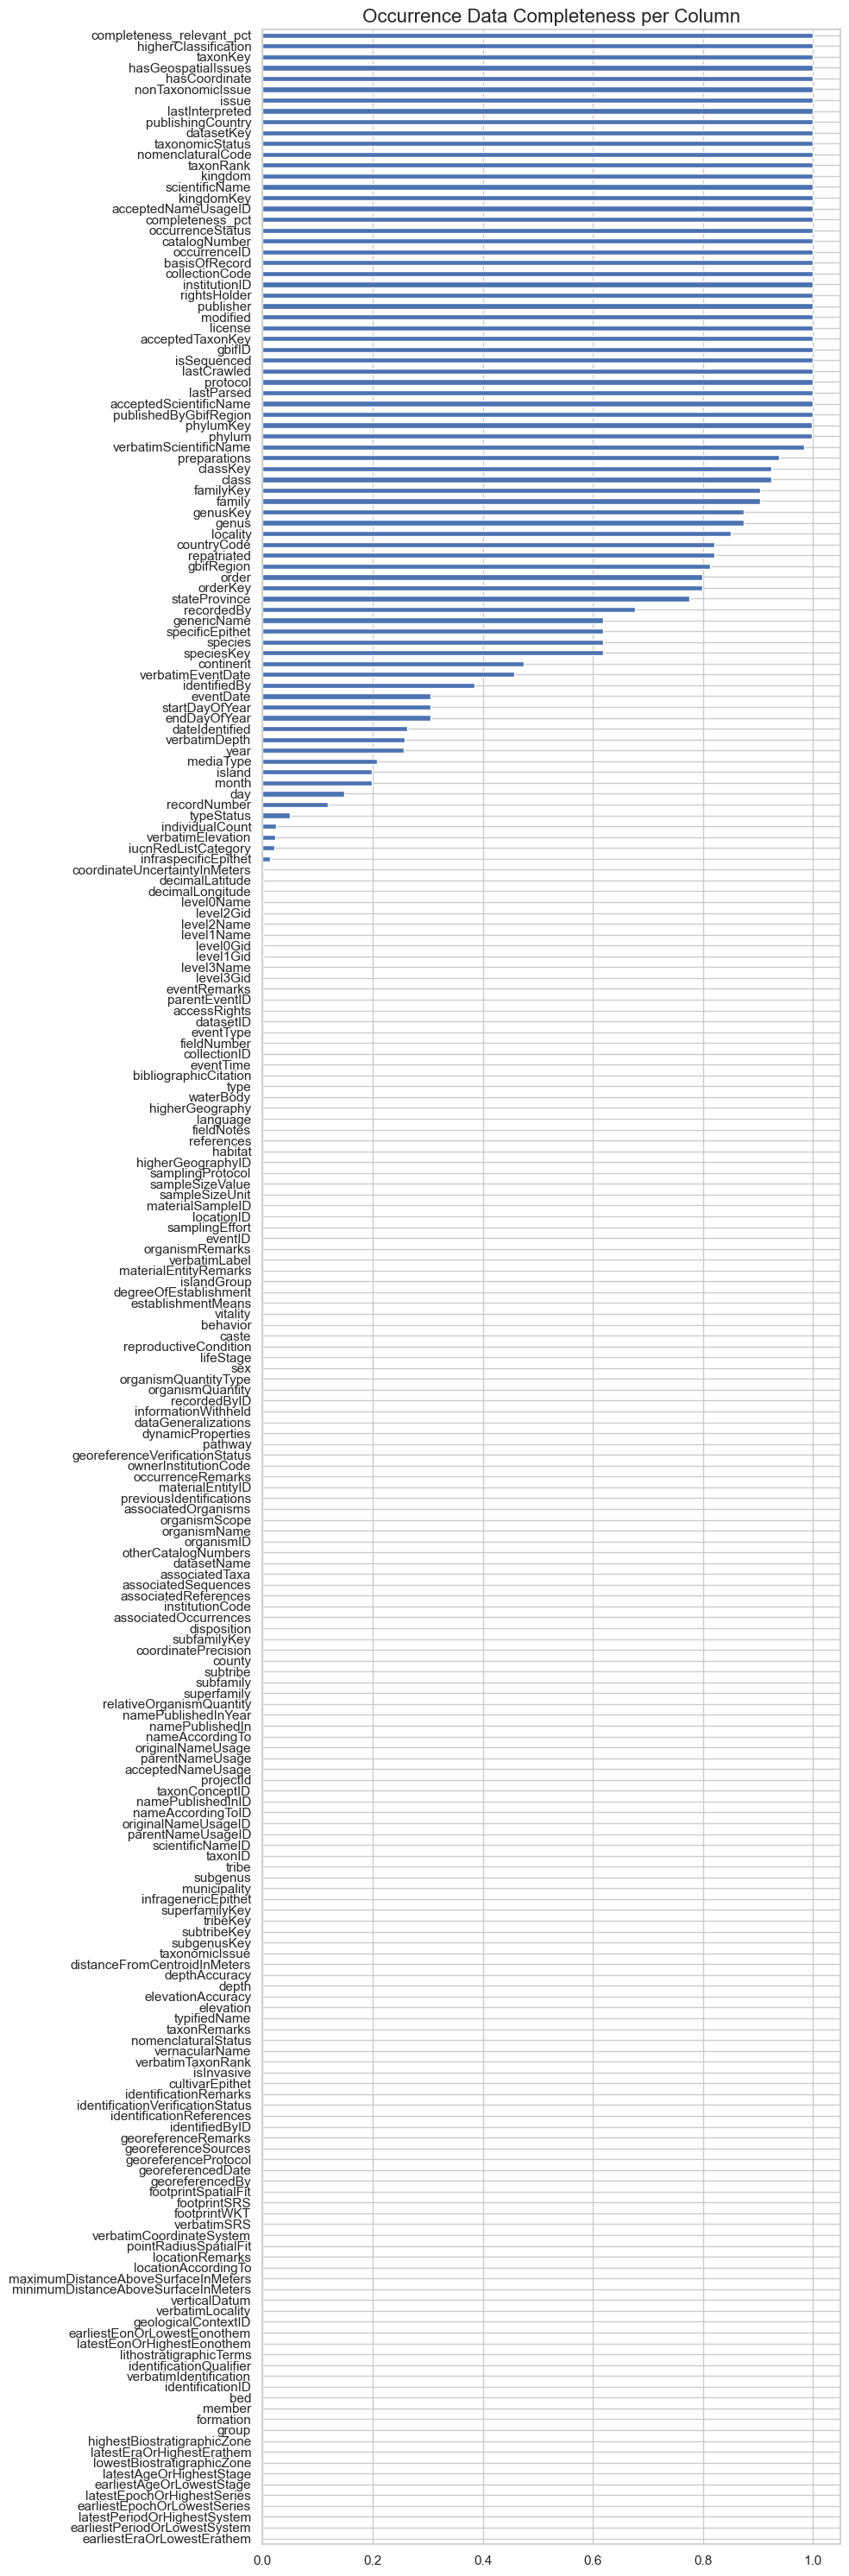

In [727]:
#checking data completeness per data column

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 30))  # increase height a lot
occ.notna().mean().sort_values().plot(kind="barh")

plt.title("Occurrence Data Completeness per Column", fontsize=16)
plt.tight_layout()
plt.show()

Note: It may also be of interest to complete the semi-complete columns as they were important enough, as judged by the data curator, to include in the dataset, however they may not have enough information to complete the metadata entirely. This is the exact situation automatic metadata generation can help with. When a certain column is entirely missing it may either be because it is not relevant or not available for that particular dataset.

Some candidate target metadata fields are included below. This list is not exhaustive, however as some other interesting candidate metadata fields exist. 

In [728]:
# completeness / missingness for just family and order
cols = ["order", "family", "genus", "species"]

summary = (
    occ[cols]
    .isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "n_missing", "mean": "pct_missing"})
)

summary["pct_missing"] = summary["pct_missing"] * 100
print(summary)

         n_missing  pct_missing
order      20972.0    20.084275
family      9999.0     9.575752
genus      13092.0    12.537828
species    39784.0    38.099981


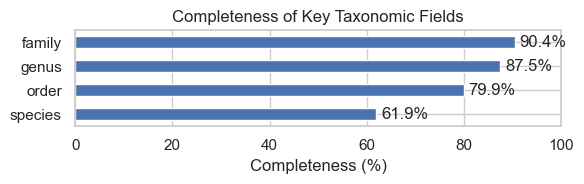

In [729]:
ax = (occ[["order", "family", "genus", "species"]]
      .notna()
      .mean()
      .sort_values() * 100
     ).plot(kind="barh", figsize=(6, 2))

for i, v in enumerate(ax.patches):
    width = v.get_width()
    ax.text(width + 1, i, f"{width:.1f}%", va="center")

plt.title("Completeness of Key Taxonomic Fields")
plt.xlabel("Completeness (%)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

Interestingly, here, order is more missing than family, despite being higher in the taxonomic ranking. This also means, we cannot rely entirely on order to make the correct family prediction. On the other hand, genus is more present than order and is likely to be informative for the family prediction, especially as it is a more fine-grained taxonomic rank.

# Data Cleaning

# De-duplication

In [730]:
#checking for/removing any exact duplicate rows from

print_header("DEDUPLICATION")

#handling occurrences
occ_before_rows, occ_before_cols = occ.shape
occ_duplicate_count = occ.duplicated().sum()

print(f"Occurrence shape before dedup: {occ.shape}")
print(f"Occurrence exact duplicate rows found: {occ_duplicate_count}")

occ = occ.drop_duplicates()

occ_after_rows, occ_after_cols = occ.shape

log_step(
    step="drop_duplicate_occurrence_rows",
    reason="Remove exact duplicate occurrence rows.",
    before_rows=occ_before_rows,
    after_rows=occ_after_rows,
    before_cols=occ_before_cols,
    after_cols=occ_after_cols,
    details={"dropped_rows": int(occ_duplicate_count)}
)

print(f"Occurrence shape after dedup: {occ.shape}")
print(f"Occurrence rows dropped: {occ_before_rows - occ_after_rows}")


#handling multimedia
mm_before_rows, mm_before_cols = mm.shape
mm_duplicate_count = mm.duplicated().sum()

print(f"\nMultimedia shape before dedup: {mm.shape}")
print(f"Multimedia exact duplicate rows found: {mm_duplicate_count}")

mm = mm.drop_duplicates()

mm_after_rows, mm_after_cols = mm.shape

log_step(
    step="drop_duplicate_multimedia_rows",
    reason="Remove exact duplicate multimedia rows.",
    before_rows=mm_before_rows,
    after_rows=mm_after_rows,
    before_cols=mm_before_cols,
    after_cols=mm_after_cols,
    details={"dropped_rows": int(mm_duplicate_count)}
)

print(f"Multimedia shape after dedup: {mm.shape}")
print(f"Multimedia rows dropped: {mm_before_rows - mm_after_rows}")


DEDUPLICATION
Occurrence shape before dedup: (104420, 232)
Occurrence exact duplicate rows found: 0
Occurrence shape after dedup: (104420, 232)
Occurrence rows dropped: 0

Multimedia shape before dedup: (27169, 15)
Multimedia exact duplicate rows found: 0
Multimedia shape after dedup: (27169, 15)
Multimedia rows dropped: 0


In [731]:
print_header("DROPPING EMPTY COLUMNS")

#handling occurrences
occ_before_rows, occ_before_cols = occ.shape

empty_occ_cols = occ.columns[occ.isna().all()].tolist()
occ = occ.drop(columns=empty_occ_cols)

occ_after_rows, occ_after_cols = occ.shape

log_step(
    step="drop_fully_empty_occurrence_columns",
    reason="Dropping fully empty occurrence columns.",
    before_rows=occ_before_rows,
    after_rows=occ_after_rows,
    before_cols=occ_before_cols,
    after_cols=occ_after_cols,
    details={"dropped_columns": empty_occ_cols}
)

print("Dropped occurrence empty columns:", len(empty_occ_cols))
print("Occurrence columns remaining:", occ.shape[1])

show_table(
    "Dropped occurrence empty columns",
    pd.DataFrame({"column": empty_occ_cols}),
    n=200
)


#handling multimedia
mm_before_rows, mm_before_cols = mm.shape

empty_mm_cols = mm.columns[mm.isna().all()].tolist()
mm = mm.drop(columns=empty_mm_cols)

mm_after_rows, mm_after_cols = mm.shape

log_step(
    step="drop_fully_empty_multimedia_columns",
    reason="Dropping fully empty multimedia columns.",
    before_rows=mm_before_rows,
    after_rows=mm_after_rows,
    before_cols=mm_before_cols,
    after_cols=mm_after_cols,
    details={"dropped_columns": empty_mm_cols}
)

print("Dropped multimedia empty columns:", len(empty_mm_cols))
print("Multimedia columns remaining:", mm.shape[1])

show_table(
    "Dropped multimedia empty columns",
    pd.DataFrame({"column": empty_mm_cols}),
    n=50
)

pd.DataFrame({"column": empty_occ_cols}).to_csv(
    logs / "dropped_occ_columns.csv",
    index=False
)

pd.DataFrame({"column": empty_mm_cols}).to_csv(
    logs / "dropped_mm_columns.csv",
    index=False
)


DROPPING EMPTY COLUMNS
Dropped occurrence empty columns: 144
Occurrence columns remaining: 88

--- Dropped occurrence empty columns ---


,column
0,accessRights
1,bibliographicCitation
2,language
3,references
4,type
5,collectionID
6,datasetID
7,institutionCode
8,datasetName
9,ownerInstitutionCode


Dropped multimedia empty columns: 8
Multimedia columns remaining: 7

--- Dropped multimedia empty columns ---


,column
0,references
1,title
2,source
3,audience
4,created
5,creator
6,contributor
7,publisher


In [732]:
#preview of remaining cols 
show_table("Occurrence preview", occ, n=5)
show_table("Multimedia preview", mm, n=5)


--- Occurrence preview ---


,gbifID,license,modified,publisher,rightsHolder,institutionID,collectionCode,basisOfRecord,occurrenceID,catalogNumber,recordNumber,recordedBy,individualCount,occurrenceStatus,preparations,eventDate,startDayOfYear,endDayOfYear,year,month,day,verbatimEventDate,continent,island,countryCode,stateProvince,locality,verbatimElevation,verbatimDepth,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,typeStatus,identifiedBy,dateIdentified,acceptedNameUsageID,scientificName,higherClassification,kingdom,phylum,class,order,family,genus,genericName,specificEpithet,infraspecificEpithet,taxonRank,nomenclaturalCode,taxonomicStatus,datasetKey,publishingCountry,lastInterpreted,issue,nonTaxonomicIssue,mediaType,hasCoordinate,hasGeospatialIssues,taxonKey,acceptedTaxonKey,kingdomKey,phylumKey,classKey,orderKey,familyKey,genusKey,speciesKey,species,acceptedScientificName,verbatimScientificName,protocol,lastParsed,lastCrawled,repatriated,isSequenced,gbifRegion,publishedByGbifRegion,level0Gid,level0Name,level1Gid,level1Name,level2Gid,level2Name,level3Gid,level3Name,iucnRedListCategory,completeness_pct,completeness_relevant_pct
0,2442972033,CC0_1_0,2025-09-18T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.465283,<NA>,A.W. Lacourt,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,EUROPE,<NA>,NL,Zeeland,Domburg,<NA>,<NA>,NaN,NaN,NaN,<NA>,F.P. Wesselingh,2001-01-01T00:00:00,4373124,"Striarca lactea (Linnaeus, 1758)",Animalia,Animalia,Mollusca,Bivalvia,Arcida,Noetiidae,Striarca,Striarca,lactea,<NA>,SPECIES,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.664Z,CONTINENT_DERIVED_FROM_COUNTRY;COLLECTION_MATC...,CONTINENT_DERIVED_FROM_COUNTRY;COLLECTION_MATC...,<NA>,False,False,4373124,4373124,1,52.0,137.0,9574493.0,6884.0,4373123.0,4373124.0,Striarca lactea,"Striarca lactea (Linnaeus, 1758)","Striarca lactea (Linnaeus, 1758)",DWC_ARCHIVE,2026-03-12T16:40:59.664Z,2026-03-12T16:38:46.918Z,False,False,EUROPE,EUROPE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25.652174,100.000000
1,2443030028,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.936850,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Eindhoven,<NA>,2.60-2.90 m.o.m.,NaN,NaN,NaN,<NA>,<NA>,<NA>,8182127,"Pisidium milium Held, 1836",Animalia,Animalia,Mollusca,Bivalvia,Sphaeriida,Sphaeriidae,Euglesa,Pisidium,milium,<NA>,SPECIES,ICZN,SYNONYM,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.650Z,COLLECTION_MATCH_NONE;TAXON_MATCH_FUZZY,COLLECTION_MATCH_NONE,StillImage,False,False,10914468,8182127,1,52.0,137.0,10495862.0,3247675.0,7641355.0,8182127.0,Euglesa milium,"Euglesa milium (Held, 1836)",Pisidium millium Held,DWC_ARCHIVE,2026-03-12T16:40:59.650Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,23.043478,100.000000
2,2443012954,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.818993,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,Celebes,ID,Sulawesi Utara,Kaju Ragi,<NA>,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,2302912,"Trophon Montfort, 1810",Animalia,Animalia,Mollusca,Gastropoda,Neogastropoda,Muricidae,Trophon,<NA>,<NA>,<NA>,GENUS,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.650Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,<NA>,False,False,2302912,2302912,1,52.0,225.0,982.0,2304120.0,2302912.0,NaN,<NA>,"Trophon Montfort, 1810",Trophon,DWC_ARCHIVE,2026-03-12T16:40:59.650Z,2026-03-12T16:38:46.918Z,True,False,ASIA,EUROPE,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,22.608696,85


--- Multimedia preview ---


,gbifID,type,format,identifier,description,license,rightsHolder
0,2443030028,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9368...,RGM.936850,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
1,2443031665,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9379...,RGM.937964,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
2,2443026198,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9318...,RGM.931824,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
3,2443033421,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9385...,RGM.938508_2,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
4,2443033421,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9385...,RGM.938508,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center


In [733]:
def column_presence(df):
    return (
        df.notna().mean() * 100
    ).sort_values(ascending=False).reset_index().rename(
        columns={"index": "column", 0: "presence_percent"}
    )
    
occ_presence = column_presence(occ)
mm_presence = column_presence(mm)

show_table("Occurrence column presence (%)", occ_presence, n=200)
show_table("Multimedia column presence (%)", mm_presence, n=200)


--- Occurrence column presence (%) ---


,column,presence_percent
0,gbifID,100.000000
1,acceptedNameUsageID,100.000000
2,higherClassification,100.000000
3,kingdom,100.000000
4,license,100.000000
5,taxonRank,100.000000
6,nomenclaturalCode,100.000000
7,taxonomicStatus,100.000000
8,datasetKey,100.000000
9,publishingCountry,100.000000



--- Multimedia column presence (%) ---


,column,presence_percent
0,gbifID,100.0
1,type,100.0
2,format,100.0
3,identifier,100.0
4,description,100.0
5,license,100.0
6,rightsHolder,100.0


In [734]:
print_header("DROPPING COLUMNS BELOW 1% DATA THRESHOLD")

low_threshold = 1.0

#occurences
occ_before_cols = occ.shape[1]

drop_occ_cols = occ_presence.loc[
    occ_presence["presence_percent"] < low_threshold, "column"
].tolist()

#checking columns still exist (in case of rerun)
drop_occ_cols = [c for c in drop_occ_cols if c in occ.columns]

#important, protected cols, no changes observed between conditions
protected_occ_cols = [
    "gbifID", "occurrenceID", "catalogNumber", "recordNumber",
    "basisOfRecord", "occurrenceStatus", "preparations",
    "kingdom", "phylum", "class", "order", "family", "genus", "species",
    "scientificName", "acceptedScientificName", "verbatimScientificName",
    "higherClassification",
    "taxonRank", "taxonomicStatus", "nomenclaturalCode",
    "countryCode", "stateProvince", "locality", "continent", "island",
    "eventDate", "year", "month",
    "issue", "nonTaxonomicIssue", "hasCoordinate", "hasGeospatialIssues",
    "taxonKey", "acceptedTaxonKey", "familyKey", "genusKey", "speciesKey",
]

drop_occ_cols = [c for c in drop_occ_cols if c not in protected_occ_cols]

show_table(
    "Occurrence columns to drop (<1%)",
    occ_presence[occ_presence["column"].isin(drop_occ_cols)]
    .sort_values("presence_percent"),
    n=200
)

#dropping cols
occ = occ.drop(columns=drop_occ_cols)

log_step(
    step="drop_low_presence_occurrence_columns",
    reason=f"Dropped occurrence columns with <{low_threshold}% presence.",
    before_rows=occ.shape[0],
    after_rows=occ.shape[0],
    before_cols=occ_before_cols,
    after_cols=occ.shape[1],
    details={"dropped_columns": drop_occ_cols}
)

print(f"Dropped {len(drop_occ_cols)} occurrence columns below {low_threshold}%")
print("Occurrence columns remaining:", occ.shape[1])



DROPPING COLUMNS BELOW 1% DATA THRESHOLD

--- Occurrence columns to drop (<1%) ---


,column,presence_percent
86,level3Gid,0.004788
87,level3Name,0.004788
80,level0Gid,0.018196
81,level0Name,0.018196
82,level1Gid,0.018196
83,level1Name,0.018196
84,level2Gid,0.018196
85,level2Name,0.018196
77,coordinateUncertaintyInMeters,0.023942
78,decimalLongitude,0.023942


Dropped 11 occurrence columns below 1.0%
Occurrence columns remaining: 77


In [735]:
#dropping cols for multimedia
mm_before_cols = mm.shape[1]

drop_mm_cols = mm_presence.loc[
    mm_presence["presence_percent"] < low_threshold, "column"
].tolist()

#checking columns still exist (in case of rerun)
drop_mm_cols = [c for c in drop_mm_cols if c in mm.columns]

#important, protected cols
protected_mm_cols = [
    "gbifID", "type", "format", "identifier",
    "description", "license", "rightsHolder"
]

drop_mm_cols = [c for c in drop_mm_cols if c not in protected_mm_cols]

show_table(
    "Multimedia columns to drop (<1%)",
    mm_presence[mm_presence["column"].isin(drop_mm_cols)]
    .sort_values("presence_percent"),
    n=200
)

#dropping cols
mm = mm.drop(columns=drop_mm_cols)

log_step(
    step="drop_low_presence_multimedia_columns",
    reason=f"Dropped multimedia columns with <{low_threshold}% presence.",
    before_rows=mm.shape[0],
    after_rows=mm.shape[0],
    before_cols=mm_before_cols,
    after_cols=mm.shape[1],
    details={"dropped_columns": drop_mm_cols}
)

print(f"Dropped {len(drop_mm_cols)} multimedia columns below {low_threshold}%")
print("Multimedia columns remaining:", mm.shape[1])


--- Multimedia columns to drop (<1%) ---


,column,presence_percent


Dropped 0 multimedia columns below 1.0%
Multimedia columns remaining: 7


# Familiarising with the data and selecting priority columns for univariate/multivariate EDA

In [736]:
print_header("PRIORITY_COLUMNS")

#just for analysis, columns are not used to drop rest of dataset

taxonomy_cols = [
    "scientificName", "acceptedScientificName", "higherClassification",
    "kingdom", "phylum", "class", "order", "superfamily", "family",
    "subfamily", "tribe", "subtribe", "genus", "genericName", "subgenus",
    "species", "specificEpithet", "infraspecificEpithet",
    "taxonRank", "taxonomicStatus", "nomenclaturalCode",
    "typeStatus", "vernacularName",
    "acceptedNameUsage", "parentNameUsage", "originalNameUsage",
    "acceptedNameUsageID", "acceptedTaxonKey", "taxonKey", "speciesKey",
    "genusKey", "familyKey", "orderKey", "classKey", "phylumKey", "kingdomKey"
]

context_cols = [
    "locality", "countryCode", "stateProvince", "continent", "island",
    "higherGeography", "county", "municipality", "waterBody",
    "formation", "member", "bed", "group", "lithostratigraphicTerms"
]

time_cols = [
    "eventDate", "verbatimEventDate", "year", "month", "day",
    "dateIdentified", "startDayOfYear", "endDayOfYear"
]

numeric_cols = [
    "decimalLatitude", "decimalLongitude", "coordinateUncertaintyInMeters",
    "elevation", "depth", "distanceFromCentroidInMeters"
]

text_rich_cols = [
    "occurrenceRemarks", "fieldNotes", "eventRemarks", "identificationRemarks",
    "verbatimScientificName", "verbatimIdentification", "recordedBy", "identifiedBy",
    "previousIdentifications"
]

quality_cols = [
    "issue", "taxonomicIssue", "nonTaxonomicIssue",
    "hasCoordinate", "hasGeospatialIssues", "isSequenced"
]

join_cols = [
    "gbifID", "occurrenceID", "catalogNumber", "recordNumber",
    "basisOfRecord", "preparations", "mediaType",
    "datasetKey", "publishingCountry", "lastInterpreted",
    "modified", "license", "publisher", "rightsHolder",
    "collectionCode", "institutionID", "occurrenceStatus"
]

priority_cols = list(dict.fromkeys(
    join_cols + taxonomy_cols + context_cols + time_cols +
    numeric_cols + text_rich_cols + quality_cols
))

existing_priority_columns = [c for c in priority_cols if c in occ.columns]

print("Priority semantic columns available:", len(existing_priority_columns))
show_table("Priority semantic columns present", pd.DataFrame({"column": existing_priority_columns}), n=300)



PRIORITY_COLUMNS
Priority semantic columns available: 65

--- Priority semantic columns present ---


,column
0,gbifID
1,occurrenceID
2,catalogNumber
3,recordNumber
4,basisOfRecord
5,preparations
6,mediaType
7,datasetKey
8,publishingCountry
9,lastInterpreted


In [737]:
print_header("COLUMN CATEGORY OVERVIEW FOR CLEANED OCCURRENCE DATA")

column_categories = {
    "taxonomy": taxonomy_cols,
    "context": context_cols,
    "time": time_cols,
    "numeric": numeric_cols,
    "text_rich": text_rich_cols,
    "quality": quality_cols,
    "join_metadata": join_cols,
    "engineered": ["completeness_pct", "completeness_relevant_pct"]
}

category_records = []

for category, cols in column_categories.items():
    for col in cols:
        if col in occ.columns:
            category_records.append({
                "column": col,
                "category": category
            })

assigned_cols = {r["column"] for r in category_records}

for col in occ.columns:
    if col not in assigned_cols:
        category_records.append({
            "column": col,
            "category": "other"
        })

category_df = pd.DataFrame(category_records)

category_summary = (
    category_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n_columns")
)

show_table("Column category summary", category_summary, n=20)
show_table("Column category assignment", category_df.sort_values(["category", "column"]), n=200)

show_table(
    "Other / uncategorised columns",
    category_df[category_df["category"] == "other"].sort_values("column"),
    n=100
)

#saving exploration outputs only
category_df.to_csv(logs / "cleaned_occurrence_column_categories.csv", index=False)
category_summary.to_csv(logs / "cleaned_occurrence_column_category_summary.csv", index=False)

print("This section is exploratory only; occ was not modified.")


COLUMN CATEGORY OVERVIEW FOR CLEANED OCCURRENCE DATA

--- Column category summary ---


,category,n_columns
0,taxonomy,27
1,join_metadata,17
2,other,10
3,time,8
4,context,5
5,quality,5
6,text_rich,3
7,engineered,2



--- Column category assignment ---


,column,category
30,continent,context
28,countryCode,context
31,island,context
27,locality,context
29,stateProvince,context
65,completeness_pct,engineered
66,completeness_relevant_pct,engineered
52,basisOfRecord,join_metadata
50,catalogNumber,join_metadata
62,collectionCode,join_metadata



--- Other / uncategorised columns ---


,column,category
74,gbifRegion,other
67,individualCount,other
76,iucnRedListCategory,other
72,lastCrawled,other
71,lastParsed,other
70,protocol,other
75,publishedByGbifRegion,other
73,repatriated,other
69,verbatimDepth,other
68,verbatimElevation,other


This section is exploratory only; occ was not modified.


# Cleaning for multimedia (retaining fields relevant to multimodal experiment)

Keeping only a small subset of multimedia fields, as this project mainly focuses on the image itself, and these fields serve mainly as a link to the correct image.

In [738]:
print_header("CLEANING MULTIMEDIA")

mm_keep_cols = [c for c in [
    "gbifID", "type", "format", "identifier", "description", "license", "rightsHolder"
] if c in mm.columns]

mm_before_cols = mm.shape[1]
mm = mm[mm_keep_cols].copy()

log_step(
    step="select_multimedia_relevant_columns",
    reason="Keeping relevant multimedia fields for linking to image.",
    before_rows=mm.shape[0],
    after_rows=mm.shape[0],
    before_cols=mm_before_cols,
    after_cols=mm.shape[1],
    details={"kept_columns": mm_keep_cols}
)

before_rows, before_cols = mm.shape

if "type" in mm.columns:
    mm = mm[mm["type"].fillna("").str.lower().eq("stillimage")]

if "format" in mm.columns:
    mm = mm[
        mm["format"].fillna("").str.lower().str.contains(
            "image|jpeg|jpg|png|tiff|gif|webp", regex=True
        )
    ]

if "identifier" in mm.columns:
    mm = mm[mm["identifier"].notna()].copy()

log_step(
    step="filter_multimedia_to_images",
    reason="Keeping  multimedia records with usable images.",
    before_rows=before_rows,
    after_rows=mm.shape[0],
    before_cols=before_cols,
    after_cols=mm.shape[1]
)

print("Filtered multimedia shape:", mm.shape)
show_table("Filtered multimedia preview", mm, n=10)


CLEANING MULTIMEDIA
Filtered multimedia shape: (27169, 7)

--- Filtered multimedia preview ---


,gbifID,type,format,identifier,description,license,rightsHolder
0,2443030028,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9368...,RGM.936850,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
1,2443031665,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9379...,RGM.937964,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
2,2443026198,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9318...,RGM.931824,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
3,2443033421,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9385...,RGM.938508_2,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
4,2443033421,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9385...,RGM.938508,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
5,2443035061,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9425...,RGM.942565,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
6,2443032545,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9400...,RGM.940037,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
7,2443039595,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9450...,RGM.945063,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
8,2443039340,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9446...,RGM.944611,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center
9,2443036486,StillImage,image/jpeg,https://medialib.naturalis.nl/file/id/RGM.9414...,RGM.941451,http://creativecommons.org/publicdomain/zero/1.0/,Naturalis Biodiversity Center


# Grouping multimedia by specimen (using gbifID)

In [739]:
print_header("GROUPING MULTIMEDIA BY IDENTIFIER (gbifID)")
#keeping all image URLs first, then selecting one primary_image (deterministic approach)
#for later modeling steps, keeping one row per occurrence structure

mm = mm.sort_values(["gbifID", "identifier"])

mm_grouped = (
    mm.groupby("gbifID")
    .agg(
        image_urls=("identifier", unique_non_null_list),
        primary_image=("identifier", first_non_null),
        image_count=("identifier", lambda x: pd.Series(x).dropna().nunique()),
        image_formats=("format", unique_non_null_list) if "format" in mm.columns else ("identifier", lambda x: []),
        image_types=("type", unique_non_null_list) if "type" in mm.columns else ("identifier", lambda x: [])
    )
    .reset_index()
)

log_step(
    step="group_multimedia_by_gbifID",
    reason="Grouping specimen images by gbifID and selecting one primary image.",
    details={"kept_primary_image": True, "kept_image_count": True}
)

print("Grouped multimedia shape:", mm_grouped.shape)
show_table("Grouped multimedia preview", mm_grouped, n=10)



GROUPING MULTIMEDIA BY IDENTIFIER (gbifID)
Grouped multimedia shape: (21730, 6)

--- Grouped multimedia preview ---


,gbifID,image_urls,primary_image,image_count,image_formats,image_types
0,2442945337,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1000...,2,[image/jpeg],[StillImage]
1,2442945338,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1000...,2,[image/jpeg],[StillImage]
2,2442945375,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1001...,2,[image/jpeg],[StillImage]
3,2442945381,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1003...,2,[image/jpeg],[StillImage]
4,2442945399,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1005...,2,[image/jpeg],[StillImage]
5,2442945402,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1005...,2,[image/jpeg],[StillImage]
6,2442945406,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1006...,2,[image/jpeg],[StillImage]
7,2442945409,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1006...,3,[image/jpeg],[StillImage]
8,2442945411,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1000...,2,[image/jpeg],[StillImage]
9,2442945418,[https://medialib.naturalis.nl/file/id/RGM.100...,https://medialib.naturalis.nl/file/id/RGM.1006...,1,[image/jpeg],[StillImage]


In [740]:
print_header("MERGING SPECIMEN OCCURRENCE WITH MULTIMEDIA")

before_rows, before_cols = occ.shape

df = occ.merge(mm_grouped, on="gbifID", how="left")

df["has_image"] = df["primary_image"].notna()
df["image_count"] = df["image_count"].fillna(0).astype(int)

assert df.shape[0] == occ.shape[0], "Merge changed row count — check duplicate gbifID keys."

log_step(
    step="merge_occurrence_with_multimedia",
    reason="merging the cleaned occurrence dataset with image metadata (grouped using gbifID).",
    before_rows=before_rows,
    after_rows=df.shape[0],
    before_cols=before_cols,
    after_cols=df.shape[1],
    details={
        "records_with_images": int(df["has_image"].sum()),
        "records_without_images": int((~df["has_image"]).sum())
    }
)

print("Merged dataframe shape:", df.shape)
print("Records with image:", int(df["has_image"].sum()))
print("Records without image:", int((~df["has_image"]).sum()))


MERGING SPECIMEN OCCURRENCE WITH MULTIMEDIA
Merged dataframe shape: (104420, 83)
Records with image: 21730
Records without image: 82690


# Visualising specimen occurrences with/without multimedia 


VISUALISING OCCURRENCES WITH/WITHOUT MULTIMEDIA

--- Occurrence vs multimedia summary ---


,group,count,pct_of_total_occurrences
0,Total occurrence records,104420,100.00000
1,Occurrence records with multimedia,21730,20.81019
2,Occurrence records without multimedia,82690,79.18981


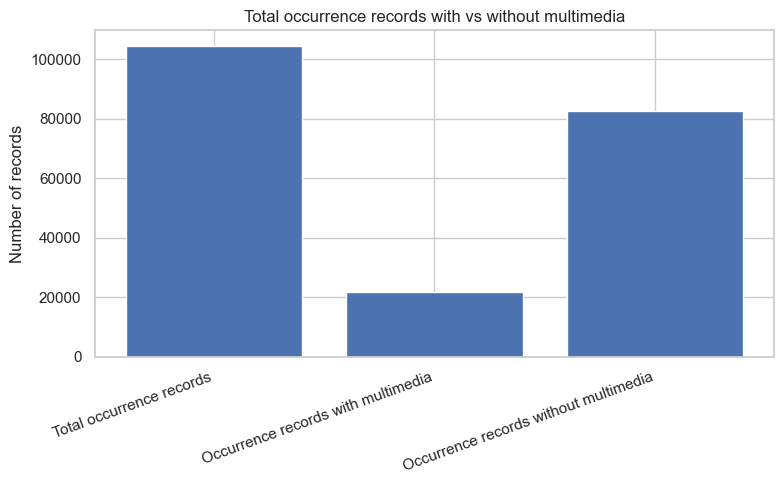

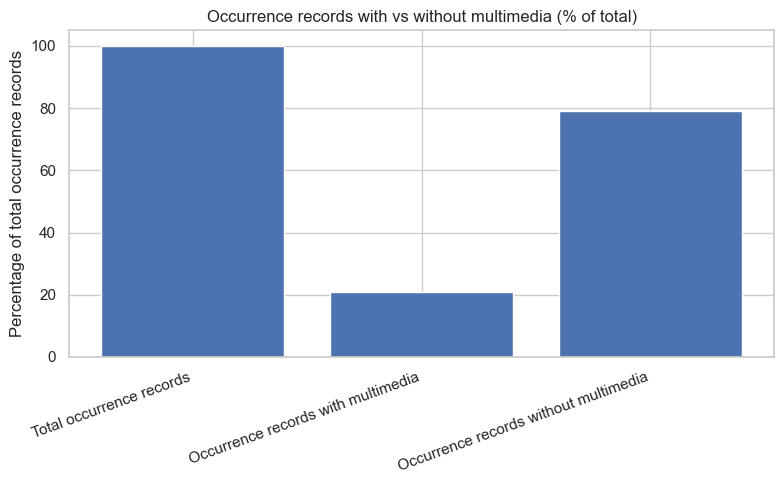

In [741]:
print_header("VISUALISING OCCURRENCES WITH/WITHOUT MULTIMEDIA")

occurrence_multimedia_summary = pd.DataFrame({
    "group": [
        "Total occurrence records",
        "Occurrence records with multimedia",
        "Occurrence records without multimedia"
    ],
    "count": [
        len(df),
        int(df["has_image"].sum()),
        int((~df["has_image"]).sum())
    ]
})

occurrence_multimedia_summary["pct_of_total_occurrences"] = (
    occurrence_multimedia_summary["count"] / len(df) * 100
)

show_table("Occurrence vs multimedia summary", occurrence_multimedia_summary, n=10)

plt.figure(figsize=(8, 5))
plt.bar(
    occurrence_multimedia_summary["group"],
    occurrence_multimedia_summary["count"]
)
plt.title("Total occurrence records with vs without multimedia")
plt.ylabel("Number of records")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    occurrence_multimedia_summary["group"],
    occurrence_multimedia_summary["pct_of_total_occurrences"]
)
plt.title("Occurrence records with vs without multimedia (% of total)")
plt.ylabel("Percentage of total occurrence records")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Filtering for multimedia

An important aspect of this project is the multimodal approach taken and the underlying hypothesis of this study, which suggests that, in cases of missing/incomplete metadata, a model combining information from both image and text modalities will perform better and lead to the correct metadata being generated. For this to be explored, the dataset must contain data records that include both text and images, so that unimodal vs. multimodal models can be compared properly. Due to this, the occurences that do not have an image associated with the rest of the metadata are filtered out. This reduces the dataset size to ~27 000 specimen records, however this is a large enough dataset to proceed with the intended model experiments.

In [742]:
print_header("IMPLEMENTING MULTIMODAL FILTER")

before_rows, before_cols = df.shape

df_mm = df[df["has_image"]].copy()

log_step(
    step="filter_to_multimodal_records",
    reason="Keeping records with at least one image, necessary for multimodal experiments.",
    before_rows=before_rows,
    after_rows=df_mm.shape[0],
    before_cols=before_cols,
    after_cols=df_mm.shape[1]
)

print(
    f"Multimodal subset: {df_mm.shape[0]} "
    f"({df_mm.shape[0] / df.shape[0] * 100:.2f}% of full merged dataset)"
)


IMPLEMENTING MULTIMODAL FILTER
Multimodal subset: 21730 (20.81% of full merged dataset)


In [743]:
#just to check standardising changes
df_mm_before = df_mm.copy()

In [744]:
print_header("STANDARDISING RELEVANT FIELDS (MINIMAL)")

changes = {}

#standaridizing text (categorical) fields
text_standardize_cols = [
    "kingdom", "phylum", "class", "order", "family", "genus", "species",
    "countryCode", "continent", "basisOfRecord",
    "taxonRank", "taxonomicStatus", "nomenclaturalCode"
]

for col in text_standardize_cols:
    if col in df_mm.columns:
        before_na = df_mm[col].isna().sum()
        df_mm[col] = normalize_text_series(df_mm[col])
        after_na = df_mm[col].isna().sum()
        changes[col] = {"na_before": int(before_na), "na_after": int(after_na)}


#standardizing numeric fields
numeric_standardize_cols = [
    "year", "month", "day",
    "startDayOfYear", "endDayOfYear",
    "individualCount"
]

for col in numeric_standardize_cols:
    if col in df_mm.columns:
        before_na = df_mm[col].isna().sum()
        df_mm[col] = pd.to_numeric(df_mm[col], errors="coerce")
        after_na = df_mm[col].isna().sum()
        changes[col] = {"na_before": int(before_na), "na_after": int(after_na)}


log_step(
    step="light_standardization_multimodal_subset",
    reason="Applied minimal normalization to selected metadata fields in the multimodal subset.",
    details=changes
)



STANDARDISING RELEVANT FIELDS (MINIMAL)


In [745]:
changed_counts = {}

for col in df_mm.columns:
    before = df_mm_before[col] if col in df_mm_before.columns else pd.Series(index=df_mm.index, dtype="object")
    after = df_mm[col]

    changed_counts[col] = (
        before.astype("string").fillna("<NA>") != after.astype("string").fillna("<NA>")
    ).sum()

pd.Series(changed_counts).sort_values(ascending=False).head(20)

gbifID                 0
genusKey               0
orderKey               0
classKey               0
phylumKey              0
kingdomKey             0
acceptedTaxonKey       0
taxonKey               0
hasGeospatialIssues    0
hasCoordinate          0
mediaType              0
nonTaxonomicIssue      0
issue                  0
lastInterpreted        0
publishingCountry      0
datasetKey             0
taxonomicStatus        0
nomenclaturalCode      0
taxonRank              0
familyKey              0
dtype: int64

In [746]:
df_mm_before

,gbifID,license,modified,publisher,rightsHolder,institutionID,collectionCode,basisOfRecord,occurrenceID,catalogNumber,recordNumber,recordedBy,individualCount,occurrenceStatus,preparations,eventDate,startDayOfYear,endDayOfYear,year,month,day,verbatimEventDate,continent,island,countryCode,stateProvince,locality,verbatimElevation,verbatimDepth,typeStatus,identifiedBy,dateIdentified,acceptedNameUsageID,scientificName,higherClassification,kingdom,phylum,class,order,family,genus,genericName,specificEpithet,infraspecificEpithet,taxonRank,nomenclaturalCode,taxonomicStatus,datasetKey,publishingCountry,lastInterpreted,issue,nonTaxonomicIssue,mediaType,hasCoordinate,hasGeospatialIssues,taxonKey,acceptedTaxonKey,kingdomKey,phylumKey,classKey,orderKey,familyKey,genusKey,speciesKey,species,acceptedScientificName,verbatimScientificName,protocol,lastParsed,lastCrawled,repatriated,isSequenced,gbifRegion,publishedByGbifRegion,iucnRedListCategory,completeness_pct,completeness_relevant_pct,image_urls,primary_image,image_count,image_formats,image_types,has_image
1,2443030028,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.936850,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Eindhoven,<NA>,2.60-2.90 m.o.m.,<NA>,<NA>,<NA>,8182127,"Pisidium milium Held, 1836",Animalia,Animalia,Mollusca,Bivalvia,Sphaeriida,Sphaeriidae,Euglesa,Pisidium,milium,<NA>,SPECIES,ICZN,SYNONYM,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.650Z,COLLECTION_MATCH_NONE;TAXON_MATCH_FUZZY,COLLECTION_MATCH_NONE,StillImage,False,False,10914468,8182127,1,52.0,137.0,10495862.0,3247675.0,7641355.0,8182127.0,Euglesa milium,"Euglesa milium (Held, 1836)",Pisidium millium Held,DWC_ARCHIVE,2026-03-12T16:40:59.650Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,23.043478,100.000000,[https://medialib.naturalis.nl/file/id/RGM.936...,https://medialib.naturalis.nl/file/id/RGM.9368...,1,[image/jpeg],[StillImage],True
6,2443031665,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.937964,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,109.00-110.00 m.,<NA>,<NA>,<NA>,6493055,"Natica multipunctata Blainville, 1825",Animalia,Animalia,Mollusca,Gastropoda,Littorinimorpha,Naticidae,Natica,Natica,multipunctata,<NA>,SPECIES,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.666Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,6493055,6493055,1,52.0,225.0,7390893.0,7072.0,7693044.0,6493055.0,Natica multipunctata,"Natica multipunctata Blainville, 1825",Natica multipunctata Wood,DWC_ARCHIVE,2026-03-12T16:40:59.666Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,22.608696,100.000000,[https://medialib.naturalis.nl/file/id/RGM.937...,https://medialib.naturalis.nl/file/id/RGM.9379...,1,[image/jpeg],[StillImage],True
10,2443026198,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.931824,81H62,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Noordzee,<NA>,0.15-0.25 m.o.zb.,<NA>,<NA>,<NA>,2305881,"Acanthochitona Gray, 1821",Animalia,Animalia,Mollusca,Polyplacophora,Chitonida,Acanthochitonidae,Acanthochitona,<NA>,<NA>,<NA>,GENUS,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.734Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,2305881,2305881,1,52.0,346.0,8278247.0,9103.0,2305881.0,NaN,<NA>,"Acanthochitona Gray, 1821",Acanthochitona,DWC_ARCHIVE,2026-03-12T16:40:59.734Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>

In [747]:
df_mm

,gbifID,license,modified,publisher,rightsHolder,institutionID,collectionCode,basisOfRecord,occurrenceID,catalogNumber,recordNumber,recordedBy,individualCount,occurrenceStatus,preparations,eventDate,startDayOfYear,endDayOfYear,year,month,day,verbatimEventDate,continent,island,countryCode,stateProvince,locality,verbatimElevation,verbatimDepth,typeStatus,identifiedBy,dateIdentified,acceptedNameUsageID,scientificName,higherClassification,kingdom,phylum,class,order,family,genus,genericName,specificEpithet,infraspecificEpithet,taxonRank,nomenclaturalCode,taxonomicStatus,datasetKey,publishingCountry,lastInterpreted,issue,nonTaxonomicIssue,mediaType,hasCoordinate,hasGeospatialIssues,taxonKey,acceptedTaxonKey,kingdomKey,phylumKey,classKey,orderKey,familyKey,genusKey,speciesKey,species,acceptedScientificName,verbatimScientificName,protocol,lastParsed,lastCrawled,repatriated,isSequenced,gbifRegion,publishedByGbifRegion,iucnRedListCategory,completeness_pct,completeness_relevant_pct,image_urls,primary_image,image_count,image_formats,image_types,has_image
1,2443030028,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.936850,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Eindhoven,<NA>,2.60-2.90 m.o.m.,<NA>,<NA>,<NA>,8182127,"Pisidium milium Held, 1836",Animalia,Animalia,Mollusca,Bivalvia,Sphaeriida,Sphaeriidae,Euglesa,Pisidium,milium,<NA>,SPECIES,ICZN,SYNONYM,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.650Z,COLLECTION_MATCH_NONE;TAXON_MATCH_FUZZY,COLLECTION_MATCH_NONE,StillImage,False,False,10914468,8182127,1,52.0,137.0,10495862.0,3247675.0,7641355.0,8182127.0,Euglesa milium,"Euglesa milium (Held, 1836)",Pisidium millium Held,DWC_ARCHIVE,2026-03-12T16:40:59.650Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,23.043478,100.000000,[https://medialib.naturalis.nl/file/id/RGM.936...,https://medialib.naturalis.nl/file/id/RGM.9368...,1,[image/jpeg],[StillImage],True
6,2443031665,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.937964,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,109.00-110.00 m.,<NA>,<NA>,<NA>,6493055,"Natica multipunctata Blainville, 1825",Animalia,Animalia,Mollusca,Gastropoda,Littorinimorpha,Naticidae,Natica,Natica,multipunctata,<NA>,SPECIES,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.666Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,6493055,6493055,1,52.0,225.0,7390893.0,7072.0,7693044.0,6493055.0,Natica multipunctata,"Natica multipunctata Blainville, 1825",Natica multipunctata Wood,DWC_ARCHIVE,2026-03-12T16:40:59.666Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,22.608696,100.000000,[https://medialib.naturalis.nl/file/id/RGM.937...,https://medialib.naturalis.nl/file/id/RGM.9379...,1,[image/jpeg],[StillImage],True
10,2443026198,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.931824,81H62,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Noordzee,<NA>,0.15-0.25 m.o.zb.,<NA>,<NA>,<NA>,2305881,"Acanthochitona Gray, 1821",Animalia,Animalia,Mollusca,Polyplacophora,Chitonida,Acanthochitonidae,Acanthochitona,<NA>,<NA>,<NA>,GENUS,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.734Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,2305881,2305881,1,52.0,346.0,8278247.0,9103.0,2305881.0,NaN,<NA>,"Acanthochitona Gray, 1821",Acanthochitona,DWC_ARCHIVE,2026-03-12T16:40:59.734Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>

In [748]:
pd.DataFrame({"column": df_mm.columns})

,column
0,gbifID
1,license
2,modified
3,publisher
4,rightsHolder
5,institutionID
6,collectionCode
7,basisOfRecord
8,occurrenceID
9,catalogNumber


# Identifying candidate metadata fields(target variable)

In [749]:
print_header("CANDIDATE TARGET ANALYSIS")

candidate_targets = [
    "kingdom", "phylum", "class", "order", "family", "genus", "species",
    "countryCode", "continent", "stateProvince", "higherGeography",
    "year", "month", "basisOfRecord",
    "speciesKey", "locality", "eventDate", "verbatimEventDate"
]

candidate_targets = [c for c in candidate_targets if c in df_mm.columns]

target_missing = pd.DataFrame({
    "non_missing_count": df_mm[candidate_targets].notna().sum(),
    "missing_count": df_mm[candidate_targets].isna().sum(),
    "missing_pct": df_mm[candidate_targets].isna().mean() * 100,
    "n_unique": df_mm[candidate_targets].nunique(dropna=True),
}).sort_values(["missing_pct", "n_unique"])

show_table("Candidate target summary", target_missing, n=50)

#checking due to the similarity between family and other taxonomic ranks
print_header("TAXONOMIC CONSISTENCY CHECK")

#order to family
order_family = df_mm.groupby("order")["family"].nunique()
print("order → family deterministic (%):",
      (order_family == 1).mean() * 100)

#genus to family
genus_family = df_mm.groupby("genus")["family"].nunique()
print("genus → family deterministic (%):",
      (genus_family == 1).mean() * 100)

#species to family
species_family = df_mm.groupby("species")["family"].nunique()
print("species → family deterministic (%):",
      (species_family == 1).mean() * 100)


CANDIDATE TARGET ANALYSIS

--- Candidate target summary ---


,non_missing_count,missing_count,missing_pct,n_unique
basisOfRecord,21730,0,0.000000,2
kingdom,21730,0,0.000000,3
phylum,21661,69,0.317533,10
class,20901,829,3.815002,24
family,20659,1071,4.928670,365
genus,20550,1180,5.430281,1168
order,17121,4609,21.210308,77
locality,16875,4855,22.342384,887
species,15251,6479,29.815923,2241
speciesKey,15251,6479,29.815923,2243



TAXONOMIC CONSISTENCY CHECK
order → family deterministic (%): 42.857142857142854
genus → family deterministic (%): 97.94520547945206
species → family deterministic (%): 99.8215082552432


~98% of genera map to one family

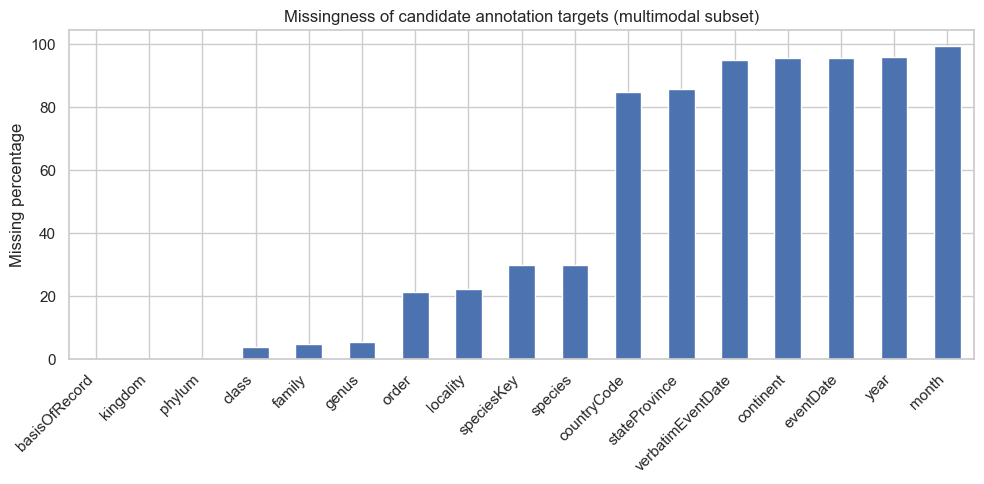

In [750]:
plt.figure(figsize=(10, 5))

target_missing["missing_pct"].sort_values().plot(kind="bar")

plt.ylabel("Missing percentage")
plt.title("Missingness of candidate annotation targets (multimodal subset)")
plt.xticks(rotation=45, ha="right")  #improving readability

plt.tight_layout()
plt.show()

Adding 10% missingness line for candidates, can also simulate missingness, while having enough data to verify ground truth.

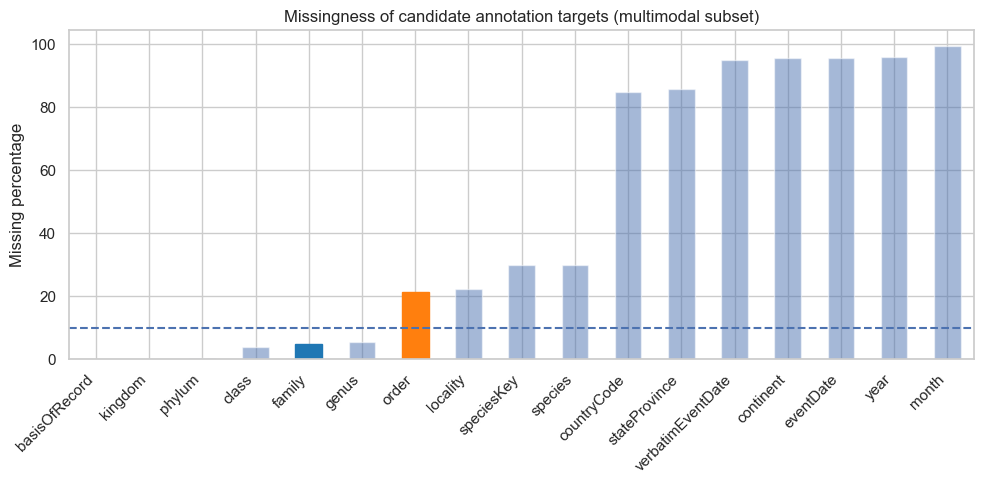

In [751]:
plt.figure(figsize=(10, 5))

sorted_missing = target_missing["missing_pct"].sort_values()

ax = sorted_missing.plot(kind="bar")

for i, label in enumerate(sorted_missing.index):
    if label == "family":
        ax.patches[i].set_color("tab:blue")
        ax.patches[i].set_alpha(1.0)
    elif label == "order":
        ax.patches[i].set_color("tab:orange")
        ax.patches[i].set_alpha(1.0)
    else:
        ax.patches[i].set_alpha(0.5)

plt.axhline(y=10, linestyle="--")  #10% threshold

plt.ylabel("Missing percentage")
plt.title("Missingness of candidate annotation targets (multimodal subset)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

There are two research directions of interest currently identified line with completing the scientific names/taxonomic rank metadata fields, there are speciesKey and genusKey columns that are incomplete. Generating appropriate metadata for such fields would be highly in line with the FAIR data principles and trying to make data more reproducible and reusable. Also, there seems Other metadata fields of interest include event/date fields and this is more in line with the specific particularities of the chosen Mollusca dataset. It turns out that Cenozoic mollusks are highly important in various scientific fields, and serve as tools for reconstructing ancient ecosystems, identifying specific geological time intervals and other paleontological and evolutionary studies tasks. Therefore, completing these types of metadata fields could have significant impacts on research, and help achieve the goal of maximizing the research potential of natural science collections. One limitation here, is that there are several metadata fields and enough data to improve locality/geographic information, however for the event/date fields there is limited data available, limiting the training size for models.

It is also important to note that good targets typically have low/moderate missingness yet also enough examples and relevance to the research question.

For now, family and genus have been selected as potential candidates. An interesting approach would be to see how far unimodal vs. multimodal models may get in terms of predicting the specific species and what granularity they can reach in correct predictions. For example, perhaps a unimodal model can correctly identify the family, whereas a multimodal model can correctly complete metadata all the way up to the specific species.

# DATA LEAKAGE ANALYSIS

In [752]:
print_header("EXACT STRING MATCH CHECK: FAMILY vs OTHER FIELDS")

results_family = {}

target = "family"

cols_to_check = ["order", "genus", "species", "scientificName", "acceptedScientificName", "higherClassification"]

for col in cols_to_check:
    if col in df_mm.columns:
        valid = df_mm[[target, col]].dropna()

        if len(valid) == 0:
            match_pct = np.nan
        else:
            match_pct = (
                valid[target].astype("string") == valid[col].astype("string")
            ).mean() * 100

        results_family[col] = match_pct

results_family_df = (
    pd.DataFrame.from_dict(results_family, orient="index", columns=["match_percentage"])
    .sort_values("match_percentage", ascending=False)
)

show_table("Family exact string match checks (%)", results_family_df, n=10)


EXACT STRING MATCH CHECK: FAMILY vs OTHER FIELDS

--- Family exact string match checks (%) ---


,match_percentage
acceptedScientificName,1.176243
scientificName,1.001985
order,0.000000
genus,0.000000
species,0.000000
higherClassification,0.000000


In [753]:
print_header("EXACT STRING MATCH CHECK: ORDER vs OTHER FIELDS")

results_order = {}

target = "order"

cols_to_check = ["family", "genus", "species", "scientificName", "acceptedScientificName", "higherClassification"]

for col in cols_to_check:
    if col in df_mm.columns:
        valid = df_mm[[target, col]].dropna()

        if len(valid) == 0:
            match_pct = np.nan
        else:
            match_pct = (
                valid[target].astype("string") == valid[col].astype("string")
            ).mean() * 100

        results_order[col] = match_pct

results_order_df = (
    pd.DataFrame.from_dict(results_order, orient="index", columns=["match_percentage"])
    .sort_values("match_percentage", ascending=False)
)

show_table("Order exact string match checks (%)", results_order_df, n=10)


EXACT STRING MATCH CHECK: ORDER vs OTHER FIELDS

--- Order exact string match checks (%) ---


,match_percentage
scientificName,0.327084
acceptedScientificName,0.327084
family,0.000000
genus,0.000000
species,0.000000
higherClassification,0.000000


In [754]:
#for clean subset, taxonomy as expected
print_header("DEPENDENCY CHECK FOR ORDER (LEAKAGE RISK)")

cols_to_test = ["family", "genus", "species", "scientificName", "acceptedScientificName", "higherClassification", "scientificName", "acceptedScientificName", "higherClassification",
    "kingdom", "phylum", "class", "superfamily", "family",
    "subfamily", "tribe", "subtribe", "genus", "genericName", "subgenus",
    "species", "specificEpithet", "infraspecificEpithet",
    "taxonRank", "taxonomicStatus", "nomenclaturalCode",
    "typeStatus", "vernacularName",
    "acceptedNameUsage", "parentNameUsage", "originalNameUsage",
    "acceptedNameUsageID", "acceptedTaxonKey", "taxonKey", "speciesKey",
    "genusKey", "familyKey", "orderKey", "classKey", "phylumKey", "kingdomKey"]

results = {}

for col in cols_to_test:
    if col in df_mm.columns:
        valid = df_mm[[col, "order"]].dropna()
        mapping = valid.groupby(col)["order"].nunique()
        deterministic_pct = (mapping == 1).mean() * 100
        results[col] = deterministic_pct

results_df = (
    pd.DataFrame.from_dict(results, orient="index", columns=["deterministic_pct"])
    .sort_values("deterministic_pct", ascending=False)
)

show_table("How well each column determines ORDER (%)", results_df)


DEPENDENCY CHECK FOR ORDER (LEAKAGE RISK)

--- How well each column determines ORDER (%) ---


,deterministic_pct
family,100.000000
orderKey,100.000000
genusKey,100.000000
speciesKey,100.000000
taxonKey,100.000000
acceptedTaxonKey,100.000000
acceptedNameUsageID,100.000000
genus,100.000000
infraspecificEpithet,100.000000
acceptedScientificName,100.000000


In [755]:
#summary for order
print_header("ORDER DEPENDENCY CHECK")

family_order = df_mm.dropna(subset=["family", "order"]).groupby("family")["order"].nunique()
genus_order = df_mm.dropna(subset=["genus", "order"]).groupby("genus")["order"].nunique()
species_order = df_mm.dropna(subset=["species", "order"]).groupby("species")["order"].nunique()

print("family → order deterministic (%):",
      (family_order == 1).mean() * 100)

print("genus → order deterministic (%):",
      (genus_order == 1).mean() * 100)

print("species → order deterministic (%):",
      (species_order == 1).mean() * 100)


ORDER DEPENDENCY CHECK
family → order deterministic (%): 100.0
genus → order deterministic (%): 100.0
species → order deterministic (%): 100.0


In [756]:
#summary table with examples
print_header("TAXONOMIC FIELD TO FAMILY MAPPING STRENGTH")

mapping_results = []

for col in ["order", "genus", "species", "scientificName", "acceptedScientificName", "higherClassification"]:
    if col in df_mm.columns:
        valid = df_mm[[col, "family"]].dropna()
        families_per_value = valid.groupby(col)["family"].nunique()

        mapping_results.append({
            "field": col,
            "n_unique_values": families_per_value.shape[0],
            "mean_families_per_value": families_per_value.mean(),
            "max_families_per_value": families_per_value.max(),
            "deterministic_pct": (families_per_value == 1).mean() * 100
        })

family_mapping_strength = (
    pd.DataFrame(mapping_results)
    .sort_values("deterministic_pct", ascending=False)
)

show_table("Taxonomic field → family mapping strength", family_mapping_strength, n=20)


TAXONOMIC FIELD TO FAMILY MAPPING STRENGTH

--- Taxonomic field → family mapping strength ---


,field,n_unique_values,mean_families_per_value,max_families_per_value,deterministic_pct
2,species,2237,1.000000,1,100.000000
3,scientificName,3241,1.000000,1,100.000000
4,acceptedScientificName,2873,1.000000,1,100.000000
1,genus,1145,1.000873,2,99.912664
5,higherClassification,77,5.766234,357,92.207792
0,order,77,3.987013,47,42.857143


In [757]:
#summary table with examples
print_header("TAXONOMIC FIELD TO ORDER MAPPING STRENGTH")

mapping_results = []

for col in ["family", "genus", "species", "scientificName", "acceptedScientificName", "higherClassification"]:
    if col in df_mm.columns:
        valid = df_mm[[col, "order"]].dropna()
        orders_per_value = valid.groupby(col)["order"].nunique()

        mapping_results.append({
            "field": col,
            "n_unique_values": orders_per_value.shape[0],
            "mean_orders_per_value": orders_per_value.mean(),
            "max_orders_per_value": orders_per_value.max(),
            "deterministic_pct": (orders_per_value == 1).mean() * 100
        })

order_mapping_strength = (
    pd.DataFrame(mapping_results)
    .sort_values("deterministic_pct", ascending=False)
)

show_table("Taxonomic field → order mapping strength", order_mapping_strength, n=20)


TAXONOMIC FIELD TO ORDER MAPPING STRENGTH

--- Taxonomic field → order mapping strength ---


,field,n_unique_values,mean_orders_per_value,max_orders_per_value,deterministic_pct
0,family,307,1.000000,1,100.000000
1,genus,968,1.000000,1,100.000000
2,species,1890,1.000000,1,100.000000
3,scientificName,2741,1.000000,1,100.000000
4,acceptedScientificName,2437,1.000000,1,100.000000
5,higherClassification,65,2.215385,75,92.307692


In [758]:
#full table
print_header("CHECKING THE STRENGTH OF LEAKY FIELD MAPPING TO FAMILY")

leaky_cols_candidates = [
    "scientificName",
    "acceptedScientificName",
    "verbatimScientificName",
    "higherClassification",
    "genus",
    "genericName",
    "species",
    "specificEpithet",
    "acceptedNameUsageID",
    "taxonKey",
    "acceptedTaxonKey",
    "genusKey",
    "speciesKey",
    "familyKey",  
    "orderKey",
    "order",
]

results = []

for col in leaky_cols_candidates:
    if col not in df_mm.columns:
        continue

    valid = df_mm.loc[:, [col, "family"]].dropna()

    if valid.empty:
        continue

    group_sizes = valid.groupby(col).size()
    families_per_value = valid.groupby(col)["family"].nunique()

    results.append({
        "field": col,
        "n_non_missing_rows": len(valid),
        "n_unique_values": valid[col].nunique(),
        "avg_group_size": group_sizes.mean(),
        "mean_families_per_value": families_per_value.mean(),
        "median_families_per_value": families_per_value.median(),
        "max_families_per_value": families_per_value.max(),
        "pct_values_mapping_to_one_family": (families_per_value == 1).mean() * 100,
    })

leakage_mapping_summary_family = (
    pd.DataFrame(results)
    .sort_values("pct_values_mapping_to_one_family", ascending=False)
    .reset_index(drop=True)
)

display(leakage_mapping_summary_family)

leakage_mapping_summary_family.to_csv(
    logs / "leakage_mapping_summary_family.csv",
    index=False
)


CHECKING THE STRENGTH OF LEAKY FIELD MAPPING TO FAMILY


,field,n_non_missing_rows,n_unique_values,avg_group_size,mean_families_per_value,median_families_per_value,max_families_per_value,pct_values_mapping_to_one_family
0,scientificName,20659,3241,6.374267,1.000000,1.0,1,100.000000
1,acceptedScientificName,20659,2873,7.190741,1.000000,1.0,1,100.000000
2,verbatimScientificName,20659,6708,3.079756,1.000000,1.0,1,100.000000
3,species,15237,2237,6.811354,1.000000,1.0,1,100.000000
4,acceptedNameUsageID,20659,2873,7.190741,1.000000,1.0,1,100.000000
5,taxonKey,20659,3241,6.374267,1.000000,1.0,1,100.000000
6,acceptedTaxonKey,20659,2873,7.190741,1.000000,1.0,1,100.000000
7,genusKey,20416,1148,17.783972,1.000000,1.0,1,100.000000
8,speciesKey,15237,2239,6.805270,1.000000,1.0,1,100.000000
9,familyKey,20659,365,56.600000,1.000000,1.0,1,100.000000


In [759]:
print_header("CHECKING THE STRENGTH OF LEAKY FIELD MAPPING TO ORDER")

leaky_cols_candidates = [
    "scientificName",
    "acceptedScientificName",
    "verbatimScientificName",
    "higherClassification",
    "family",
    "genus",
    "genericName",
    "species",
    "specificEpithet",
    "acceptedNameUsageID",
    "taxonKey",
    "acceptedTaxonKey",
    "familyKey",
    "genusKey",
    "speciesKey",
    "orderKey",
]

results = []

for col in leaky_cols_candidates:
    if col not in df_mm.columns:
        continue

    valid = df_mm.loc[:, [col, "order"]].dropna()

    if valid.empty:
        continue

    group_sizes = valid.groupby(col).size()
    orders_per_value = valid.groupby(col)["order"].nunique()

    results.append({
        "field": col,
        "n_non_missing_rows": len(valid),
        "n_unique_values": valid[col].nunique(),
        "avg_group_size": group_sizes.mean(),
        "mean_orders_per_value": orders_per_value.mean(),
        "median_orders_per_value": orders_per_value.median(),
        "max_orders_per_value": orders_per_value.max(),
        "pct_values_mapping_to_one_order": (orders_per_value == 1).mean() * 100,
    })

leakage_mapping_summary_order = (
    pd.DataFrame(results)
    .sort_values("pct_values_mapping_to_one_order", ascending=False)
)

display(leakage_mapping_summary_order)

leakage_mapping_summary_order.to_csv(
    logs / "leakage_mapping_summary_order.csv",
    index=False
)


CHECKING THE STRENGTH OF LEAKY FIELD MAPPING TO ORDER


,field,n_non_missing_rows,n_unique_values,avg_group_size,mean_orders_per_value,median_orders_per_value,max_orders_per_value,pct_values_mapping_to_one_order
0,scientificName,17121,2741,6.246260,1.000000,1.0,1,100.000000
1,acceptedScientificName,17121,2437,7.025441,1.000000,1.0,1,100.000000
2,verbatimScientificName,17121,5571,3.073236,1.000000,1.0,1,100.000000
4,family,17050,307,55.537459,1.000000,1.0,1,100.000000
5,genus,16837,968,17.393595,1.000000,1.0,1,100.000000
7,species,12519,1890,6.623810,1.000000,1.0,1,100.000000
9,acceptedNameUsageID,17121,2437,7.025441,1.000000,1.0,1,100.000000
10,taxonKey,17121,2741,6.246260,1.000000,1.0,1,100.000000
11,acceptedTaxonKey,17121,2437,7.025441,1.000000,1.0,1,100.000000
12,familyKey,17050,307,55.537459,1.000000,1.0,1,100.000000


In [760]:
print_header("FULL DATA LEAKAGE ANALYSIS")

target_col = "order"
min_rows = 100
max_unique = 10000

def make_hashable(x):
    if isinstance(x, list):
        return tuple(x)
    if isinstance(x, dict):
        return tuple(sorted(x.items()))
    return x

def entropy(s):
    p = s.value_counts(normalize=True)
    return -(p * np.log2(p)).sum()

results = []
skipped = []

for col in df_mm.columns:
    if col == target_col:
        continue

    valid = df_mm[[col, target_col]].dropna().copy()

    if len(valid) < min_rows:
        skipped.append({"field": col, "reason": f"<{min_rows}_non_missing_rows"})
        continue

    valid[col] = valid[col].map(make_hashable)

    try:
        n_unique = valid[col].nunique(dropna=True)

        if n_unique > max_unique:
            skipped.append({"field": col, "reason": f">{max_unique}_unique_values"})
            continue

        group_sizes = valid.groupby(col).size()
        orders_per_value = valid.groupby(col)[target_col].nunique()
        entropy_per_value = valid.groupby(col)[target_col].apply(entropy)

        one_order_values = orders_per_value == 1

        results.append({
            "field": col,
            "n_rows": len(valid),
            "n_unique_values": n_unique,
            "avg_rows_per_value": group_sizes.mean(),
            "mean_orders_per_value": orders_per_value.mean(),
            "median_orders_per_value": orders_per_value.median(),
            "max_orders_per_value": orders_per_value.max(),
            "pct_values_mapping_to_one_order": one_order_values.mean() * 100,
            "pct_rows_mapping_to_one_order": group_sizes[one_order_values].sum() / len(valid) * 100,
            "mean_order_entropy": entropy_per_value.mean(),
            "mutual_information": mutual_info_score(
                valid[col].astype("string"),
                valid[target_col].astype("string")
            )
        })

    except Exception as e:
        skipped.append({"field": col, "reason": type(e).__name__})

leakage_scan_order = (
    pd.DataFrame(results)
    .sort_values(
        ["pct_rows_mapping_to_one_order", "mutual_information"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

skipped_cols_order = pd.DataFrame(skipped)

show_table("Full leakage scan for order", leakage_scan_order, n=100)
show_table("Skipped columns for order scan", skipped_cols_order, n=100)

leakage_scan_order.to_csv(logs / "full_leakage_scan_order.csv", index=False)
skipped_cols_order.to_csv(logs / "full_leakage_scan_order_skipped_columns.csv", index=False)

print("Total columns:", len(df_mm.columns))
print("Analyzed columns:", len(leakage_scan_order))
print("Skipped columns:", len(skipped_cols_order))


FULL DATA LEAKAGE ANALYSIS

--- Full leakage scan for order ---


,field,n_rows,n_unique_values,avg_rows_per_value,mean_orders_per_value,median_orders_per_value,max_orders_per_value,pct_values_mapping_to_one_order,pct_rows_mapping_to_one_order,mean_order_entropy,mutual_information
0,genus,16837,968,17.393595,1.000000,1.0,1,100.000000,100.000000,0.000000,2.962942
1,genusKey,16837,969,17.375645,1.000000,1.0,1,100.000000,100.000000,0.000000,2.962942
2,family,17050,307,55.537459,1.000000,1.0,1,100.000000,100.000000,0.000000,2.960804
3,familyKey,17050,307,55.537459,1.000000,1.0,1,100.000000,100.000000,0.000000,2.960804
4,acceptedNameUsageID,17121,2437,7.025441,1.000000,1.0,1,100.000000,100.000000,0.000000,2.959432
5,scientificName,17121,2741,6.246260,1.000000,1.0,1,100.000000,100.000000,0.000000,2.959432
6,acceptedTaxonKey,17121,2437,7.025441,1.000000,1.0,1,100.000000,100.000000,0.000000,2.959432
7,orderKey,17121,77,222.350649,1.000000,1.0,1,100.000000,100.000000,0.000000,2.959432
8,acceptedScientificName,17121,2437,7.025441,1.000000,1.0,1,100.000000,100.000000,0.000000,2.959432
9,verbatimScientificName,17121,5571,3.073236,1.000000,1.0,1,100.000000,100.000000,0.000000,2.959432



--- Skipped columns for order scan ---


,field,reason
0,gbifID,>10000_unique_values
1,occurrenceID,>10000_unique_values
2,catalogNumber,>10000_unique_values
3,individualCount,<100_non_missing_rows
4,day,<100_non_missing_rows
5,image_urls,>10000_unique_values
6,primary_image,>10000_unique_values


Total columns: 83
Analyzed columns: 75
Skipped columns: 7


# CANDIDATE TEXT INPUTS

Trying to identify potential candidate fields for unimodal and multimodal textual inputs, in particular considering that family/genus would be the target field for predictions.

In [761]:
df_mm

,gbifID,license,modified,publisher,rightsHolder,institutionID,collectionCode,basisOfRecord,occurrenceID,catalogNumber,recordNumber,recordedBy,individualCount,occurrenceStatus,preparations,eventDate,startDayOfYear,endDayOfYear,year,month,day,verbatimEventDate,continent,island,countryCode,stateProvince,locality,verbatimElevation,verbatimDepth,typeStatus,identifiedBy,dateIdentified,acceptedNameUsageID,scientificName,higherClassification,kingdom,phylum,class,order,family,genus,genericName,specificEpithet,infraspecificEpithet,taxonRank,nomenclaturalCode,taxonomicStatus,datasetKey,publishingCountry,lastInterpreted,issue,nonTaxonomicIssue,mediaType,hasCoordinate,hasGeospatialIssues,taxonKey,acceptedTaxonKey,kingdomKey,phylumKey,classKey,orderKey,familyKey,genusKey,speciesKey,species,acceptedScientificName,verbatimScientificName,protocol,lastParsed,lastCrawled,repatriated,isSequenced,gbifRegion,publishedByGbifRegion,iucnRedListCategory,completeness_pct,completeness_relevant_pct,image_urls,primary_image,image_count,image_formats,image_types,has_image
1,2443030028,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.936850,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Eindhoven,<NA>,2.60-2.90 m.o.m.,<NA>,<NA>,<NA>,8182127,"Pisidium milium Held, 1836",Animalia,Animalia,Mollusca,Bivalvia,Sphaeriida,Sphaeriidae,Euglesa,Pisidium,milium,<NA>,SPECIES,ICZN,SYNONYM,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.650Z,COLLECTION_MATCH_NONE;TAXON_MATCH_FUZZY,COLLECTION_MATCH_NONE,StillImage,False,False,10914468,8182127,1,52.0,137.0,10495862.0,3247675.0,7641355.0,8182127.0,Euglesa milium,"Euglesa milium (Held, 1836)",Pisidium millium Held,DWC_ARCHIVE,2026-03-12T16:40:59.650Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,23.043478,100.000000,[https://medialib.naturalis.nl/file/id/RGM.936...,https://medialib.naturalis.nl/file/id/RGM.9368...,1,[image/jpeg],[StillImage],True
6,2443031665,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.937964,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,109.00-110.00 m.,<NA>,<NA>,<NA>,6493055,"Natica multipunctata Blainville, 1825",Animalia,Animalia,Mollusca,Gastropoda,Littorinimorpha,Naticidae,Natica,Natica,multipunctata,<NA>,SPECIES,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.666Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,6493055,6493055,1,52.0,225.0,7390893.0,7072.0,7693044.0,6493055.0,Natica multipunctata,"Natica multipunctata Blainville, 1825",Natica multipunctata Wood,DWC_ARCHIVE,2026-03-12T16:40:59.666Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,22.608696,100.000000,[https://medialib.naturalis.nl/file/id/RGM.937...,https://medialib.naturalis.nl/file/id/RGM.9379...,1,[image/jpeg],[StillImage],True
10,2443026198,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.931824,81H62,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Noordzee,<NA>,0.15-0.25 m.o.zb.,<NA>,<NA>,<NA>,2305881,"Acanthochitona Gray, 1821",Animalia,Animalia,Mollusca,Polyplacophora,Chitonida,Acanthochitonidae,Acanthochitona,<NA>,<NA>,<NA>,GENUS,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.734Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,2305881,2305881,1,52.0,346.0,8278247.0,9103.0,2305881.0,NaN,<NA>,"Acanthochitona Gray, 1821",Acanthochitona,DWC_ARCHIVE,2026-03-12T16:40:59.734Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>

In [762]:
print_header("UPDATED (MULTIMODAL DATASET) MISSINGNESS CHECK")
def summarize_missingness(df):
    nunique_vals = {}

    for col in df.columns:
        s = df[col]
        try:
            nunique_vals[col] = s.nunique(dropna=True)
        except TypeError:
            nunique_vals[col] = s.dropna().map(str).nunique()

    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_missing_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "n_unique_non_null": pd.Series(nunique_vals)
    }).sort_values(["missing_pct", "n_unique_non_null"], ascending=[False, False])

df_mm["row_completeness_pct"] = completeness_per_row(df_mm)
missing_summary_clean = summarize_missingness(df_mm)

show_table("Cleaned multimodal missingness (top 30)", missing_summary_clean, n=50)




UPDATED (MULTIMODAL DATASET) MISSINGNESS CHECK

--- Cleaned multimodal missingness (top 30) ---


,dtype,non_missing_count,missing_count,missing_pct,n_unique_non_null
individualCount,float64,37,21693,99.829728,2
day,float64,73,21657,99.664059,23
month,float64,136,21594,99.374137,12
infraspecificEpithet,string,215,21515,99.010584,38
dateIdentified,string,333,21397,98.467556,46
identifiedBy,string,483,21247,97.777266,70
year,float64,916,20814,95.784630,71
eventDate,string,974,20756,95.517717,137
endDayOfYear,float64,974,20756,95.517717,54
startDayOfYear,float64,974,20756,95.517717,49



MISSINGNESS COOCURRENCE ANALYSIS
Missingness matrix shape after removing zero-variance columns: (21730, 33)
Missingness matrix shape: (21730, 33)


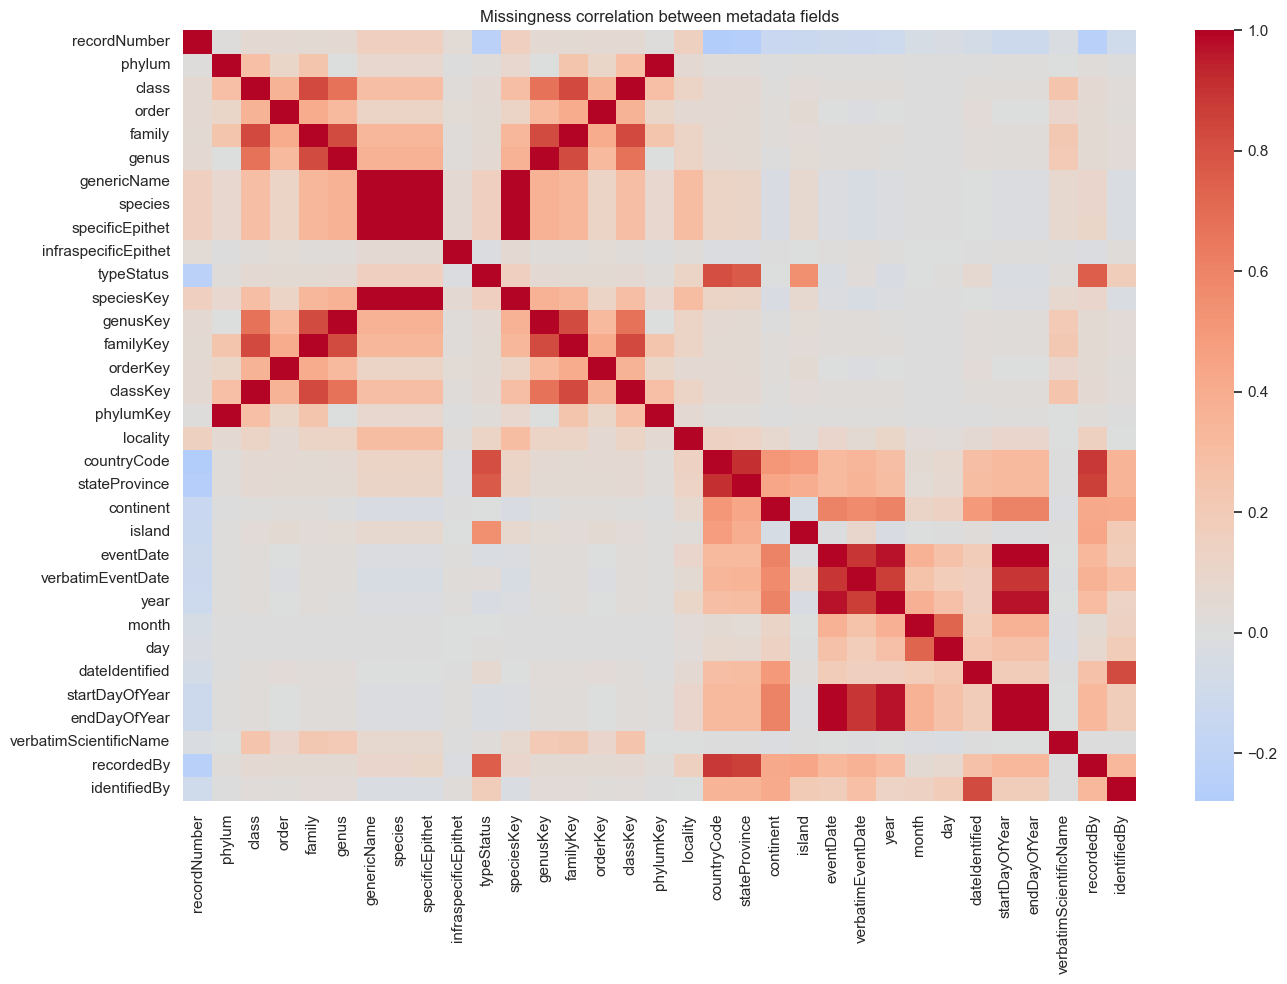


--- Top co-missing field pairs ---


,field_1,field_2,missing_corr
177,genericName,species,1.000000
479,eventDate,endDayOfYear,1.000000
206,species,speciesKey,1.000000
518,startDayOfYear,endDayOfYear,1.000000
478,eventDate,startDayOfYear,1.000000
181,genericName,speciesKey,1.000000
46,phylum,phylumKey,1.000000
75,class,classKey,1.000000
130,family,familyKey,1.000000
103,order,orderKey,1.000000



--- Top conditional missingness relationships ---


,A_missing,B_missing,P(B|A)
3633,endDayOfYear,eventDate,1.0
2926,countryCode,continent,1.0
1395,phylum,month,1.0
1394,phylum,year,1.0
1393,phylum,verbatimEventDate,1.0
1392,phylum,eventDate,1.0
1391,phylum,island,1.0
3673,verbatimScientificName,genus,1.0
1389,phylum,stateProvince,1.0
3674,verbatimScientificName,genericName,1.0


In [763]:
print_header("MISSINGNESS COOCURRENCE ANALYSIS")

missingness_cols = [c for c in existing_priority_columns if c in df_mm.columns]
missing_matrix = df_mm[missingness_cols].isna().astype(int)

#dropping columns with almost no variation in missingness
missing_var = missing_matrix.var()
informative_missingness_cols = missing_var[missing_var > 0].index.tolist()

missing_matrix = missing_matrix[informative_missingness_cols]
print("Missingness matrix shape after removing zero-variance columns:", missing_matrix.shape)

#displaying matrix
print("Missingness matrix shape:", missing_matrix.shape)

missing_corr = missing_matrix.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(missing_corr, cmap="coolwarm", center=0)
plt.title("Missingness correlation between metadata fields")
plt.tight_layout()
plt.show()

corr_pairs = (
    missing_corr
    .where(np.triu(np.ones(missing_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["field_1", "field_2", "missing_corr"]
top_pairs = corr_pairs.sort_values("missing_corr", ascending=False).head(20)
show_table("Top co-missing field pairs", top_pairs, n=20)

conditional_results = []
for col_a in missingness_cols:
    for col_b in missingness_cols:
        if col_a != col_b:
            conditional_results.append(
                (col_a, col_b, conditional_missingness(df_mm, col_a, col_b))
            )

cond_df = pd.DataFrame(conditional_results, columns=["A_missing", "B_missing", "P(B|A)"])
top_conditional = cond_df.sort_values("P(B|A)", ascending=False).head(20)
show_table("Top conditional missingness relationships", top_conditional, n=20)



ORDER-SPECIFIC MISSINGNESS CO-OCCURRENCE ANALYSIS
Order missingness matrix shape: (21730, 23)


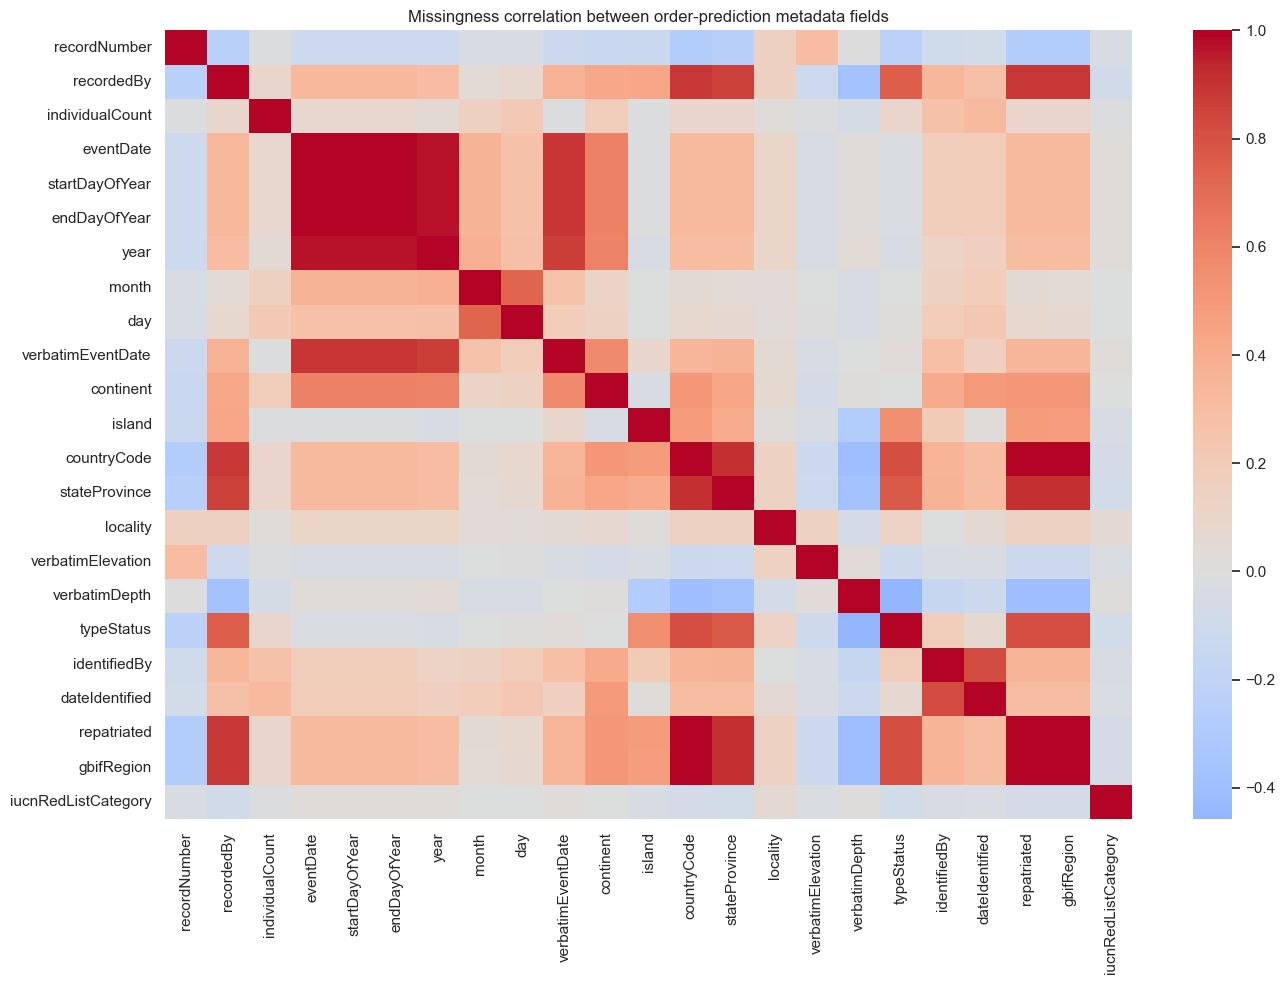


--- Top co-missing field pairs (order prediction) ---


,field_1,field_2,missing_corr
82,startDayOfYear,endDayOfYear,1.000000
63,eventDate,startDayOfYear,1.000000
64,eventDate,endDayOfYear,1.000000
205,countryCode,repatriated,1.000000
250,repatriated,gbifRegion,0.999821
206,countryCode,gbifRegion,0.999821
100,endDayOfYear,year,0.968417
83,startDayOfYear,year,0.968417
65,eventDate,year,0.968417
215,stateProvince,gbifRegion,0.908148



--- Top conditional missingness relationships (order prediction) ---


,A_missing,B_missing,P(B|A)
114,endDayOfYear,startDayOfYear,1.0
116,endDayOfYear,month,1.0
283,countryCode,repatriated,1.0
284,countryCode,gbifRegion,1.0
452,repatriated,countryCode,1.0
161,month,day,1.0
93,startDayOfYear,year,1.0
139,year,day,1.0
138,year,month,1.0
450,repatriated,continent,1.0


In [764]:
print_header("ORDER-SPECIFIC MISSINGNESS CO-OCCURRENCE ANALYSIS")

order_exclude = [
    "order",
    "orderKey",

    #taxonomy leakage
    "scientificName",
    "acceptedScientificName",
    "verbatimScientificName",
    "higherClassification",
    "family",
    "familyKey",
    "genus",
    "genusKey",
    "genericName",
    "species",
    "speciesKey",
    "specificEpithet",
    "infraspecificEpithet",
    "acceptedNameUsageID",
    "taxonKey",
    "acceptedTaxonKey",

    #stricter taxonomy exclusions
    "class",
    "classKey",
    "phylum",
    "phylumKey",
    "kingdom",
    "kingdomKey",

    #derived taxonomy helpers
    "has_family",
    "has_order",
    "taxonomy_depth",
]

order_missingness_cols = [
    c for c in df_mm.columns
    if c not in order_exclude
]

missing_matrix = df_mm[order_missingness_cols].isna().astype(int)

#removing zero-variance missingness columns
missing_var = missing_matrix.var()
informative_missingness_cols = missing_var[missing_var > 0].index.tolist()

missing_matrix = missing_matrix[informative_missingness_cols]

print("Order missingness matrix shape:", missing_matrix.shape)

missing_corr = missing_matrix.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(missing_corr, cmap="coolwarm", center=0)
plt.title("Missingness correlation between order-prediction metadata fields")
plt.tight_layout()
plt.show()

corr_pairs = (
    missing_corr
    .where(np.triu(np.ones(missing_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["field_1", "field_2", "missing_corr"]

top_pairs_order = (
    corr_pairs
    .sort_values("missing_corr", ascending=False)
    .head(20)
)

show_table(
    "Top co-missing field pairs (order prediction)",
    top_pairs_order,
    n=20
)

conditional_results = []

for col_a in informative_missingness_cols:
    for col_b in informative_missingness_cols:
        if col_a != col_b:
            conditional_results.append(
                (col_a, col_b, conditional_missingness(df_mm, col_a, col_b))
            )

cond_df_order = pd.DataFrame(
    conditional_results,
    columns=["A_missing", "B_missing", "P(B|A)"]
)

top_conditional_order = (
    cond_df_order
    .sort_values("P(B|A)", ascending=False)
    .head(20)
)

show_table(
    "Top conditional missingness relationships (order prediction)",
    top_conditional_order,
    n=20
)


UNIVARIATE ANALYSIS OF TAXONOMIC FIELDS

Top values for kingdom:


kingdom
Animalia          21709
Chromista            11
incertae sedis       10
Name: count, dtype: Int64

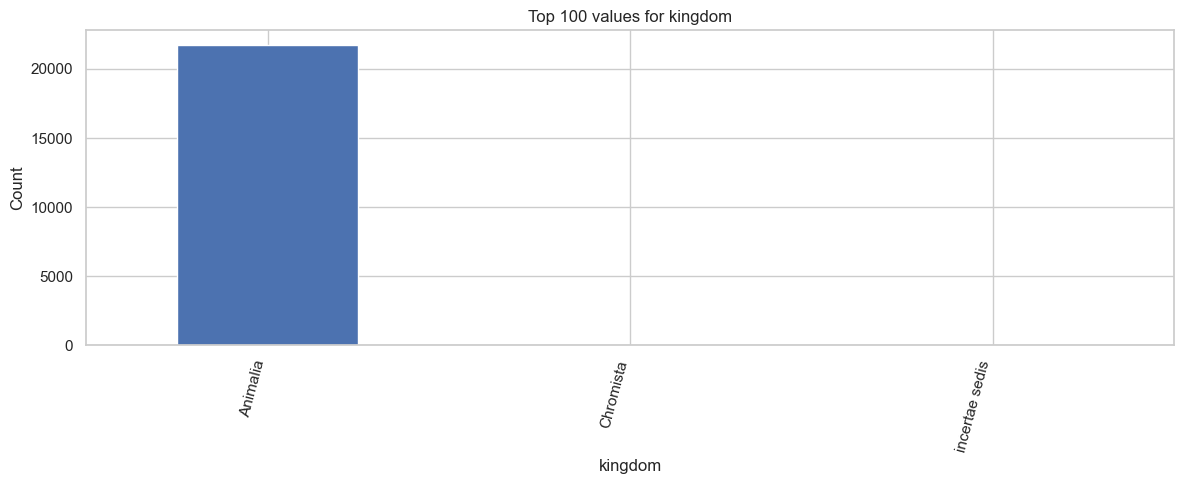


Top values for phylum:


phylum
Mollusca           21209
Arthropoda            94
Chordata              81
Bryozoa               72
Echinodermata         70
<NA>                  69
Annelida              40
Cnidaria              39
Brachiopoda           35
Foraminifera          11
Platyhelminthes       10
Name: count, dtype: Int64

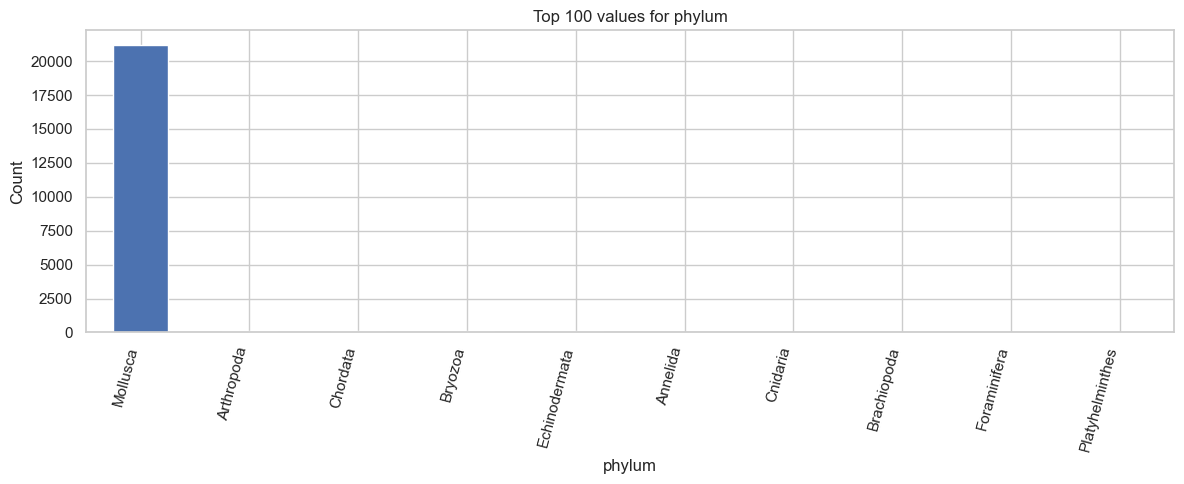


Top values for class:


class
Gastropoda        10923
Bivalvia           9211
<NA>                829
Polyplacophora      242
Scaphopoda          233
Polychaeta           40
Echinoidea           39
Anthozoa             32
Ostracoda            28
Maxillopoda          27
Gymnolaemata         25
Malacostraca         18
Cephalopoda          18
Rhynchonellata       18
Insecta              15
Ophiuroidea           7
Asteroidea            6
Hydrozoa              5
Crinoidea             3
Arachnida             3
Elasmobranchii        2
Mammalia              2
Lingulata             2
Stenolaemata          1
Branchiopoda          1
Name: count, dtype: Int64

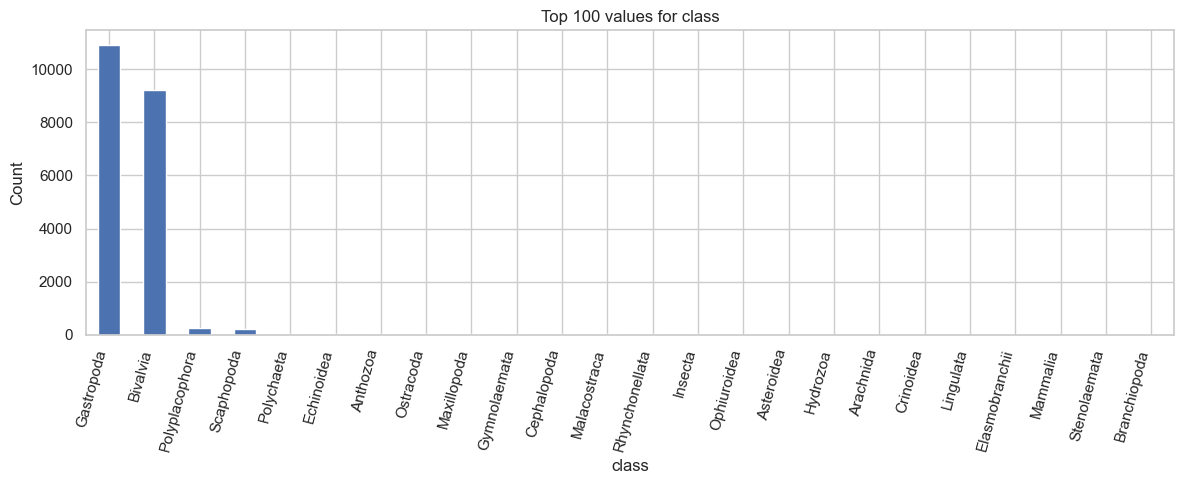


Top values for order:


order
<NA>                 4609
Neogastropoda        2735
Littorinimorpha      2535
Cardiida             1440
Venerida             1048
Sphaeriida            913
Carditida             850
Galeommatida          835
Stylommatophora       794
Cephalaspidea         778
Myida                 586
Pectinida             548
Lucinida              477
Arcida                458
Trochida              444
Mytilida              393
Nuculida              350
Nuculanida            322
Adapedonta            265
Dentaliida            184
Ostreida              149
Lepidopleurida        118
Limida                117
Chitonida             107
Lepetellida            83
Architaenioglossa      71
Pteropoda              58
Cycloneritida          40
Gadilida               39
Sabellida              34
Scleractinia           29
Ellobiida              27
Gastrochaenida         26
Cheilostomatida        25
Cyrtodontida           21
Sessilia               19
Unionida               19
Decapoda               18
Terebr

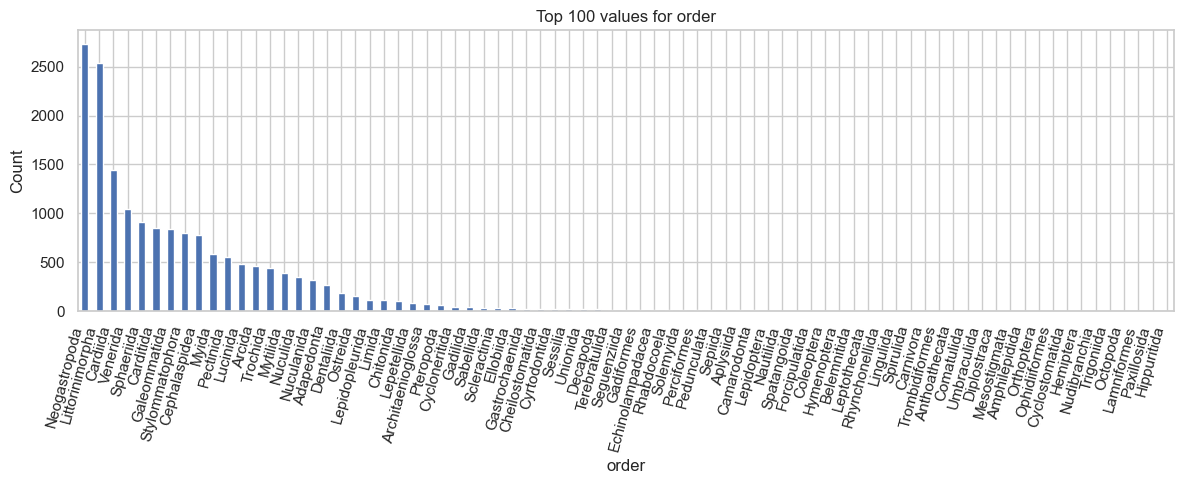


Top values for family:


family
Pyramidellidae       1227
<NA>                 1071
Sphaeriidae           913
Lasaeidae             727
Astartidae            614
Veneridae             584
Cardiidae             581
Rissoidae             545
Mytilidae             393
Tellinidae            387
Planorbidae           383
Nassariidae           354
Nuculidae             350
Semelidae             349
Pectinidae            348
Lucinidae             338
Mangeliidae           323
Corbulidae            285
Naticidae             278
Succineidae           262
Muricidae             261
Epitoniidae           237
Valvatidae            234
Hydrobiidae           219
Eulimidae             212
Arcidae               202
Bithyniidae           200
Conidae               198
Turridae              197
Carditidae            191
Raphitomidae          188
Retusidae             182
Lymnaeidae            182
Yoldiidae             173
Myidae                167
Cerithiidae           164
Trochidae             159
Mactridae             157
Turri

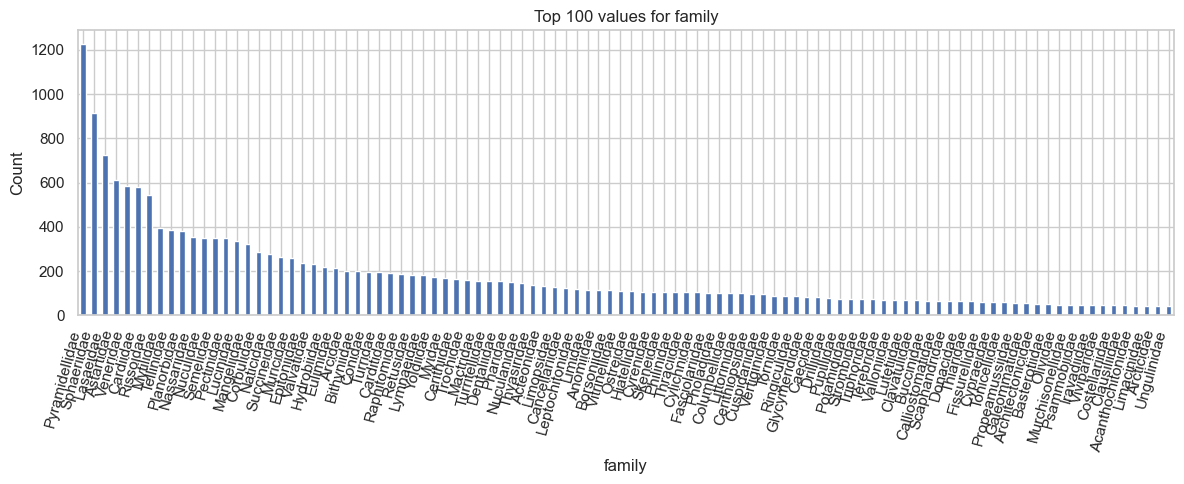


Top values for genus:


genus
<NA>               1180
Astarte             475
Euglesa             465
Abra                326
Pisidium            301
Odostomia           300
Nucula              293
Valvata             209
Succinea            189
Rissoa              188
Turbonilla          184
Retusa              182
Mangelia            172
Bithynia            172
Parvicardium        147
Conus               144
Alvania             141
Nassarius           140
Epitonium           140
Dentalium           136
Altenaeum           135
Musculus            130
Limopsis            128
Parthenina          128
Spisula             119
Varicorbula         118
Leptochiton         118
Yoldiella           112
Circulus            111
Peringia            110
Timoclea            108
Thracia             105
Cylichna            101
Gyraulus            101
Ostrea              100
Eulimella           100
Turritella           99
Acteon               98
Megastomia           98
Kurtiella            97
Sphenia              96
Corbula   

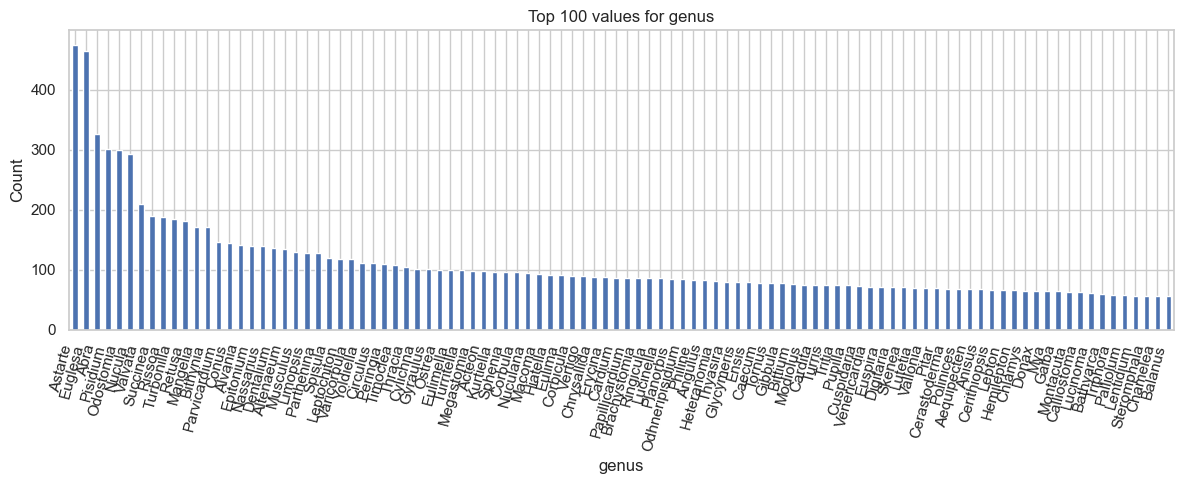


Top values for species:


species
<NA>                               6479
Valvata piscinalis                  164
Altenaeum dawsoni                   133
Pisidium amnicum                    122
Varicorbula gibba                   117
Bithynia tentaculata                115
Peringia ulvae                      109
Euglesa supina                      104
Timoclea ovata                      103
Abra alba                            99
Euglesa casertana                    99
Kurtiella bidentata                  97
Euglesa henslowana                   97
Leptochiton asellus                  92
Pisidium subtruncatum                88
Hiatella arctica                     88
Nucula nucleus                       87
Corbicula fluminalis                 85
Heteranomia squamula                 82
Astarte montagui                     82
Sphenia binghami                     78
Odhneripisidium moitessierianum      78
Brachystomia eulimoides              76
Succinea elegans                     71
Odostomia turrita               

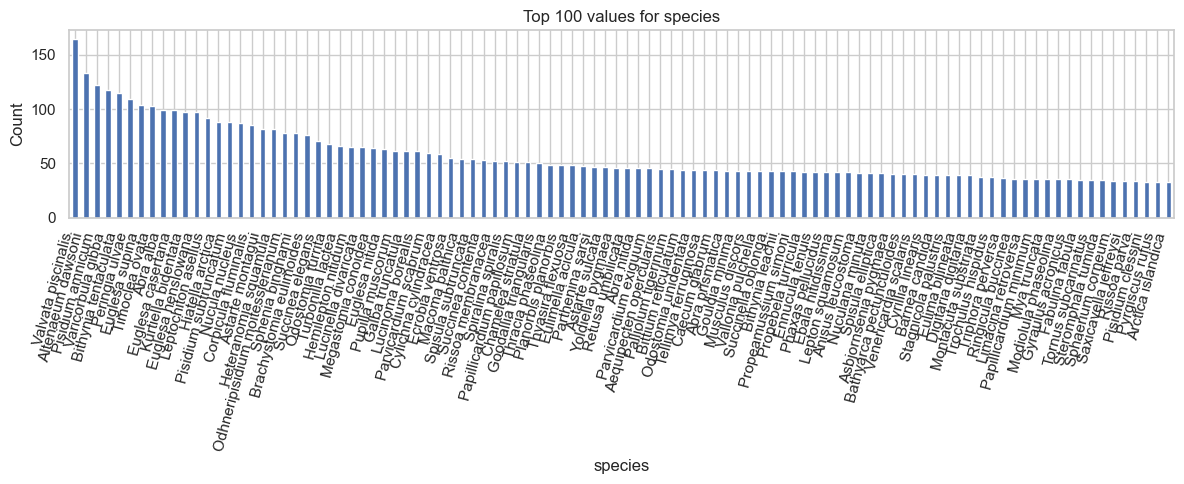

In [765]:
print_header("UNIVARIATE ANALYSIS OF TAXONOMIC FIELDS")

univariate_cols = [
    c for c in ["kingdom","phylum", "class", "order", "family", "genus", "species"]
    if c in df_mm.columns
]

for col in univariate_cols:
    print(f"\nTop values for {col}:")
    display(safe_value_counts(df_mm, col, top_n=100))
    plot_top_counts(df_mm[df_mm[col].notna()], col, top_n=100)

In [766]:
print_header("CHECKING PHYLUM DISTRIBUTION IN MULTIMODAL SUBSET")

phylum_summary = (
    df_mm["phylum"]
    .value_counts(dropna=False)
    .rename_axis("phylum")
    .reset_index(name="count")
)

phylum_summary["pct"] = phylum_summary["count"] / len(df_mm) * 100
show_table("Phylum distribution", phylum_summary, n=30)


CHECKING PHYLUM DISTRIBUTION IN MULTIMODAL SUBSET

--- Phylum distribution ---


,phylum,count,pct
0,Mollusca,21209,97.602393
1,Arthropoda,94,0.432582
2,Chordata,81,0.372757
3,Bryozoa,72,0.331339
4,Echinodermata,70,0.322135
5,<NA>,69,0.317533
6,Annelida,40,0.184077
7,Cnidaria,39,0.179475
8,Brachiopoda,35,0.161068
9,Foraminifera,11,0.050621


In [767]:
print_header("INSPECTING NON-MOLLUSCA AND MISSING PHYLUM RECORDS")

wanted_cols = [
    "gbifID", "phylum", "class", "order", "family",
    "genus", "species", "image", "image_path",
    "identifier", "accessURI", "metadata",
    "metadata_realistic", "metadata_strict"
]

tax_cols = [c for c in wanted_cols if c in df_mm.columns]

print("Columns used for inspection:")
print(tax_cols)

non_mollusca = df_mm[
    df_mm["phylum"].notna() & (df_mm["phylum"] != "Mollusca")
].copy()

missing_phylum = df_mm[df_mm["phylum"].isna()].copy()

print("Non-Mollusca rows:", len(non_mollusca))
print("Missing phylum rows:", len(missing_phylum))

if len(missing_phylum) > 0:
    show_table(
        "Random missing-phylum examples",
        missing_phylum.sample(min(10, len(missing_phylum)), random_state=42)[tax_cols],
        n=10,
    )
else:
    print("No missing-phylum records.")

if len(non_mollusca) > 0:
    show_table(
        "Random non-Mollusca examples",
        non_mollusca.sample(min(15, len(non_mollusca)), random_state=42)[tax_cols],
        n=15,
    )
else:
    print("No non-Mollusca records.")


INSPECTING NON-MOLLUSCA AND MISSING PHYLUM RECORDS
Columns used for inspection:
['gbifID', 'phylum', 'class', 'order', 'family', 'genus', 'species']
Non-Mollusca rows: 452
Missing phylum rows: 69

--- Random missing-phylum examples ---


,gbifID,phylum,class,order,family,genus,species
22429,2443036574,<NA>,<NA>,<NA>,<NA>,Balanus,<NA>
831,2443036786,<NA>,<NA>,<NA>,<NA>,Echinocardium,<NA>
64406,2443025175,<NA>,<NA>,<NA>,<NA>,Balanus,<NA>
4220,2443037428,<NA>,<NA>,<NA>,<NA>,Balanus,<NA>
76573,2443034433,<NA>,<NA>,<NA>,<NA>,Scalpellum,Scalpellum
15252,2443040456,<NA>,<NA>,<NA>,<NA>,Balanus,<NA>
9361,2443039264,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
50613,2443041593,<NA>,<NA>,<NA>,<NA>,Echinocardium,<NA>
59355,2443025501,<NA>,<NA>,<NA>,<NA>,Balanus,<NA>
10725,2443025584,<NA>,<NA>,<NA>,<NA>,Balanus,<NA>



--- Random non-Mollusca examples ---


,gbifID,phylum,class,order,family,genus,species
72086,2443039744,Arthropoda,Insecta,Hymenoptera,Ichneumonidae,Tryphon,<NA>
11815,2443040046,Bryozoa,<NA>,<NA>,<NA>,<NA>,<NA>
80492,2443037519,Arthropoda,Malacostraca,Decapoda,<NA>,<NA>,<NA>
80196,2443036015,Annelida,Polychaeta,Sabellida,Serpulidae,Ditrupa,<NA>
39056,2443035900,Arthropoda,Ostracoda,<NA>,<NA>,<NA>,<NA>
48939,2443039527,Annelida,Polychaeta,Sabellida,Serpulidae,Serpula,<NA>
70352,2443034616,Echinodermata,Echinoidea,Echinolampadacea,Fibulariidae,Echinocyamus,Echinocyamus pusillus
27161,2443038400,Chordata,<NA>,Gadiformes,Gadidae,Ovigadiculus,<NA>
92696,2443040227,Echinodermata,<NA>,<NA>,<NA>,<NA>,<NA>
9833,2443026537,Chordata,Elasmobranchii,Lamniformes,Odontaspididae,Carcharias,Carcharias tricuspidatus


In [768]:
#wanting to focus on molluscs, so filtering out other phylums to remove noise
print_header("RETAINING MOLLUSC PHYLUM")


print_header("FILTERING TO MOLLUSCA ONLY")

df_mm = df_mm[df_mm["phylum"] == "Mollusca"].copy()

print("Filtered dataset shape:", df_mm.shape)

print("\nRemaining phylum counts:")
display(df_mm["phylum"].value_counts(dropna=False))


RETAINING MOLLUSC PHYLUM

FILTERING TO MOLLUSCA ONLY
Filtered dataset shape: (21209, 84)

Remaining phylum counts:


phylum
Mollusca    21209
Name: count, dtype: Int64

In [769]:
print_header("CHECKING PHYLUM DISTRIBUTION IN MULTIMODAL SUBSET")

phylum_summary = (
    df_mm["phylum"]
    .value_counts(dropna=False)
    .rename_axis("phylum")
    .reset_index(name="count")
)

phylum_summary["pct"] = phylum_summary["count"] / len(df_mm) * 100
show_table("Phylum distribution", phylum_summary, n=30)


CHECKING PHYLUM DISTRIBUTION IN MULTIMODAL SUBSET

--- Phylum distribution ---


,phylum,count,pct
0,Mollusca,21209,100.0


In [770]:
df_mm["family"].nunique()

288

In [771]:
df_mm["family"].unique()

<StringArray>
[      'Sphaeriidae',         'Naticidae', 'Acanthochitonidae',
    'Pyramidellidae',      'Ringiculidae',    'Truncatellidae',
                <NA>,         'Mactridae',       'Mangeliidae',
        'Pectinidae',
 ...
   'Ptychatractidae',   'Plesiotrochidae',     'Cingulopsidae',
      'Sportellidae',        'Trapezidae',        'Nacellidae',
     'Tjaernoeiidae',  'Cochlostomatidae',        'Caprinidae',
         'Tegulidae']
Length: 289, dtype: string

In [772]:
df_mm["order"].nunique()

44

In [773]:
df_mm["order"].unique()

<StringArray>
[       'Sphaeriida',   'Littorinimorpha',         'Chitonida',
                <NA>,     'Cephalaspidea',          'Venerida',
     'Neogastropoda',         'Pectinida',      'Cyrtodontida',
   'Stylommatophora',          'Cardiida',      'Galeommatida',
          'Nuculida',             'Myida',          'Lucinida',
          'Trochida',         'Carditida',        'Adapedonta',
    'Lepidopleurida',            'Arcida',          'Ostreida',
          'Mytilida',            'Limida',        'Dentaliida',
           'Sepiida',        'Nuculanida',          'Gadilida',
 'Architaenioglossa',    'Gastrochaenida',         'Pteropoda',
       'Lepetellida',         'Spirulida',         'Ellobiida',
     'Cycloneritida',          'Unionida',          'Octopoda',
        'Trigoniida',       'Belemnitida',       'Seguenziida',
      'Nudibranchia',         'Solemyida',         'Aplysiida',
         'Nautilida',       'Umbraculida',       'Hippuritida']
Length: 45, dtype: string

In [774]:
#recap
df_mm["order"].value_counts()

order
Neogastropoda        2735
Littorinimorpha      2535
Cardiida             1440
Venerida             1048
Sphaeriida            913
Carditida             850
Galeommatida          835
Stylommatophora       794
Cephalaspidea         778
Myida                 586
Pectinida             548
Lucinida              477
Arcida                458
Trochida              444
Mytilida              393
Nuculida              350
Nuculanida            322
Adapedonta            265
Dentaliida            184
Ostreida              149
Lepidopleurida        118
Limida                117
Chitonida             107
Lepetellida            83
Architaenioglossa      71
Pteropoda              58
Cycloneritida          40
Gadilida               39
Ellobiida              27
Gastrochaenida         26
Cyrtodontida           21
Unionida               19
Seguenziida            12
Solemyida               9
Sepiida                 6
Aplysiida               6
Nautilida               5
Belemnitida             4
Spirul

This represents a challenge in long tail family classification 

In [775]:
print_header("TARGET: FAMILY QUALITY CHECK")

family_summary = pd.DataFrame({
    "n_records": [len(df_mm)],
    "n_non_missing_family": [df_mm["family"].notna().sum()],
    "n_missing_family": [df_mm["family"].isna().sum()],
    "missing_family_pct": [df_mm["family"].isna().mean() * 100],
    "n_unique_families": [df_mm["family"].nunique(dropna=True)]
})

show_table("Family target summary", family_summary, n=10)

family_counts = (
    df_mm["family"]
    .value_counts(dropna=False)
    .rename_axis("family")
    .reset_index(name="count")
)

family_counts["pct"] = family_counts["count"] / len(df_mm) * 100

show_table("Family label distribution", family_counts, n=50)


TARGET: FAMILY QUALITY CHECK

--- Family target summary ---


,n_records,n_non_missing_family,n_missing_family,missing_family_pct,n_unique_families
0,21209,20409,800,3.771984,288



--- Family label distribution ---


,family,count,pct
0,Pyramidellidae,1227,5.78528
1,Sphaeriidae,913,4.304776
2,<NA>,800,3.771984
3,Lasaeidae,727,3.42779
4,Astartidae,614,2.894997
5,Veneridae,584,2.753548
6,Cardiidae,581,2.739403
7,Rissoidae,545,2.569664
8,Mytilidae,393,1.852987
9,Tellinidae,387,1.824697


In [776]:
print_header("RARE FAMILY LABELS")

rare_threshold = 10

rare_families = family_counts[
    (family_counts["family"].notna()) &
    (family_counts["count"] < rare_threshold)
]

print(f"Families with fewer than {rare_threshold} records:", len(rare_families))
show_table("Rare family labels", rare_families, n=100)


RARE FAMILY LABELS
Families with fewer than 10 records: 102

--- Rare family labels ---


,family,count,pct
187,Geomitridae,9,0.042435
188,Vanikoridae,9,0.042435
189,Placunidae,9,0.042435
190,Babyloniidae,9,0.042435
191,Aglajidae,9,0.042435
192,Nucinellidae,8,0.03772
193,Cavoliniidae,8,0.03772
194,Tornatinidae,8,0.03772
195,Cassiopidae,8,0.03772
196,Mathildidae,8,0.03772


In [777]:
counts = df_mm["family"].value_counts()

for k in [5, 10, 20, 50]:
    n_classes = (counts >= k).sum()
    n_samples = counts[counts >= k].sum()
    print(f">= {k}: {n_classes} families, {n_samples} samples")

>= 5: 220 families, 20264 samples
>= 10: 186 families, 20037 samples
>= 20: 146 families, 19467 samples
>= 50: 89 families, 17628 samples


In [778]:
print_header("TARGET: ORDER QUALITY CHECK")

order_summary = pd.DataFrame({
    "n_records": [len(df_mm)],
    "n_non_missing_order": [df_mm["order"].notna().sum()],
    "n_missing_order": [df_mm["order"].isna().sum()],
    "missing_order_pct": [df_mm["order"].isna().mean() * 100],
    "n_unique_orders": [df_mm["order"].nunique(dropna=True)]
})

show_table("Order target summary", order_summary, n=10)

order_counts = (
    df_mm["order"]
    .value_counts(dropna=False)
    .rename_axis("order")
    .reset_index(name="count")
)

order_counts["pct"] = order_counts["count"] / len(df_mm) * 100

show_table("Order label distribution", order_counts, n=50)


TARGET: ORDER QUALITY CHECK

--- Order target summary ---


,n_records,n_non_missing_order,n_missing_order,missing_order_pct,n_unique_orders
0,21209,16879,4330,20.415861,44



--- Order label distribution ---


,order,count,pct
0,<NA>,4330,20.415861
1,Neogastropoda,2735,12.895469
2,Littorinimorpha,2535,11.952473
3,Cardiida,1440,6.78957
4,Venerida,1048,4.941299
5,Sphaeriida,913,4.304776
6,Carditida,850,4.007733
7,Galeommatida,835,3.937008
8,Stylommatophora,794,3.743694
9,Cephalaspidea,778,3.668254


In [779]:
print_header("RARE ORDER LABELS")

rare_threshold = 10

rare_orders = order_counts[
    (order_counts["order"].notna()) &
    (order_counts["count"] < rare_threshold)
]

print(f"Orders with fewer than {rare_threshold} records:", len(rare_orders))
show_table("Rare order labels", rare_orders, n=100)


RARE ORDER LABELS
Orders with fewer than 10 records: 11

--- Rare order labels ---


,order,count,pct
34,Solemyida,9,0.042435
35,Sepiida,6,0.02829
36,Aplysiida,6,0.02829
37,Nautilida,5,0.023575
38,Belemnitida,4,0.01886
39,Spirulida,2,0.00943
40,Octopoda,1,0.004715
41,Trigoniida,1,0.004715
42,Nudibranchia,1,0.004715
43,Umbraculida,1,0.004715


In [780]:
counts = df_mm["order"].value_counts()

for k in [5, 10, 20, 50]:
    n_classes = (counts >= k).sum()
    n_samples = counts[counts >= k].sum()
    print(f">= {k}: {n_classes} orders, {n_samples} samples")

>= 5: 37 orders, 16868 samples
>= 10: 33 orders, 16842 samples
>= 20: 31 orders, 16811 samples
>= 50: 26 orders, 16658 samples


In [781]:
print_header("MISSINGNESS FOR CANDIDATE TARGET VARIABLES")

target_cols = ["family", "order"]

target_missing_summary = pd.DataFrame({
    "field": target_cols,
    "missing_count": [df_mm[c].isna().sum() for c in target_cols if c in df_mm.columns],
    "missing_pct": [df_mm[c].isna().mean() * 100 for c in target_cols if c in df_mm.columns],
    "total_rows": [len(df_mm) for c in target_cols if c in df_mm.columns],
})

show_table("Candidate target missingness", target_missing_summary, n=10)


MISSINGNESS FOR CANDIDATE TARGET VARIABLES

--- Candidate target missingness ---


,field,missing_count,missing_pct,total_rows
0,family,800,3.771984,21209
1,order,4330,20.415861,21209



CHECKING FOR TAXONOMY COMPLETENESS
Taxonomy depth summary:


count    21209.000000
mean         6.397944
std          0.992839
min          2.000000
25%          6.000000
50%          7.000000
75%          7.000000
max          7.000000
Name: taxonomy_depth, dtype: float64

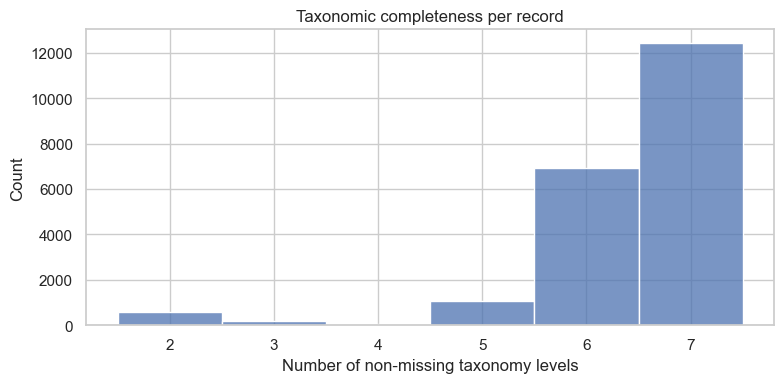

In [782]:
print_header("CHECKING FOR TAXONOMY COMPLETENESS")

tax_cols = [c for c in ["kingdom", "phylum", "class", "order", "family", "genus", "species"] if c in df_mm.columns]

if tax_cols:
    df_mm["taxonomy_depth"] = df_mm[tax_cols].notna().sum(axis=1)

    print("Taxonomy depth summary:")
    display(df_mm["taxonomy_depth"].describe())

    plt.figure(figsize=(8, 4)) 
    sns.histplot(df_mm["taxonomy_depth"], discrete=True)
    plt.title("Taxonomic completeness per record")
    plt.xlabel("Number of non-missing taxonomy levels")
    plt.tight_layout()
    plt.show()


Here, we can also see that most records are well-labeled, with full taxonomy from kingdom → species, however there is a small tail of incomplete records, and it may be of interest to complete these using multimodal methods.

To investigate which parts of the taxonomy are missing, percentages of missing data per taxonomy level is displayed below:

In [783]:
missing_by_tax = (
    df_mm[tax_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

print_header("MISSINGNESS PER TAXONOMIC LEVEL (%)")
display(missing_by_tax)


MISSINGNESS PER TAXONOMIC LEVEL (%)


species    28.605781
order      20.415861
genus       4.667830
family      3.771984
class       2.744118
kingdom     0.000000
phylum      0.000000
dtype: float64

Missingness increases further along in the taxonomic rank, as the rank gets more fine grained.

In [784]:
print_header("TAXONOMIC COMPLETENESS")

taxonomy_cols = [
    "phylum", "class", "order",
    "family", "genus", "species"
]

completeness = pd.DataFrame({
    "missing_pct": df_mm[taxonomy_cols].isna().mean() * 100,
    "non_missing": df_mm[taxonomy_cols].notna().sum()
}).sort_values("missing_pct")

display(completeness)


TAXONOMIC COMPLETENESS


,missing_pct,non_missing
phylum,0.000000,21209
class,2.744118,20627
family,3.771984,20409
genus,4.667830,20219
order,20.415861,16879
species,28.605781,15142


In [785]:
print_header("TAXONOMY DEPTH VS FAMILY (TARGET) AVAILABILITY")

df_mm["has_family"] = df_mm["family"].notna()

depth_vs_target = (
    df_mm.groupby("taxonomy_depth")["has_family"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "pct_has_family"})
)

depth_vs_target["pct_has_family"] *= 100

show_table("Taxonomy depth vs family availability", depth_vs_target, n=10)


TAXONOMY DEPTH VS FAMILY (TARGET) AVAILABILITY

--- Taxonomy depth vs family availability ---


,count,pct_has_family
taxonomy_depth,,
2,560,0.000000
3,178,0.000000
4,53,9.433962
5,1085,99.723502
6,6928,99.841224
7,12405,100.000000


In [786]:
print_header("TAXONOMY DEPTH VS ORDER (TARGET) AVAILABILITY")

df_mm["has_order"] = df_mm["order"].notna()

depth_vs_target_order = (
    df_mm.groupby("taxonomy_depth")["has_order"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "pct_has_order"})
)

depth_vs_target_order["pct_has_order"] *= 100

show_table("Taxonomy depth vs order availability", depth_vs_target_order, n=10)


TAXONOMY DEPTH VS ORDER (TARGET) AVAILABILITY

--- Taxonomy depth vs order availability ---


,count,pct_has_order
taxonomy_depth,,
2,560,0.000000
3,178,0.000000
4,53,90.566038
5,1085,20.645161
6,6928,60.652425
7,12405,100.000000


In [787]:
print_header("MISSINGNESS PER TAXONOMIC LEVEL")

tax_missing = pd.DataFrame({
    "missing_pct": df_mm[tax_cols].isna().mean() * 100,
    "non_missing_count": df_mm[tax_cols].notna().sum()
}).sort_values("missing_pct", ascending=False)

show_table("Taxonomic missingness by level", tax_missing, n=10)


MISSINGNESS PER TAXONOMIC LEVEL

--- Taxonomic missingness by level ---


,missing_pct,non_missing_count
species,28.605781,15142
order,20.415861,16879
genus,4.667830,20219
family,3.771984,20409
class,2.744118,20627
kingdom,0.000000,21209
phylum,0.000000,21209


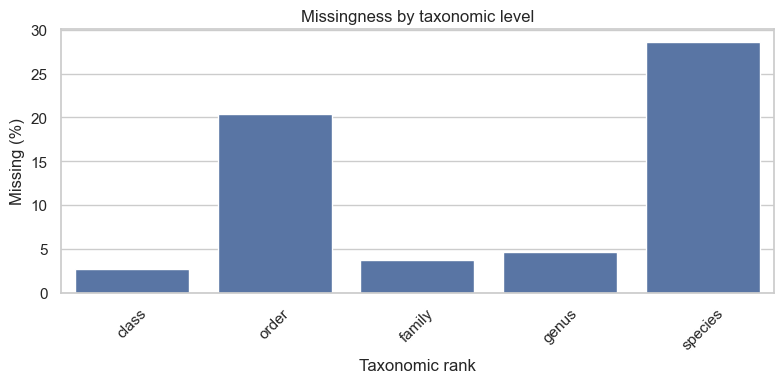

In [788]:
tax_order = ["class", "order", "family", "genus", "species"]

missing_by_tax_ordered = missing_by_tax.reindex(tax_order)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=missing_by_tax_ordered.index,
    y=missing_by_tax_ordered.values
)

plt.title("Missingness by taxonomic level")
plt.xlabel("Taxonomic rank")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [789]:
print_header("GENUS → ORDER RELATIONSHIP")

ctab_go = pd.crosstab(df_mm["genus"], df_mm["order"])
show_table("Genus vs order crosstab", ctab_go, n=20)


GENUS → ORDER RELATIONSHIP

--- Genus vs order crosstab ---


order,Adapedonta,Aplysiida,Architaenioglossa,Arcida,Belemnitida,Cardiida,Carditida,Cephalaspidea,Chitonida,Cycloneritida,Cyrtodontida,Dentaliida,Ellobiida,Gadilida,Galeommatida,Gastrochaenida,Lepetellida,Lepidopleurida,Limida,Littorinimorpha,Lucinida,Myida,Mytilida,Nautilida,Neogastropoda,Nuculanida,Nuculida,Nudibranchia,Octopoda,Ostreida,Pectinida,Pteropoda,Seguenziida,Sepiida,Solemyida,Sphaeriida,Stylommatophora,Trigoniida,Trochida,Umbraculida,Unionida,Venerida
genus,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Abra,0,0,0,0,0,326,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acanthocardia,0,0,0,0,0,49,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acanthochitona,0,0,0,0,0,0,0,0,43,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Accidenticulabrum,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acila,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acinodrillia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Aclis,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,44,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Actaeon,0,0,0,0,0,0,0,26,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acteocina,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [790]:
missing_order_subset = df_mm[df_mm["order"].isna() & df_mm["genus"].notna()]

print("Rows with missing order but known genus:", len(missing_order_subset))

Rows with missing order but known genus: 3609


In [791]:
genus_to_order = (
    df_mm[df_mm["order"].notna()]
    .groupby("genus")["order"]
    .nunique()
)

print("genus → order deterministic (%):",
      (genus_to_order == 1).mean() * 100)

genus → order deterministic (%): 100.0


In [792]:
genus_to_order = (
    df_mm[df_mm["family"].notna()]
    .groupby("genus")["family"]
    .nunique()
)

print("family → order deterministic (%):",
      (genus_to_order == 1).mean() * 100)

family → order deterministic (%): 99.90566037735849


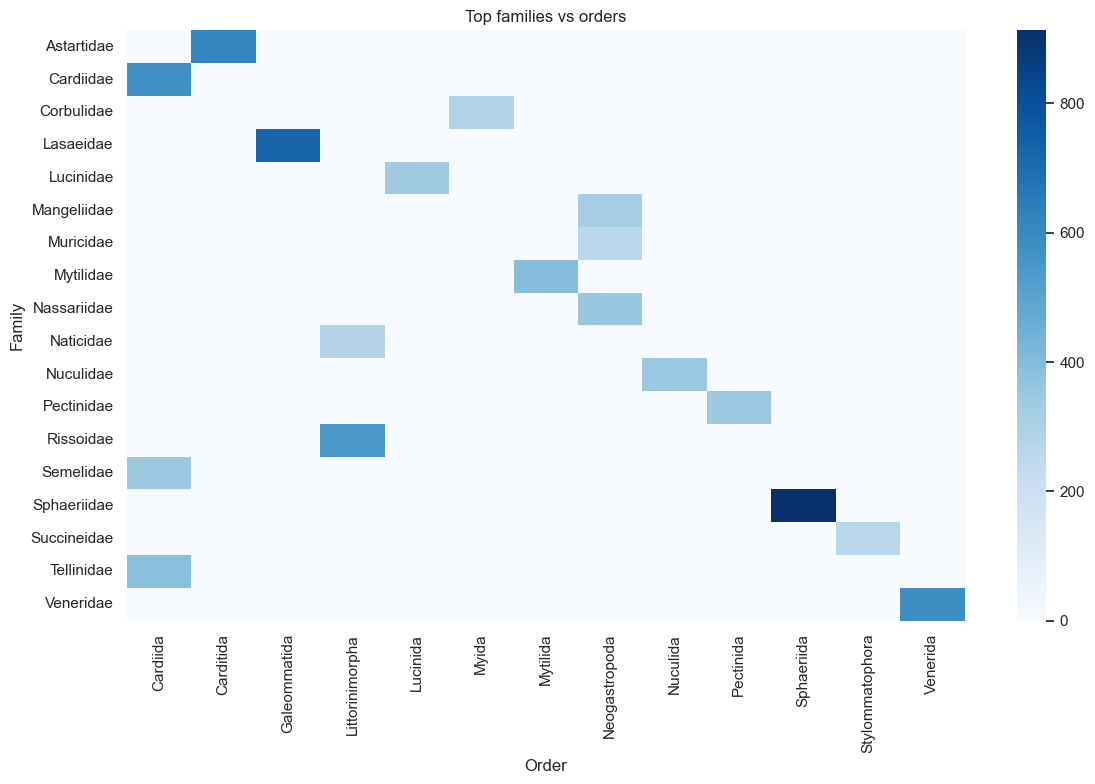

In [793]:
top_genera = df_mm["family"].value_counts().head(20).index
subset = df_mm[df_mm["family"].isin(top_genera)]

ctab = pd.crosstab(subset["family"], subset["order"])

plt.figure(figsize=(12, 8))
sns.heatmap(ctab, cmap="Blues")
plt.title("Top families vs orders")
plt.xlabel("Order")
plt.ylabel("Family")
plt.tight_layout()
plt.show()

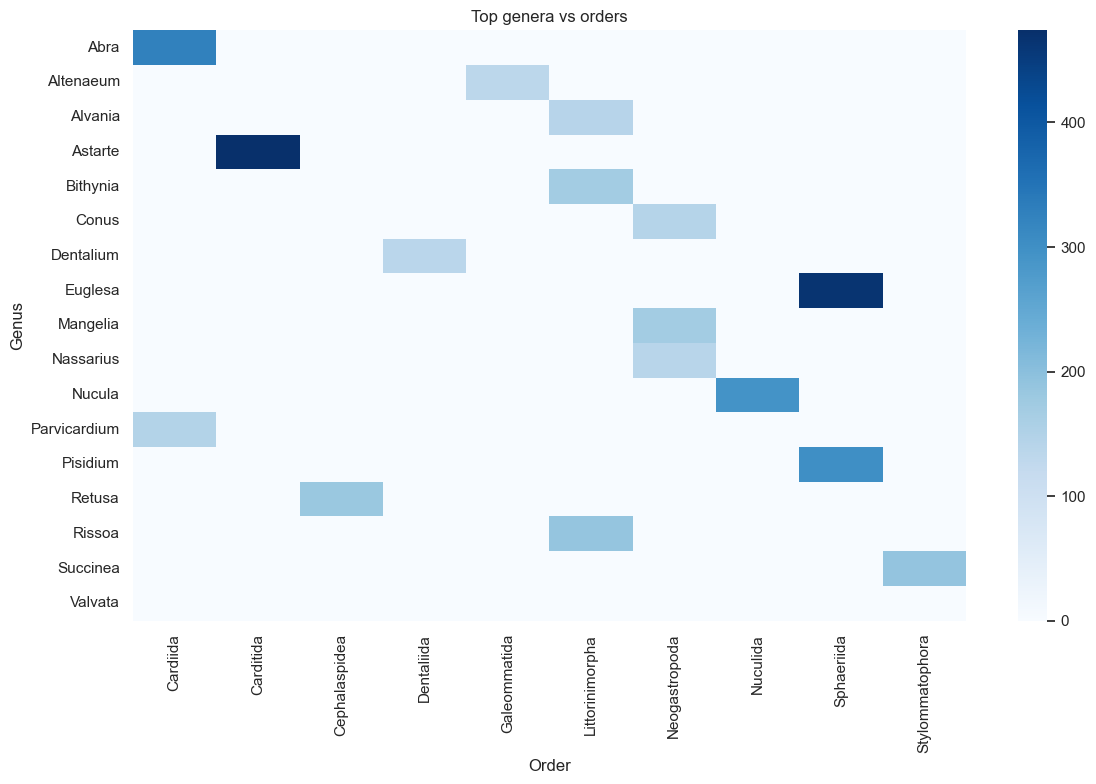

In [794]:
top_genera = df_mm["genus"].value_counts().head(20).index
subset = df_mm[df_mm["genus"].isin(top_genera)]

ctab = pd.crosstab(subset["genus"], subset["order"])

plt.figure(figsize=(12, 8))
sns.heatmap(ctab, cmap="Blues")
plt.title("Top genera vs orders")
plt.xlabel("Order")
plt.ylabel("Genus")
plt.tight_layout()
plt.show()


TOP ORDERS VS ASSOCIATED FAMILIES


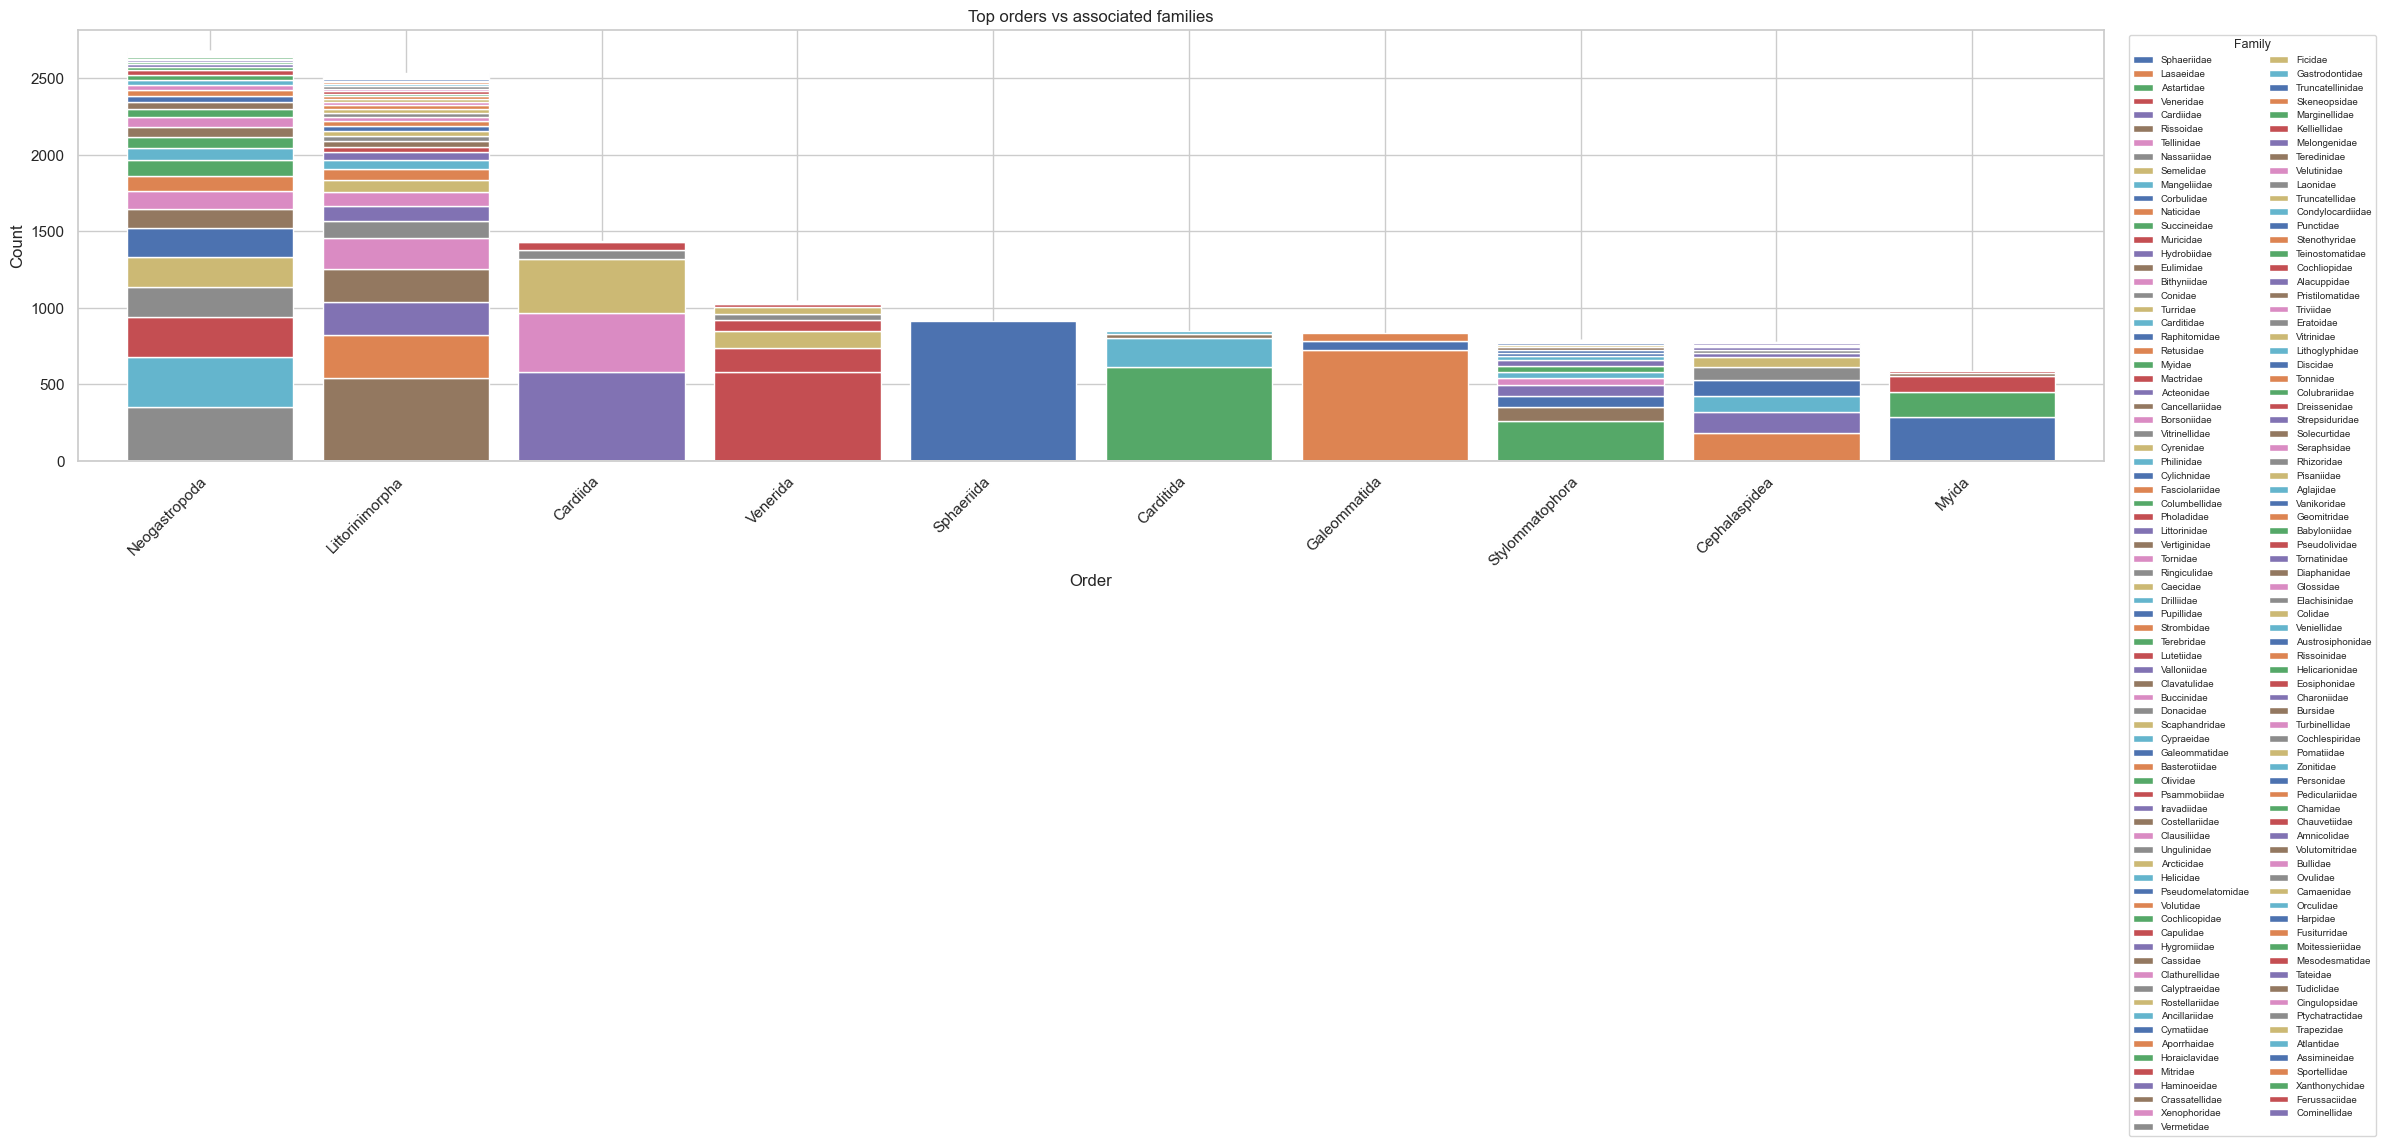

In [795]:
print_header("TOP ORDERS VS ASSOCIATED FAMILIES")

top_orders = df_mm["order"].value_counts().head(10).index
subset = df_mm[df_mm["order"].isin(top_orders)].copy()

ctab = pd.crosstab(subset["order"], subset["family"])

# Sort orders by total count
ctab = ctab.loc[ctab.sum(axis=1).sort_values(ascending=False).index]

# Sort families by total count, so dominant families appear first
ctab = ctab[ctab.sum(axis=0).sort_values(ascending=False).index]

ax = ctab.plot(
    kind="bar",
    stacked=True,
    figsize=(24, 9),
    width=0.85
)

plt.title("Top orders vs associated families")
plt.ylabel("Count")
plt.xlabel("Order")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Family",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=7,
    title_fontsize=9,
    ncol=2
)

plt.tight_layout()
plt.show()

In [796]:
print_header("CROSSTAB: ORDER vs FAMILY (COUNTS)")

ctab_order_family = pd.crosstab(df_mm["order"], df_mm["family"])

show_table("Order vs Family (counts)", ctab_order_family, n=20)


CROSSTAB: ORDER vs FAMILY (COUNTS)

--- Order vs Family (counts) ---


family,Acanthochitonidae,Acteonidae,Aglajidae,Akeridae,Alacuppidae,Amnicolidae,Ampullinidae,Anatomidae,Ancillariidae,Angariidae,Anomiidae,Antipleuridae,Aporrhaidae,Arcidae,Arcticidae,Assimineidae,Astartidae,Atlantidae,Aturiidae,Austrosiphonidae,Babyloniidae,Basterotiidae,Bithyniidae,Borsoniidae,Buccinidae,Bullidae,Bursidae,Caecidae,Calliostomatidae,Calyptraeidae,Camaenidae,Cancellariidae,Caprinidae,Capulidae,Cardiidae,Carditidae,Cassidae,Cavoliniidae,Chamidae,Charoniidae,Chauvetiidae,Chitonidae,Cingulopsidae,Clathurellidae,Clausiliidae,Clavatulidae,Cliidae,Cochlespiridae,Cochlicopidae,Cochliopidae,Cochlostomatidae,Colidae,Colloniidae,Colubrariidae,Columbellidae,Cominellidae,Condylocardiidae,Conidae,Corbulidae,Costellariidae,Crassatellidae,Cucullaeidae,Cyclophoridae,Cylichnidae,Cymatiidae,Cypraeidae,Cyrenidae,Dentaliidae,Diaphanidae,Dimyidae,Discidae,Donacidae,Dreissenidae,Drilliidae,Elachisinidae,Ellobiidae,Entalinidae,Eosiphonidae,Eratoidae,Eulimidae,Fasciolariidae,Ferussaciidae,Ficidae,Fissurellidae,Fusiturridae,Fustiariidae,Gadilidae,Galeommatidae,Gastrochaenidae,Gastrodontidae,Geomitridae,Glossidae,Glycymerididae,Goniodorididae,Gryphaeidae,Haminoeidae,Harpidae,Helicarionidae,Helicidae,Heliconoididae,Hiatellidae,Horaiclavidae,Hydrobiidae,Hygromiidae,Iravadiidae,Kelliellidae,Laevidentaliidae,Laonidae,Lasaeidae,Lepetellidae,Leptochitonidae,Limacinidae,Limidae,Limopsidae,Liotiidae,Lithoglyphidae,Littorinidae,Lucinidae,Lutetiidae,Mactridae,Malletiidae,Mangeliidae,Margaritidae,Marginellidae,Melongenidae,Mesodesmatidae,Mitridae,Moitessieriidae,Muricidae,Myidae,Myophoriidae,Mytilidae,Nassariidae,Naticidae,Nautilidae,Neritidae,Noetiidae,Nucinellidae,Nuculanidae,Nuculidae,Olividae,Orculidae,Ostreidae,Ovulidae,Palaeoctopodidae,Passaloteuthidae,Pectinidae,Pediculariidae,Pendromidae,Personidae,Pharidae,Phasianellidae,Philinidae,Pholadidae,Pinnidae,Pisaniidae,Placunidae,Plicatulidae,Pomatiidae,Pristilomatidae,Propeamussiidae,Psammobiidae,Pseudococculinidae,Pseudolividae,Pseudomelatomidae,Pteriidae,Ptychatractidae,Pulsellidae,Punctidae,Pupillidae,Raphitomidae,Retusidae,Rhizoridae,Ringiculidae,Rissoidae,Rissoinidae,Rostellariidae,Scaphandridae,Scissurellidae,Seguenziidae,Semelidae,Sepiidae,Sepiolidae,Seraphsidae,Skeneidae,Skeneopsidae,Solariellidae,Solecurtidae,Solemyidae,Solenidae,Sphaeriidae,Spirulirostridae,Spondylidae,Sportellidae,Stenothyridae,Strepsiduridae,Strombidae,Succineidae,Tateidae,Tegulidae,Teinostomatidae,Tellinidae,Terebridae,Teredinidae,Thyasiridae,Tonicellidae,Tonnidae,Tornatinidae,Tornidae,Trapezidae,Triviidae,Trochidae,Truncatellidae,Truncatellinidae,Tudiclidae,Turbinellidae,Turbinidae,Turridae,Umbraculidae,Ungulinidae,Unionidae,Valloniidae,Vanikoridae,Velutinidae,Veneridae,Veniellidae,Vermetidae,Vertiginidae,Vitrinellidae,Vitrinidae,Viviparidae,Volutidae,Volutomitridae,Xanthonychidae,Xenophoridae,Yoldiidae,Zonitidae
order,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Adapedonta,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,153,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Aplysiida,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


MISSINGNESS HEATMAP FOR KEY FIELDS


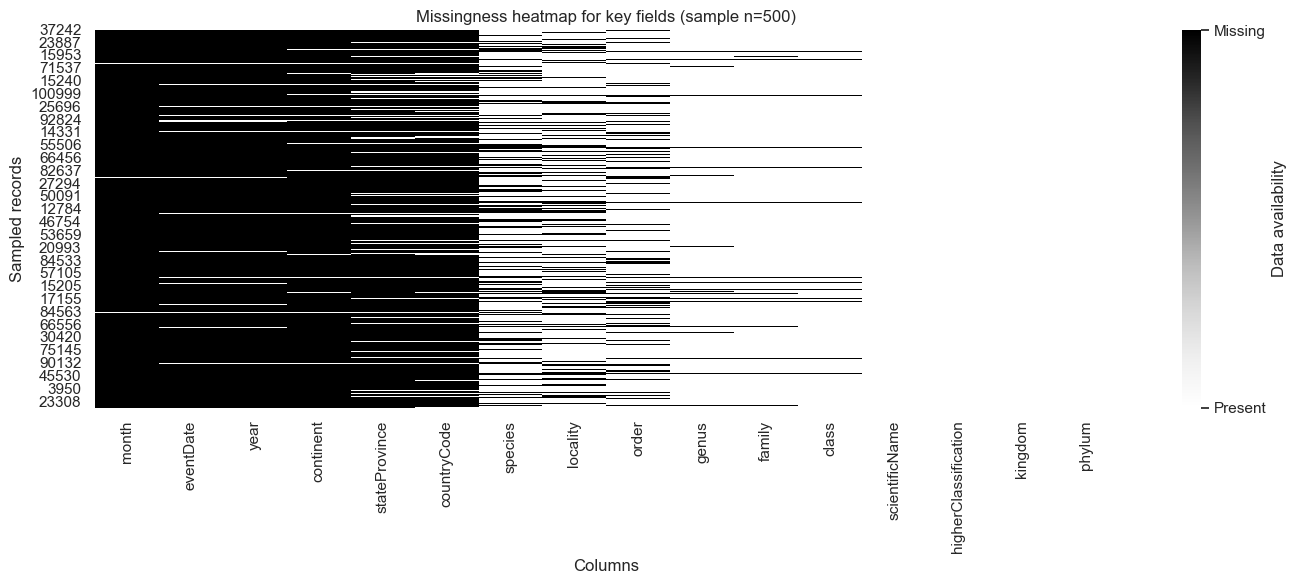

In [797]:
print_header("MISSINGNESS HEATMAP FOR KEY FIELDS")

heatmap_cols = [
    c for c in [
        "scientificName", "higherClassification", 
        "kingdom", "phylum", "class",
        "order", "family", "genus", "species",
        "locality", "countryCode", "stateProvince", "continent",
        "eventDate", "year", "month",
        "formation", "member", "bed",
        "occurrenceRemarks", "fieldNotes"
    ]
    if c in df_mm.columns
]

if heatmap_cols:
    sample_n = min(500, len(df_mm))

    heatmap_df = (
        df_mm[heatmap_cols]
        .sample(sample_n, random_state=random_state)
        .isna()
        .astype(int)
    )

    #sorting columns by missingness
    heatmap_df = heatmap_df[heatmap_df.mean().sort_values(ascending=False).index]

    plt.figure(figsize=(14, 6))

    ax = sns.heatmap(
        heatmap_df,
        cmap="Greys",
        cbar=True
    )

    cbar = ax.collections[0].colorbar
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Present", "Missing"])
    cbar.set_label("Data availability")

    plt.title(f"Missingness heatmap for key fields (sample n={sample_n})")
    plt.xlabel("Columns")
    plt.ylabel("Sampled records")

    plt.tight_layout()
    plt.show()


MAIN MISSINGNESS HEATMAP FOR (MOLLUSC) CONTEXTUAL AND TAXONOMIC FIELDS


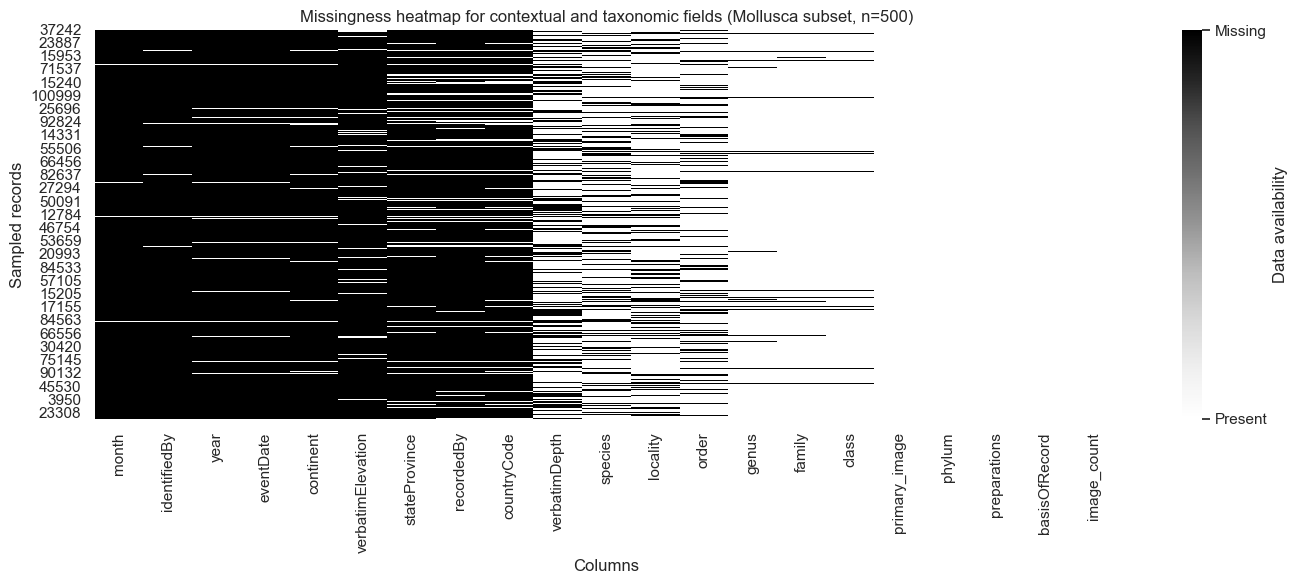

In [798]:
print_header("MAIN MISSINGNESS HEATMAP FOR (MOLLUSC) CONTEXTUAL AND TAXONOMIC FIELDS")

heatmap_cols = [
    c for c in [
        #taxonomy
        "phylum", "class", "order", "family", "genus", "species",

        #contextual metadata
        "locality", "countryCode", "stateProvince", "continent",
        "verbatimDepth", "verbatimElevation",
        "eventDate", "year", "month",

        #specimen metadata
        "basisOfRecord", "preparations", "recordedBy", "identifiedBy",

        #image metadata
        "primary_image", "image_count"
    ]
    if c in df_mm.columns
]

if heatmap_cols:
    sample_n = min(500, len(df_mm))

    heatmap_df = (
        df_mm[heatmap_cols]
        .sample(sample_n, random_state=random_state)
        .isna()
        .astype(int)
    )

    #sorting columns by missingness
    heatmap_df = heatmap_df[heatmap_df.mean().sort_values(ascending=False).index]

    plt.figure(figsize=(14, 6))

    ax = sns.heatmap(
        heatmap_df,
        cmap="Greys",
        cbar=True
    )

    cbar = ax.collections[0].colorbar
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Present", "Missing"])
    cbar.set_label("Data availability")

    plt.title(f"Missingness heatmap for contextual and taxonomic fields (Mollusca subset, n={sample_n})")
    plt.xlabel("Columns")
    plt.ylabel("Sampled records")

    plt.tight_layout()
    plt.show()

# Checking order data leakage

In [799]:
print_header("FAMILIES PER ORDER")

#building crosstab
ctab = pd.crosstab(df_mm["order"], df_mm["family"])

#number of families per order
families_per_order = (ctab > 0).sum(axis=1)

print("Summary:")
display(families_per_order.describe())


FAMILIES PER ORDER
Summary:


count    44.000000
mean      5.386364
std       9.470188
min       1.000000
25%       1.000000
50%       2.000000
75%       4.250000
max      47.000000
dtype: float64

In [800]:
print_header("FAMILIES PER ORDER")

ctab = pd.crosstab(df_mm["order"], df_mm["family"])

families_per_order = (ctab > 0).sum(axis=1)

display(families_per_order.describe())


FAMILIES PER ORDER


count    44.000000
mean      5.386364
std       9.470188
min       1.000000
25%       1.000000
50%       2.000000
75%       4.250000
max      47.000000
dtype: float64

In [801]:
print_header("FAMILIES PER ORDER (TOP COMPLEX ORDERS)")

families_per_order = (pd.crosstab(df_mm["order"], df_mm["family"]) > 0).sum(axis=1)

top_complex = families_per_order.sort_values(ascending=False).head(10)

show_table("Orders with most families", top_complex)


FAMILIES PER ORDER (TOP COMPLEX ORDERS)

--- Orders with most families ---


order
Littorinimorpha    47
Neogastropoda      41
Stylommatophora    21
Cephalaspidea      14
Venerida           13
Trochida           11
Pectinida           7
Cardiida            6
Lepetellida         5
Myida               5
dtype: int64


TOP ORDERS BY FAMILY DIVERSITY


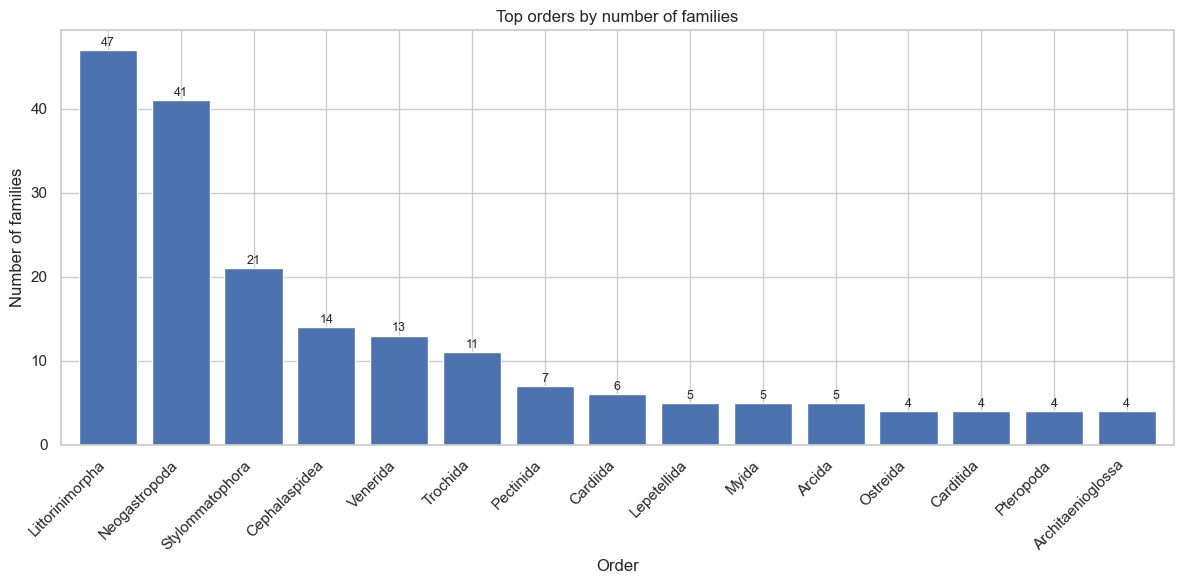

In [802]:
print_header("TOP ORDERS BY FAMILY DIVERSITY")

families_per_order = (
    (pd.crosstab(df_mm["order"], df_mm["family"]) > 0)
    .sum(axis=1)
    .sort_values(ascending=False)
)

top_k = 15
top_orders = families_per_order.head(top_k)

plt.figure(figsize=(12, 6))

ax = top_orders.plot(
    kind="bar",
    color="#4C72B0",   
    width=0.8
)

plt.title("Top orders by number of families")
plt.ylabel("Number of families")
plt.xlabel("Order")
plt.xticks(rotation=45, ha="right")

#adding values on bars 
for i, v in enumerate(top_orders.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

Orders have variable complexities in terms of the number of families, some are particularly challenging with many internal families.

In [803]:
print_header("ORDER DISTRIBUTION")

order_counts = df_mm["order"].value_counts(dropna=False)

display(order_counts)

print("\nSummary:")
display(order_counts.describe())

print("\nTop 10 orders:")
display(order_counts.head(10))


ORDER DISTRIBUTION


order
<NA>                 4330
Neogastropoda        2735
Littorinimorpha      2535
Cardiida             1440
Venerida             1048
Sphaeriida            913
Carditida             850
Galeommatida          835
Stylommatophora       794
Cephalaspidea         778
Myida                 586
Pectinida             548
Lucinida              477
Arcida                458
Trochida              444
Mytilida              393
Nuculida              350
Nuculanida            322
Adapedonta            265
Dentaliida            184
Ostreida              149
Lepidopleurida        118
Limida                117
Chitonida             107
Lepetellida            83
Architaenioglossa      71
Pteropoda              58
Cycloneritida          40
Gadilida               39
Ellobiida              27
Gastrochaenida         26
Cyrtodontida           21
Unionida               19
Seguenziida            12
Solemyida               9
Sepiida                 6
Aplysiida               6
Nautilida               5
Belemn


Summary:


count          45.0
mean     471.311111
std      841.607035
min             1.0
25%            12.0
50%           117.0
75%           548.0
max          4330.0
Name: count, dtype: Float64


Top 10 orders:


order
<NA>               4330
Neogastropoda      2735
Littorinimorpha    2535
Cardiida           1440
Venerida           1048
Sphaeriida          913
Carditida           850
Galeommatida        835
Stylommatophora     794
Cephalaspidea       778
Name: count, dtype: Int64

In [804]:
#summary of target (order) complexity 
print_header("ORDER TARGET COMPLEXITY")

order_counts = df_mm["order"].value_counts(dropna=False)

order_summary = pd.DataFrame({
    "n_records": [len(df_mm)],
    "n_non_missing_order": [df_mm["order"].notna().sum()],
    "n_missing_order": [df_mm["order"].isna().sum()],
    "missing_order_pct": [df_mm["order"].isna().mean() * 100],
    "n_unique_orders": [df_mm["order"].nunique(dropna=True)]
})

show_table("Order target summary", order_summary, n=10)

display(order_counts.describe())
display(order_counts.head(10))


ORDER TARGET COMPLEXITY

--- Order target summary ---


,n_records,n_non_missing_order,n_missing_order,missing_order_pct,n_unique_orders
0,21209,16879,4330,20.415861,44


count          45.0
mean     471.311111
std      841.607035
min             1.0
25%            12.0
50%           117.0
75%           548.0
max          4330.0
Name: count, dtype: Float64

order
<NA>               4330
Neogastropoda      2735
Littorinimorpha    2535
Cardiida           1440
Venerida           1048
Sphaeriida          913
Carditida           850
Galeommatida        835
Stylommatophora     794
Cephalaspidea       778
Name: count, dtype: Int64

In [805]:
#recap of rare orders
print_header("ORDER CLASS FREQUENCY THRESHOLDS")

counts = df_mm["order"].value_counts(dropna=True)

for k in [5, 10, 20, 50]:
    n_classes = (counts >= k).sum()
    n_samples = counts[counts >= k].sum()
    print(f">= {k}: {n_classes} orders, {n_samples} samples")


ORDER CLASS FREQUENCY THRESHOLDS
>= 5: 37 orders, 16868 samples
>= 10: 33 orders, 16842 samples
>= 20: 31 orders, 16811 samples
>= 50: 26 orders, 16658 samples


In [806]:
#appendix
families_per_order.value_counts()

1     18
3      6
2      5
4      4
5      3
47     1
41     1
21     1
14     1
13     1
11     1
7      1
6      1
Name: count, dtype: int64

In [807]:
#appendix
single_family_orders = families_per_order[families_per_order == 1]

print("Number of orders mapping to 1 family:", len(single_family_orders))

Number of orders mapping to 1 family: 18


In [808]:
#appendix
#checking how many samples fall into those orders
order_counts = df_mm["order"].value_counts()

leaky_orders = single_family_orders.index

leaky_samples = order_counts[order_counts.index.isin(leaky_orders)].sum()
total_samples = len(df_mm)

print("Number of cases where order determines family:", leaky_samples)
print("Leakage sample percentage:", leaky_samples / total_samples)

Number of cases where order determines family: 2041
Leakage sample percentage: 0.09623273138761847


In [809]:
#appendix
print_header("ORDER → FAMILY PREDICTIVE STRENGTH")

#majority family per order baseline
order_to_major_family = (
    df_mm.groupby("order")["family"]
    .agg(lambda x: x.value_counts().idxmax())
)

df_tmp = df_mm.copy()
df_tmp["order_pred_family"] = df_tmp["order"].map(order_to_major_family)

valid = df_tmp[["family", "order_pred_family"]].dropna()

accuracy = (valid["order_pred_family"] == valid["family"]).mean()

print(f"Baseline accuracy (predicting family from order only): {accuracy:.2%}")


ORDER → FAMILY PREDICTIVE STRENGTH
Baseline accuracy (predicting family from order only): 48.02%


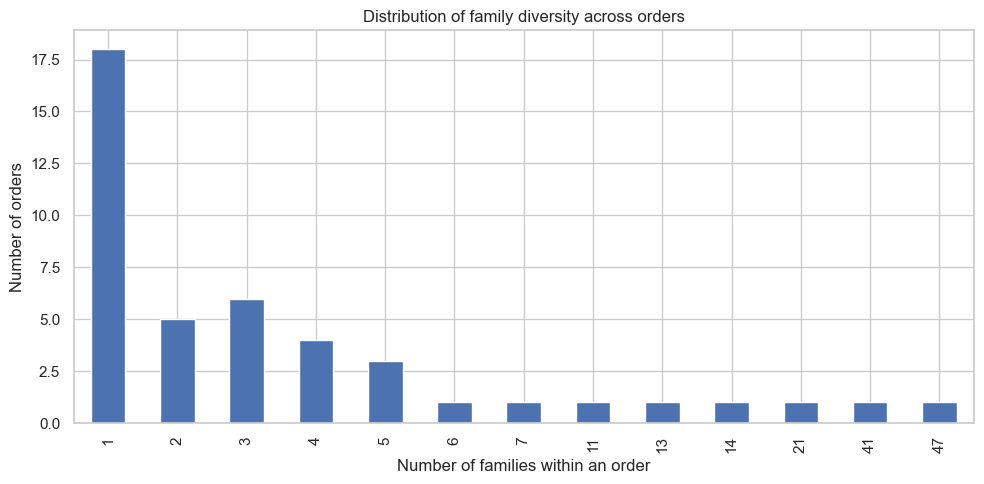

In [810]:
#appendix
families_per_order.value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5),
    color="#4C72B0"
)

plt.xlabel("Number of families within an order")
plt.ylabel("Number of orders")
plt.title("Distribution of family diversity across orders")

plt.tight_layout()
plt.show()

In [811]:
#appendix
import scipy.stats as stats

entropy_per_order = df_mm.groupby("order")["family"].apply(
    lambda x: stats.entropy(x.value_counts(normalize=True))
)

print(entropy_per_order.describe())

count    44.000000
mean      0.659130
std       0.795493
min       0.000000
25%       0.000000
50%       0.487416
75%       0.856109
max       2.979856
Name: family, dtype: float64


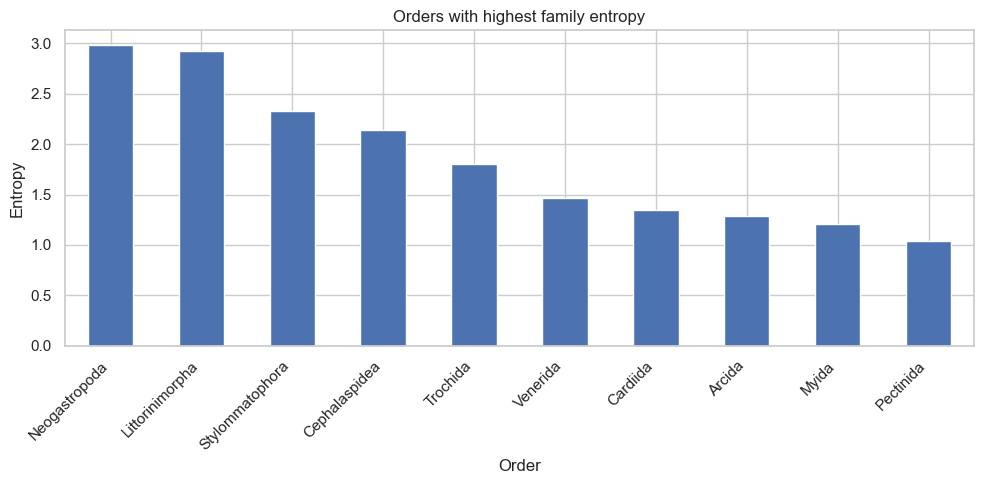

In [812]:
#appendix
entropy_per_order.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10, 5),
    color="#4C72B0"
)

plt.title("Orders with highest family entropy")
plt.ylabel("Entropy")
plt.xlabel("Order")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


SIDE ANALYSIS: IMAGE RICHNESS VS METADATA COMPLETENESS


/opt/anaconda3/envs/aml/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


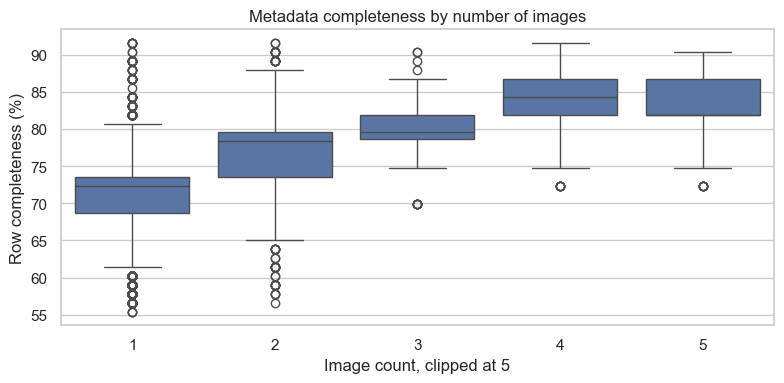

,count,mean,std,min,25%,50%,75%,max
image_count_clipped,,,,,,,,
1,17269.0,71.531060,4.197886,55.421687,68.674699,72.289157,73.493976,91.566265
2,3298.0,76.764669,4.466346,56.626506,73.493976,78.313253,79.518072,91.566265
3,162.0,80.462591,3.756877,69.879518,78.614458,79.518072,81.927711,90.361446
4,229.0,83.900668,3.664243,72.289157,81.927711,84.337349,86.746988,91.566265
5,251.0,83.252532,3.554940,72.289157,81.927711,81.927711,86.746988,90.361446


In [813]:
print_header("SIDE ANALYSIS: IMAGE RICHNESS VS METADATA COMPLETENESS")

subset = df_mm[["image_count", "row_completeness_pct"]].dropna().copy()
subset["image_count_clipped"] = subset["image_count"].clip(upper=5)

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=subset,
    x="image_count_clipped",
    y="row_completeness_pct"
)

plt.title("Metadata completeness by number of images")
plt.xlabel("Image count, clipped at 5")
plt.ylabel("Row completeness (%)")
plt.tight_layout()
plt.show()

display(
    subset.groupby("image_count_clipped")["row_completeness_pct"]
    .describe()
)

Overall, order and family represents a more feasible target as genus is much more fine-grained as a target. However genus is highly meaningful and will be further discussed.

In [814]:
print_header("TARGET FEASIBILITY CHECK: ORDER VS FAMILY")

def target_feasibility_report(df, target):
    subset = df[df[target].notna()].copy()
    vc = subset[target].value_counts()

    if len(vc) == 0:
        return pd.Series(dtype="object")

    return pd.Series({
        "usable_rows": int(len(subset)),
        "n_classes": int(vc.shape[0]),
        "avg_samples_per_class": float(len(subset) / vc.shape[0]),
        "median_samples_per_class": float(vc.median()),
        "top_class_count": int(vc.iloc[0]),
        "top_class_pct": float(vc.iloc[0] / len(subset) * 100),
        "singleton_classes": int((vc == 1).sum()),
        "singleton_class_pct": float((vc == 1).mean() * 100),
        "missing_count": int(df[target].isna().sum()),
        "missing_pct": float(df[target].isna().mean() * 100)
    })

target_reports = {}

for target in [c for c in ["order", "family", "genus"] if c in df_mm.columns]:
    target_reports[target] = target_feasibility_report(df_mm, target)

target_feasibility_df = pd.DataFrame(target_reports).T
show_table("Target feasibility: order vs family vs genus", target_feasibility_df, n=10)


TARGET FEASIBILITY CHECK: ORDER VS FAMILY

--- Target feasibility: order vs family vs genus ---


,usable_rows,n_classes,avg_samples_per_class,median_samples_per_class,top_class_count,top_class_pct,singleton_classes,singleton_class_pct,missing_count,missing_pct
order,16879.0,44.0,383.613636,112.0,2735.0,16.203567,5.0,11.363636,4330.0,20.415861
family,20409.0,288.0,70.864583,20.0,1227.0,6.012054,30.0,10.416667,800.0,3.771984
genus,20219.0,1074.0,18.825885,5.0,474.0,2.344330,251.0,23.370577,990.0,4.667830


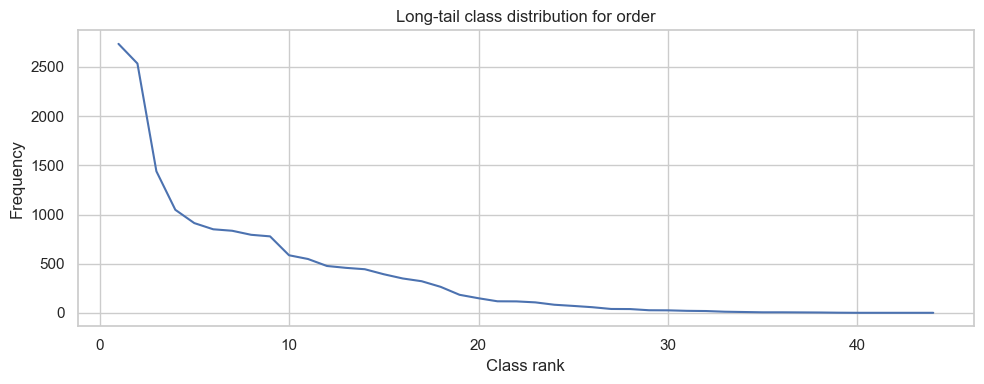

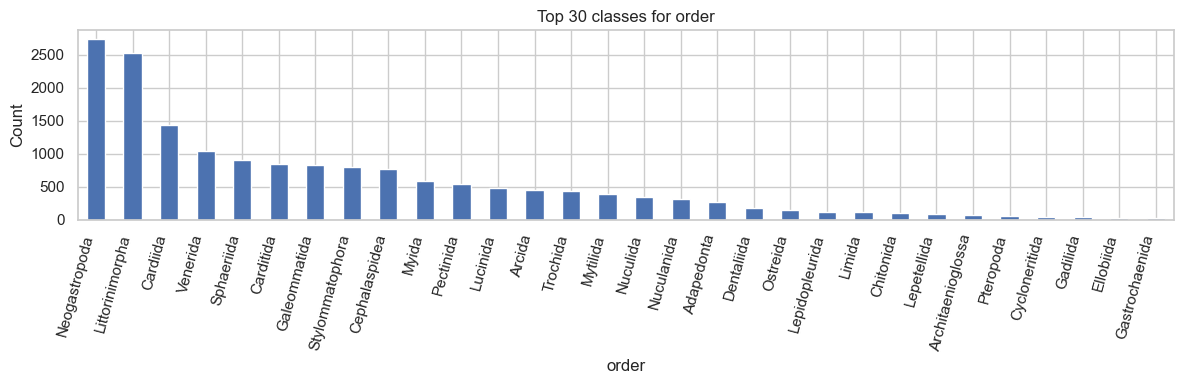

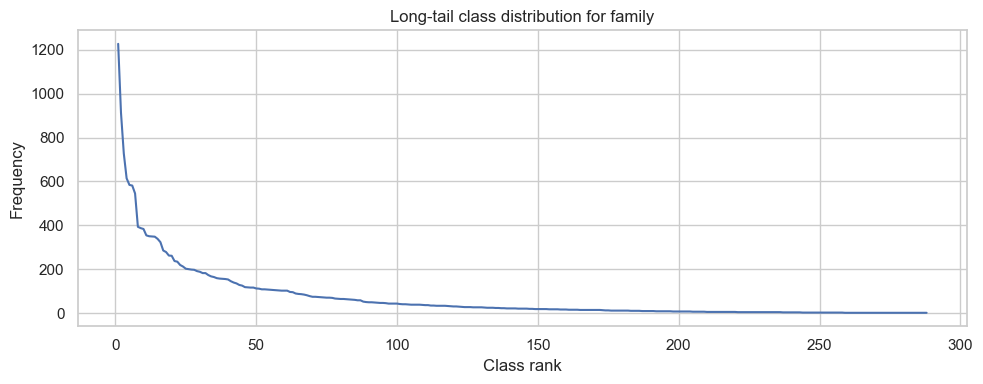

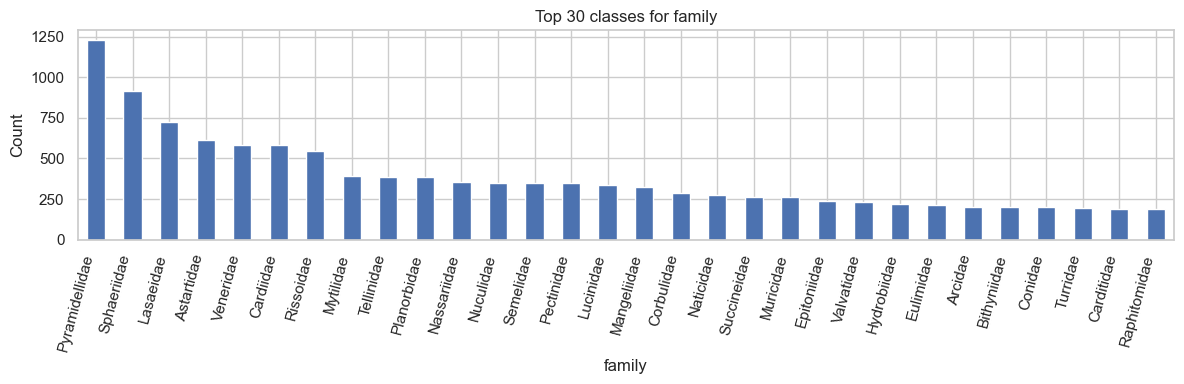

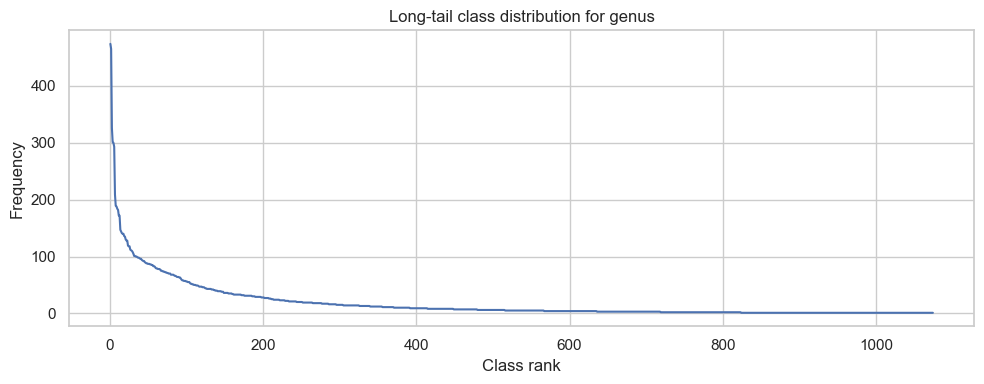

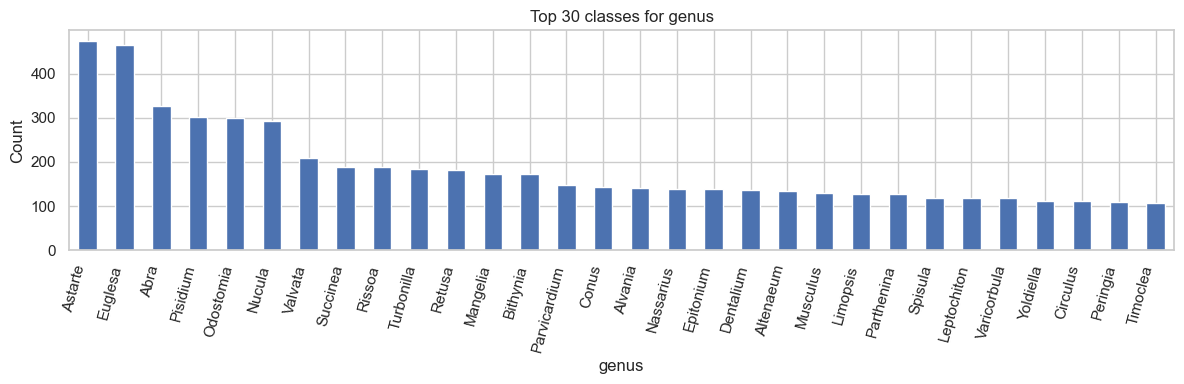

In [815]:
for target in [c for c in ["order", "family", "genus"] if c in df_mm.columns]:
    vc = df_mm[target].dropna().value_counts()

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(vc) + 1), vc.values)
    plt.title(f"Long-tail class distribution for {target}")
    plt.xlabel("Class rank")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    vc.head(30).plot(kind="bar")
    plt.title(f"Top 30 classes for {target}")
    plt.ylabel("Count")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

Looking at the results, family represents a more feasible target as genus is much more fine-grained as a target. However genus is highly meaningful and will be further discussed.

# Creating Final Modelling Sets

In [816]:
#dataset recap
df_mm

,gbifID,license,modified,publisher,rightsHolder,institutionID,collectionCode,basisOfRecord,occurrenceID,catalogNumber,recordNumber,recordedBy,individualCount,occurrenceStatus,preparations,eventDate,startDayOfYear,endDayOfYear,year,month,day,verbatimEventDate,continent,island,countryCode,stateProvince,locality,verbatimElevation,verbatimDepth,typeStatus,identifiedBy,dateIdentified,acceptedNameUsageID,scientificName,higherClassification,kingdom,phylum,class,order,family,genus,genericName,specificEpithet,infraspecificEpithet,taxonRank,nomenclaturalCode,taxonomicStatus,datasetKey,publishingCountry,lastInterpreted,issue,nonTaxonomicIssue,mediaType,hasCoordinate,hasGeospatialIssues,taxonKey,acceptedTaxonKey,kingdomKey,phylumKey,classKey,orderKey,familyKey,genusKey,speciesKey,species,acceptedScientificName,verbatimScientificName,protocol,lastParsed,lastCrawled,repatriated,isSequenced,gbifRegion,publishedByGbifRegion,iucnRedListCategory,completeness_pct,completeness_relevant_pct,image_urls,primary_image,image_count,image_formats,image_types,has_image,row_completeness_pct,taxonomy_depth,has_family,has_order
1,2443030028,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.936850,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Eindhoven,<NA>,2.60-2.90 m.o.m.,<NA>,<NA>,<NA>,8182127,"Pisidium milium Held, 1836",Animalia,Animalia,Mollusca,Bivalvia,Sphaeriida,Sphaeriidae,Euglesa,Pisidium,milium,<NA>,SPECIES,ICZN,SYNONYM,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.650Z,COLLECTION_MATCH_NONE;TAXON_MATCH_FUZZY,COLLECTION_MATCH_NONE,StillImage,False,False,10914468,8182127,1,52.0,137.0,10495862.0,3247675.0,7641355.0,8182127.0,Euglesa milium,"Euglesa milium (Held, 1836)",Pisidium millium Held,DWC_ARCHIVE,2026-03-12T16:40:59.650Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,23.043478,100.000000,[https://medialib.naturalis.nl/file/id/RGM.936...,https://medialib.naturalis.nl/file/id/RGM.9368...,1,[image/jpeg],[StillImage],True,73.493976,7,True,True
6,2443031665,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.937964,<NA>,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,109.00-110.00 m.,<NA>,<NA>,<NA>,6493055,"Natica multipunctata Blainville, 1825",Animalia,Animalia,Mollusca,Gastropoda,Littorinimorpha,Naticidae,Natica,Natica,multipunctata,<NA>,SPECIES,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.666Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,6493055,6493055,1,52.0,225.0,7390893.0,7072.0,7693044.0,6493055.0,Natica multipunctata,"Natica multipunctata Blainville, 1825",Natica multipunctata Wood,DWC_ARCHIVE,2026-03-12T16:40:59.666Z,2026-03-12T16:38:46.918Z,<NA>,False,<NA>,EUROPE,<NA>,22.608696,100.000000,[https://medialib.naturalis.nl/file/id/RGM.937...,https://medialib.naturalis.nl/file/id/RGM.9379...,1,[image/jpeg],[StillImage],True,72.289157,7,True,True
10,2443026198,CC0_1_0,2017-06-29T00:00:00Z,Naturalis Biodiversity Center,Naturalis Biodiversity Center,https://ror.org/0566bfb96,Cainozoic Mollusca,FOSSIL_SPECIMEN,https://data.biodiversitydata.nl/naturalis/spe...,RGM.931824,81H62,<NA>,NaN,PRESENT,shell (fossilized),<NA>,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Noordzee,<NA>,0.15-0.25 m.o.zb.,<NA>,<NA>,<NA>,2305881,"Acanthochitona Gray, 1821",Animalia,Animalia,Mollusca,Polyplacophora,Chitonida,Acanthochitonidae,Acanthochitona,<NA>,<NA>,<NA>,GENUS,ICZN,ACCEPTED,a57e6526-54c6-465a-baa9-904979bbc93f,NL,2026-03-12T16:40:59.734Z,COLLECTION_MATCH_NONE,COLLECTION_MATCH_NONE,StillImage,False,False,2305881,2305881,1,52.0,346.0,8278247.0,9103.0,2305881.0,NaN,<NA>,"Acanthochitona Gray, 1821",Aca

In [817]:
print("Total rows:", len(df_mm))
print("Rows with order:", df_mm["order"].notna().sum())
print("Rows without order:", df_mm["order"].isna().sum())
print("Unique non-missing orders:", df_mm["order"].nunique(dropna=True))

Total rows: 21209
Rows with order: 16879
Rows without order: 4330
Unique non-missing orders: 44


# Analysis section to help with dataset creation

In [818]:
#taxonomic order leakage check
#quantifying whether taxonomy fields directly reveal order, important for the three metadata conditions

print_header("TAXONOMIC ORDER-DETERMINISM AUDIT")

order_audit_cols = [
    "orderKey",
    "family",
    "genus",
    "genericName",
    "species",
    "scientificName",
    "acceptedScientificName",
    "verbatimScientificName",
    "higherClassification",
    "specificEpithet",
    "infraspecificEpithet",
    "acceptedNameUsageID",
    "taxonKey",
    "acceptedTaxonKey",
    "familyKey",
    "genusKey",
    "speciesKey",
    "classKey",
    "phylumKey",
    "kingdomKey",
    "taxonRank",
    "taxonomicStatus",
    "nomenclaturalCode",
]

order_audit_cols = [c for c in order_audit_cols if c in df_mm.columns]

df_order_audit = df_mm[
    df_mm[target_col].notna()
    & df_mm["primary_image"].notna()
].copy()

df_order_audit[target_col] = (
    df_order_audit[target_col]
    .astype("string")
    .str.strip()
)

print(f"Audit rows with labelled order and image: {len(df_order_audit)}")
print(f"Unique orders in audit subset: {df_order_audit[target_col].nunique()}")

audit_rows = []

for col in order_audit_cols:
    valid = df_order_audit[[target_col, col]].dropna().copy()

    if valid.empty:
        continue

    valid["_target_norm"] = (
        valid[target_col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    valid["_value_norm"] = (
        valid[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    exact_match_mask = valid["_target_norm"] == valid["_value_norm"]

    substring_mask = valid.apply(
        lambda r: str(r["_target_norm"]) in str(r["_value_norm"]),
        axis=1,
    )

    orders_per_value = valid.groupby("_value_norm")["_target_norm"].nunique()
    group_sizes = valid.groupby("_value_norm").size()
    one_order_values = orders_per_value == 1

    audit_rows.append({
        "field": col,
        "n_valid_rows": len(valid),
        "n_unique_values": int(valid["_value_norm"].nunique()),
        "exact_match_pct": float(exact_match_mask.mean() * 100),
        "substring_match_pct": float(substring_mask.mean() * 100),
        "mean_orders_per_value": float(orders_per_value.mean()),
        "max_orders_per_value": int(orders_per_value.max()),
        "pct_values_mapping_to_one_order": float(one_order_values.mean() * 100),
        "pct_rows_mapping_to_one_order": float(
            group_sizes[one_order_values].sum() / len(valid) * 100
        ),
        "example_substring_label": (
            valid.loc[substring_mask, target_col].iloc[0]
            if substring_mask.any()
            else None
        ),
        "example_substring_value": (
            valid.loc[substring_mask, col].astype(str).iloc[0]
            if substring_mask.any()
            else None
        ),
    })

order_determinism_audit_df = (
    pd.DataFrame(audit_rows)
    .sort_values(
        ["pct_rows_mapping_to_one_order", "substring_match_pct"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

show_table(
    "Taxonomic order-determinism audit",
    order_determinism_audit_df,
    n=50,
)

order_determinism_audit_df.to_csv(
    logs / "order_determinism_audit.csv",
    index=False,
)

print("Saved order determinism analysis.")


TAXONOMIC ORDER-DETERMINISM AUDIT
Audit rows with labelled order and image: 16879
Unique orders in audit subset: 44

--- Taxonomic order-determinism audit ---


,field,n_valid_rows,n_unique_values,exact_match_pct,substring_match_pct,mean_orders_per_value,max_orders_per_value,pct_values_mapping_to_one_order,pct_rows_mapping_to_one_order,example_substring_label,example_substring_value
0,family,16817,237,0.000000,29.696141,1.000000,1,100.000000,100.000000,Sphaeriida,Sphaeriidae
1,scientificName,16879,2635,0.284377,0.562830,1.000000,1,100.000000,100.000000,Neogastropoda,Neogastropoda
2,acceptedScientificName,16879,2334,0.284377,0.562830,1.000000,1,100.000000,100.000000,Neogastropoda,Neogastropoda
3,verbatimScientificName,16879,5425,0.000000,0.201434,1.000000,1,100.000000,100.000000,Lucinida,Lucinida (Phacoides)
4,orderKey,16879,44,0.000000,0.000000,1.000000,1,100.000000,100.000000,None,None
5,genus,16610,888,0.000000,0.000000,1.000000,1,100.000000,100.000000,None,None
6,species,12416,1842,0.000000,0.000000,1.000000,1,100.000000,100.000000,None,None
7,infraspecificEpithet,208,34,0.000000,0.000000,1.000000,1,100.000000,100.000000,None,None
8,acceptedNameUsageID,16879,2334,0.000000,0.000000,1.000000,1,100.000000,100.000000,None,None
9,taxonKey,16879,2635,0.000000,0.000000,1.000000,1,100.000000,100.000000,None,None


Saved order determinism analysis.



ORDER CO-MISSINGNESS ANALYSIS
Matrix shape: (21209, 16)


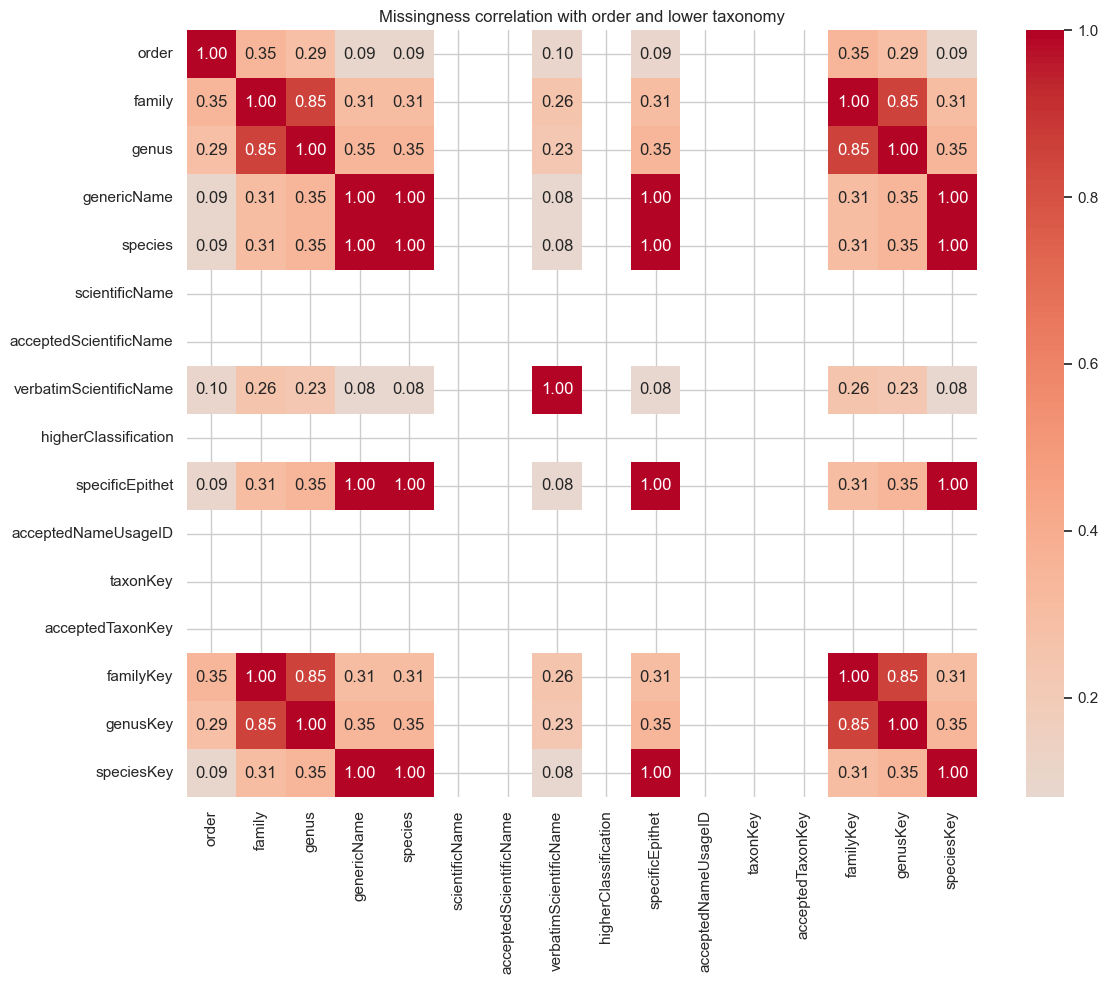

In [819]:
print_header("ORDER CO-MISSINGNESS ANALYSIS")

order_related_cols = [
    "order",
    "family",
    "genus",
    "genericName",
    "species",
    "scientificName",
    "acceptedScientificName",
    "verbatimScientificName",
    "higherClassification",
    "specificEpithet",
    "acceptedNameUsageID",
    "taxonKey",
    "acceptedTaxonKey",
    "familyKey",
    "genusKey",
    "speciesKey",
]

order_related_cols = [c for c in order_related_cols if c in df_mm.columns]

missing_matrix = df_mm[order_related_cols].isna().astype(int)

print("Matrix shape:", missing_matrix.shape)

missing_corr = missing_matrix.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    missing_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Missingness correlation with order and lower taxonomy")
plt.tight_layout()
plt.show()

In [820]:
print_header("CONDITIONAL MISSINGNESS GIVEN ORDER IS MISSING")

results = []

order_missing = df_mm["order"].isna()

for col in order_related_cols:
    if col == "order":
        continue

    p_col_missing_given_order_missing = (
        df_mm.loc[order_missing, col].isna().mean()
    )

    p_col_present_given_order_missing = (
        df_mm.loc[order_missing, col].notna().mean()
    )

    results.append({
        "field": col,
        "P(field missing | order missing)": p_col_missing_given_order_missing,
        "P(field present | order missing)": p_col_present_given_order_missing,
    })

order_conditional_df = (
    pd.DataFrame(results)
    .sort_values("P(field present | order missing)", ascending=False)
    .reset_index(drop=True)
)

show_table(
    "Conditional lower-taxonomy availability when order is missing",
    order_conditional_df,
    n=30,
)


CONDITIONAL MISSINGNESS GIVEN ORDER IS MISSING

--- Conditional lower-taxonomy availability when order is missing ---


,field,P(field missing | order missing),P(field present | order missing)
0,scientificName,0.000000,1.000000
1,acceptedScientificName,0.000000,1.000000
2,higherClassification,0.000000,1.000000
3,acceptedNameUsageID,0.000000,1.000000
4,taxonKey,0.000000,1.000000
5,acceptedTaxonKey,0.000000,1.000000
6,verbatimScientificName,0.012702,0.987298
7,genus,0.166513,0.833487
8,genusKey,0.166513,0.833487
9,family,0.170439,0.829561


# Creating Model Datasets

Final Dataset Creation

In [821]:
print_header("CONFIGURATION FINAL ORDER DATASET")

target_col = "order"
random_state = 42
low_coverage_threshold = 0.01

very_rare_threshold = 5
rare_threshold = 10
medium_threshold = 100

model_dataset_path = datasets_path / "final_model_dataset"


CONFIGURATION FINAL ORDER DATASET


In [822]:
print_header("PREPARING OUTPUTS PATH")

#cleaning old output files in case of reruns
if model_dataset_path.exists():
    shutil.rmtree(model_dataset_path)

model_dataset_path.mkdir(parents=True, exist_ok=True)


PREPARING OUTPUTS PATH


In [823]:
print_header("CREATING BASE MODELLING DATAFRAME")

df_model = df_mm[
    df_mm[target_col].notna()
    & df_mm["primary_image"].notna()
].copy()

df_model[target_col] = df_model[target_col].astype(str).str.strip()
df_model["label"] = df_model[target_col]
df_model["image"] = df_model["primary_image"]

print("Rows in base modelling dataframe:", len(df_model))
print("Unique order labels:", df_model["label"].nunique())


CREATING BASE MODELLING DATAFRAME
Rows in base modelling dataframe: 16879
Unique order labels: 44


In [824]:
print_header("PREPARING CANDIDATE METADATA CONDITIONS")

context_metadata_cols_raw = [
    "basisOfRecord",
    "occurrenceStatus",
    "preparations",
    "typeStatus",
    "recordedBy",
    "identifiedBy",
    "dateIdentified",
    "eventDate",
    "verbatimEventDate",
    "year",
    "month",
    "locality",
    "verbatimDepth",
    "verbatimElevation",
    "countryCode",
    "stateProvince",
    "continent",
    "island",
    "gbifRegion",
    "issue",
    "nonTaxonomicIssue",
    "hasCoordinate",
    "hasGeospatialIssues",
    "protocol",
    "iucnRedListCategory",
]

higher_taxonomy_cols_raw = [
    "kingdom",
    "phylum",
    "class",
    "taxonRank",
    "nomenclaturalCode",
    "taxonomicStatus",
]

lower_taxonomy_cols_raw = [
    "family",
    "genus",
    "species",
    "genericName",
    "specificEpithet",
    "infraspecificEpithet",
]

direct_identifier_cols_raw = [
    "scientificName",
    "acceptedScientificName",
    "verbatimScientificName",
    "higherClassification",
    "acceptedNameUsageID",
    "taxonKey",
    "acceptedTaxonKey",
    "familyKey",
    "genusKey",
    "speciesKey",
    "classKey",
    "phylumKey",
    "kingdomKey",
]

direct_target_cols = [
    target_col,
    "orderKey",
]

full_record_realistic_cols_raw = (
    context_metadata_cols_raw
    + higher_taxonomy_cols_raw
    + lower_taxonomy_cols_raw
    + direct_identifier_cols_raw
)

lower_taxonomy_realistic_cols_raw = (
    context_metadata_cols_raw
    + higher_taxonomy_cols_raw
    + lower_taxonomy_cols_raw
)

strict_conservative_cols_raw = (
    context_metadata_cols_raw
    + higher_taxonomy_cols_raw
)

def clean_metadata_cols(cols, df, forbidden_cols):
    return [
        c for c in dict.fromkeys(cols)
        if c in df.columns and c not in forbidden_cols
    ]

full_record_candidate_cols = clean_metadata_cols(
    full_record_realistic_cols_raw,
    df_model,
    forbidden_cols=set(direct_target_cols),
)

lower_taxonomy_candidate_cols = clean_metadata_cols(
    lower_taxonomy_realistic_cols_raw,
    df_model,
    forbidden_cols=set(direct_target_cols + direct_identifier_cols_raw),
)

strict_candidate_cols = clean_metadata_cols(
    strict_conservative_cols_raw,
    df_model,
    forbidden_cols=set(
        direct_target_cols
        + direct_identifier_cols_raw
        + lower_taxonomy_cols_raw
    ),
)

metadata_candidate_sets = {
    "full_record_realistic": full_record_candidate_cols,
    "lower_taxonomy_realistic": lower_taxonomy_candidate_cols,
    "strict_conservative": strict_candidate_cols,
}

for name, cols in metadata_candidate_sets.items():
    assert target_col not in cols, f"{target_col} found in {name}."
    assert "orderKey" not in cols, f"orderKey found in {name}."

    print(f"{name}: {len(cols)} candidate columns")
    print(cols)
    print()


PREPARING CANDIDATE METADATA CONDITIONS
full_record_realistic: 50 candidate columns
['basisOfRecord', 'occurrenceStatus', 'preparations', 'typeStatus', 'recordedBy', 'identifiedBy', 'dateIdentified', 'eventDate', 'verbatimEventDate', 'year', 'month', 'locality', 'verbatimDepth', 'verbatimElevation', 'countryCode', 'stateProvince', 'continent', 'island', 'gbifRegion', 'issue', 'nonTaxonomicIssue', 'hasCoordinate', 'hasGeospatialIssues', 'protocol', 'iucnRedListCategory', 'kingdom', 'phylum', 'class', 'taxonRank', 'nomenclaturalCode', 'taxonomicStatus', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'infraspecificEpithet', 'scientificName', 'acceptedScientificName', 'verbatimScientificName', 'higherClassification', 'acceptedNameUsageID', 'taxonKey', 'acceptedTaxonKey', 'familyKey', 'genusKey', 'speciesKey', 'classKey', 'phylumKey', 'kingdomKey']

lower_taxonomy_realistic: 37 candidate columns
['basisOfRecord', 'occurrenceStatus', 'preparations', 'typeStatus', 'recordedB

In [825]:
#metadata design decision documentation

print_header("METADATA CONDITION DESIGN RATIONALE")

metadata_group_rationale = pd.DataFrame([
    {
        "group": "context_metadata",
        "description": (
            "Non-taxonomic occurrence, specimen, temporal, geographic, "
            "record-quality, and source/context fields."
        ),
        "role": (
            "Allowed in all conditions because these fields may realistically "
            "be available when order is missing."
        ),
    },
    {
        "group": "higher_taxonomy",
        "description": (
            "Taxonomic ranks above the target order, plus taxonomic status/rank metadata."
        ),
        "role": (
            "Allowed in all conditions because the task is order completion; "
            "higher taxonomy does not directly provide the target rank."
        ),
    },
    {
        "group": "lower_taxonomy",
        "description": (
            "Taxonomic ranks below order, such as family, genus, species, "
            "genericName, and epithet fields."
        ),
        "role": (
            "Allowed only in realistic metadata conditions. These fields can be "
            "highly informative for order, but reflect realistic semi-complete records."
        ),
    },
    {
        "group": "direct_identifiers",
        "description": (
            "Scientific names, accepted names, higherClassification strings, "
            "and GBIF taxon key identifiers."
        ),
        "role": (
            "Included only in the full-record realistic upper-bound condition. "
            "Excluded from lower-taxonomy and strict conditions because they may encode "
            "direct or near-direct taxonomic evidence."
        ),
    },
    {
        "group": "direct_target",
        "description": "The target field order and direct order identifier orderKey.",
        "role": "Removed from all modelling conditions.",
    },
])

show_table(
    "Metadata grouping rationale",
    metadata_group_rationale,
    n=10,
)


METADATA CONDITION DESIGN RATIONALE

--- Metadata grouping rationale ---


,group,description,role
0,context_metadata,"Non-taxonomic occurrence, specimen, temporal, ...",Allowed in all conditions because these fields...
1,higher_taxonomy,"Taxonomic ranks above the target order, plus t...",Allowed in all conditions because the task is ...
2,lower_taxonomy,"Taxonomic ranks below order, such as family, g...",Allowed only in realistic metadata conditions....
3,direct_identifiers,"Scientific names, accepted names, higherClassi...",Included only in the full-record realistic upp...
4,direct_target,The target field order and direct order identi...,Removed from all modelling conditions.


In [826]:
print_header("FINAL METADATA COLUMN SELECTION")

def select_metadata_columns(candidate_cols, df, threshold):
    available_cols = [c for c in candidate_cols if c in df.columns]

    if not available_cols:
        return [], [], pd.Series(dtype="float64")

    coverage = df[available_cols].notna().mean().sort_values()
    low_coverage_cols = coverage[coverage < threshold].index.tolist()

    selected_cols = [
        c for c in available_cols
        if c not in low_coverage_cols
    ]

    return selected_cols, low_coverage_cols, coverage


final_metadata_sets = {}
low_coverage_by_set = {}
coverage_by_set = {}

for name, candidate_cols in metadata_candidate_sets.items():
    selected_cols, low_coverage_cols, coverage = select_metadata_columns(
        candidate_cols,
        df_model,
        low_coverage_threshold,
    )

    final_metadata_sets[name] = selected_cols
    low_coverage_by_set[name] = low_coverage_cols
    coverage_by_set[name] = coverage

    print(f"\n{name}: {len(selected_cols)} final columns")
    print("Low-coverage removed:", low_coverage_cols)
    print(selected_cols)

    assert selected_cols, f"No metadata columns selected for {name}."
    assert target_col not in selected_cols, f"{target_col} found in {name}."
    assert "orderKey" not in selected_cols, f"orderKey found in {name}."


#summary for thesis 
coverage_summary = []

for name, coverage in coverage_by_set.items():
    for col, cov in coverage.items():
        coverage_summary.append({
            "metadata_condition": name,
            "column": col,
            "coverage": cov,
            "selected": col in final_metadata_sets[name],
            "low_coverage_removed": col in low_coverage_by_set[name],
        })

coverage_summary_df = pd.DataFrame(coverage_summary)

show_table(
    "Metadata column coverage summary",
    coverage_summary_df.sort_values(
        ["metadata_condition", "selected", "coverage"],
        ascending=[True, False, True],
    ),
    n=50,
)


FINAL METADATA COLUMN SELECTION

full_record_realistic: 49 final columns
Low-coverage removed: ['month']
['basisOfRecord', 'occurrenceStatus', 'preparations', 'typeStatus', 'recordedBy', 'identifiedBy', 'dateIdentified', 'eventDate', 'verbatimEventDate', 'year', 'locality', 'verbatimDepth', 'verbatimElevation', 'countryCode', 'stateProvince', 'continent', 'island', 'gbifRegion', 'issue', 'nonTaxonomicIssue', 'hasCoordinate', 'hasGeospatialIssues', 'protocol', 'iucnRedListCategory', 'kingdom', 'phylum', 'class', 'taxonRank', 'nomenclaturalCode', 'taxonomicStatus', 'family', 'genus', 'species', 'genericName', 'specificEpithet', 'infraspecificEpithet', 'scientificName', 'acceptedScientificName', 'verbatimScientificName', 'higherClassification', 'acceptedNameUsageID', 'taxonKey', 'acceptedTaxonKey', 'familyKey', 'genusKey', 'speciesKey', 'classKey', 'phylumKey', 'kingdomKey']

lower_taxonomy_realistic: 36 final columns
Low-coverage removed: ['month']
['basisOfRecord', 'occurrenceStatus', 

,metadata_condition,column,coverage,selected,low_coverage_removed
1,full_record_realistic,infraspecificEpithet,0.012323,True,False
2,full_record_realistic,dateIdentified,0.017951,True,False
3,full_record_realistic,identifiedBy,0.024054,True,False
4,full_record_realistic,iucnRedListCategory,0.035251,True,False
5,full_record_realistic,year,0.042005,True,False
6,full_record_realistic,eventDate,0.044612,True,False
7,full_record_realistic,continent,0.048403,True,False
8,full_record_realistic,verbatimEventDate,0.048937,True,False
9,full_record_realistic,island,0.053972,True,False
10,full_record_realistic,verbatimElevation,0.081047,True,False


In [827]:
print_header("BUILDING TEXT METADATA REPRESENTATIONS")

max_chars_by_col = {
    "issue": 120,
    "nonTaxonomicIssue": 120,
    "locality": 120,
    "preparations": 80,
    "recordedBy": 80,
    "identifiedBy": 80,
    "higherClassification": 220,
    "verbatimScientificName": 160,
    "scientificName": 160,
    "acceptedScientificName": 160,
}

def clean_value_for_prompt(val, max_chars=None):
    if pd.isna(val):
        return None

    if isinstance(val, (list, tuple, set)):
        val = ", ".join(map(str, val))
    elif isinstance(val, dict):
        val = ", ".join(f"{k}: {v}" for k, v in val.items())

    val = str(val).strip()

    if val in {"", "<NA>", "nan", "NaN", "None", "none", "NULL", "null"}:
        return None

    val = val.replace("\n", " ")
    val = " ".join(val.split())

    if max_chars is not None and len(val) > max_chars:
        val = val[:max_chars].rstrip() + "..."

    return val


def build_metadata_input(row, cols):
    parts = []

    for c in cols:
        val = clean_value_for_prompt(
            row.get(c, pd.NA),
            max_chars=max_chars_by_col.get(c),
        )

        if val is not None:
            parts.append(f"{c}={val}")

    return "; ".join(parts)


for name, cols in final_metadata_sets.items():
    metadata_col = f"metadata_{name}"

    df_model[metadata_col] = df_model.apply(
        lambda r: build_metadata_input(r, cols),
        axis=1,
    )

    non_empty = (df_model[metadata_col].str.len() > 0).sum()
    avg_len = df_model[metadata_col].str.len().mean()

    print(f"\n{name}")
    print(f"  columns used: {len(cols)}")
    print(f"  rows with metadata: {non_empty:,}/{len(df_model):,}")
    print(f"  average prompt length: {avg_len:.1f} chars")
    print(f"  sample: {df_model[metadata_col].iloc[0][:250]}...")


BUILDING TEXT METADATA REPRESENTATIONS



full_record_realistic
  columns used: 49
  rows with metadata: 16,879/16,879
  average prompt length: 865.4 chars
  sample: basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatus=PRESENT; preparations=shell (fossilized); locality=Eindhoven; verbatimDepth=2.60-2.90 m.o.m.; issue=COLLECTION_MATCH_NONE;TAXON_MATCH_FUZZY; nonTaxonomicIssue=COLLECTION_MATCH_NONE; hasCoordinate=False;...

lower_taxonomy_realistic
  columns used: 36
  rows with metadata: 16,879/16,879
  average prompt length: 507.5 chars
  sample: basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatus=PRESENT; preparations=shell (fossilized); locality=Eindhoven; verbatimDepth=2.60-2.90 m.o.m.; issue=COLLECTION_MATCH_NONE;TAXON_MATCH_FUZZY; nonTaxonomicIssue=COLLECTION_MATCH_NONE; hasCoordinate=False;...

strict_conservative
  columns used: 30
  rows with metadata: 16,879/16,879
  average prompt length: 416.5 chars
  sample: basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatus=PRESENT; preparations=shell (fossilized); locality=Eindhoven; verbat

In [828]:
#direct target order leakage check on final metadata sets
#full_record_realistic may contain direct evidence by design (raw metadata)
#lower_taxonomy_realistic may contain lower-taxonomy evidence but should avoid direct identifiers (order-cleaned metadata)
#strict_conservative should avoid direct target-string evidence (taxonomically reduced metadata)


print_header("DIRECT TARGET STRING LEAKAGE CHECK")

def count_column_label_string_leaks(df, cols, label_col):
    leakage_rows = []

    for col in cols:
        if col not in df.columns:
            continue

        valid = df[[col, label_col]].dropna().copy()

        if valid.empty:
            continue

        leak_mask = valid.apply(
            lambda r: str(r[label_col]).strip().lower()
            in str(r[col]).strip().lower(),
            axis=1,
        )

        n_leaks = int(leak_mask.sum())

        if n_leaks > 0:
            leakage_rows.append({
                "column": col,
                "n_non_null": len(valid),
                "n_label_string_matches": n_leaks,
                "pct_valid_rows_matching": float(n_leaks / len(valid) * 100),
                "pct_all_rows_matching": float(n_leaks / len(df) * 100),
                "example_label": valid.loc[leak_mask, label_col].iloc[0],
                "example_value": valid.loc[leak_mask, col].astype(str).iloc[0],
            })

    if not leakage_rows:
        return pd.DataFrame(columns=[
            "column",
            "n_non_null",
            "n_label_string_matches",
            "pct_valid_rows_matching",
            "pct_all_rows_matching",
            "example_label",
            "example_value",
        ])

    return (
        pd.DataFrame(leakage_rows)
        .sort_values("n_label_string_matches", ascending=False)
        .reset_index(drop=True)
    )


metadata_leakage_checks = {}

for set_name, cols in final_metadata_sets.items():
    leak_df = count_column_label_string_leaks(
        df_model,
        cols,
        label_col="label",
    )

    metadata_leakage_checks[set_name] = leak_df

    show_table(
        f"Direct order-string matches in final metadata: {set_name}",
        leak_df,
        n=50,
    )


direct_label_string_cols_by_set = {
    set_name: (
        sorted(leak_df["column"].tolist())
        if not leak_df.empty
        else []
    )
    for set_name, leak_df in metadata_leakage_checks.items()
}

print("\nDirect order-string columns by condition:")
for set_name, cols in direct_label_string_cols_by_set.items():
    print(f"{set_name}: {cols}")

assert direct_label_string_cols_by_set.get("strict_conservative", []) == [], (
    "Direct target-string evidence found in strict_conservative metadata columns."
)


DIRECT TARGET STRING LEAKAGE CHECK

--- Direct order-string matches in final metadata: full_record_realistic ---


,column,n_non_null,n_label_string_matches,pct_valid_rows_matching,pct_all_rows_matching,example_label,example_value
0,family,16817,4994,29.696141,29.587061,Sphaeriida,Sphaeriidae
1,scientificName,16879,95,0.562830,0.562830,Neogastropoda,Neogastropoda
2,acceptedScientificName,16879,95,0.562830,0.562830,Neogastropoda,Neogastropoda
3,higherClassification,16879,60,0.355471,0.355471,Carditida,Animalia|Bivalvia|Carditida|Astartidae
4,verbatimScientificName,16879,34,0.201434,0.201434,Lucinida,Lucinida (Phacoides)



--- Direct order-string matches in final metadata: lower_taxonomy_realistic ---


,column,n_non_null,n_label_string_matches,pct_valid_rows_matching,pct_all_rows_matching,example_label,example_value
0,family,16817,4994,29.696141,29.587061,Sphaeriida,Sphaeriidae



--- Direct order-string matches in final metadata: strict_conservative ---


,column,n_non_null,n_label_string_matches,pct_valid_rows_matching,pct_all_rows_matching,example_label,example_value



Direct order-string columns by condition:
full_record_realistic: ['acceptedScientificName', 'family', 'higherClassification', 'scientificName', 'verbatimScientificName']
lower_taxonomy_realistic: ['family']
strict_conservative: []


In [829]:
#adding global order rarity buckets for a post-hoc rarity analysis
print_header("ADDING GLOBAL ORDER RARITY BUCKETS")

order_counts = df_model["label"].value_counts()
df_model["order_count_global"] = df_model["label"].map(order_counts)

def assign_order_rarity(n):
    if n < 3:
        return "ultra_rare"
    elif n < very_rare_threshold:
        return "very_rare"
    elif n < rare_threshold:
        return "rare"
    elif n < medium_threshold:
        return "medium"
    else:
        return "common"

df_model["order_rarity_global"] = df_model["order_count_global"].apply(assign_order_rarity)

display(
    df_model[
        ["label", "order_count_global", "order_rarity_global"]
    ]
    .drop_duplicates()
    .sort_values(["order_count_global", "label"])
)

print("\nRarity distribution:")
display(df_model["order_rarity_global"].value_counts())


ADDING GLOBAL ORDER RARITY BUCKETS


,label,order_count_global,order_rarity_global
102040,Hippuritida,1,ultra_rare
26749,Nudibranchia,1,ultra_rare
12367,Octopoda,1,ultra_rare
15265,Trigoniida,1,ultra_rare
47840,Umbraculida,1,ultra_rare
3528,Spirulida,2,ultra_rare
19655,Belemnitida,4,very_rare
37652,Nautilida,5,rare
35640,Aplysiida,6,rare
592,Sepiida,6,rare



Rarity distribution:


order_rarity_global
common        16446
medium          396
rare             26
ultra_rare        7
very_rare         4
Name: count, dtype: int64

In [830]:
#building final modelling dataframe

print_header("BUILDING FINAL MODELLING DATAFRAME")

required_cols = [
    "gbifID",
    "label",

    #multimodal input
    "image",

    #three progressively restricted metadata conditions
    "metadata_strict_conservative",
    "metadata_lower_taxonomy_realistic",
    "metadata_full_record_realistic",

    #rarity 
    "order_count_global",
    "order_rarity_global",
]

missing = [c for c in required_cols if c not in df_model.columns]
if missing:
    raise ValueError(
        f"Missing required columns before final dataframe build: {missing}"
    )

df_model = df_model[required_cols].copy()

print("Final modelling dataframe shape:", df_model.shape)

print("\nColumns:")
print(df_model.columns.tolist())

print("\nLabel distribution:")
print(df_model["label"].value_counts().describe())

print("\nRarity distribution:")
print(df_model["order_rarity_global"].value_counts())

print("\nMissing values in final columns:")
print(df_model.isna().sum())

display(df_model.head())


BUILDING FINAL MODELLING DATAFRAME
Final modelling dataframe shape: (16879, 8)

Columns:
['gbifID', 'label', 'image', 'metadata_strict_conservative', 'metadata_lower_taxonomy_realistic', 'metadata_full_record_realistic', 'order_count_global', 'order_rarity_global']

Label distribution:
count      44.000000
mean      383.613636
std       608.800354
min         1.000000
25%        11.250000
50%       112.000000
75%       494.750000
max      2735.000000
Name: count, dtype: float64

Rarity distribution:
order_rarity_global
common        16446
medium          396
rare             26
ultra_rare        7
very_rare         4
Name: count, dtype: int64

Missing values in final columns:
gbifID                               0
label                                0
image                                0
metadata_strict_conservative         0
metadata_lower_taxonomy_realistic    0
metadata_full_record_realistic       0
order_count_global                   0
order_rarity_global                  0
dt

,gbifID,label,image,metadata_strict_conservative,metadata_lower_taxonomy_realistic,metadata_full_record_realistic,order_count_global,order_rarity_global
1,2443030028,Sphaeriida,https://medialib.naturalis.nl/file/id/RGM.9368...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,913,common
6,2443031665,Littorinimorpha,https://medialib.naturalis.nl/file/id/RGM.9379...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,2535,common
10,2443026198,Chitonida,https://medialib.naturalis.nl/file/id/RGM.9318...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,107,common
16,2443035061,Cephalaspidea,https://medialib.naturalis.nl/file/id/RGM.9425...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,778,common
19,2443032545,Littorinimorpha,https://medialib.naturalis.nl/file/id/RGM.9400...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...,2535,common


Chosen metadata conditions for thesis:
1. raw metadata : excluding only target order / orderKey
2. order-cleaned : excluding target order / orderKey, (near-)direct target order leakage fields
3. taxonomically reduced: excluding target order / orderKey, (near-)direct target order leakage fields and lower taxonomy (family, genus, species)

In [831]:
#checking length of text metadata 

print_header("TEXT METADATA LENGTH CHECK")

metadata_text_cols = [
    "metadata_strict_conservative",
    "metadata_lower_taxonomy_realistic",
    "metadata_full_record_realistic",
]

for col in metadata_text_cols:
    char_lengths = df_model[col].str.len()
    word_lengths = df_model[col].str.split().str.len()

    print(f"\n{col}")

    print("Character length:")
    print(char_lengths.describe())

    print("\nApprox word count:")
    print(word_lengths.describe())

    print("\nLong examples:")
    print(f"Rows >1000 chars: {(char_lengths > 1000).sum():,}")
    print(f"Rows >2000 chars: {(char_lengths > 2000).sum():,}")


TEXT METADATA LENGTH CHECK

metadata_strict_conservative
Character length:
count    16879.000000
mean       416.492032
std         59.481948
min        342.000000
25%        386.000000
50%        401.000000
75%        426.000000
max        833.000000
Name: metadata_strict_conservative, dtype: float64

Approx word count:
count    16879.000000
mean        18.655726
std          2.850030
min         14.000000
25%         17.000000
50%         18.000000
75%         20.000000
max         39.000000
Name: metadata_strict_conservative, dtype: float64

Long examples:
Rows >1000 chars: 0
Rows >2000 chars: 0

metadata_lower_taxonomy_realistic
Character length:
count    16879.000000
mean       507.487233
std         70.556900
min        364.000000
25%        465.000000
50%        505.000000
75%        535.000000
max        950.000000
Name: metadata_lower_taxonomy_realistic, dtype: float64

Approx word count:
count    16879.000000
mean        23.589194
std          3.582120
min         15.000000
2

In [832]:
#final target order label leakage check
#the more restricted metadata conditions are expected to restrict leakage
print_header("FINAL ORDER LABEL STRING LEAKAGE CHECK")


def find_label_string_leaks(df, metadata_col, label_col="label"):
    leak_mask = df.apply(
        lambda r: str(r[label_col]).strip().lower()
        in str(r[metadata_col]).strip().lower(),
        axis=1,
    )
    return df[leak_mask]


metadata_cols_to_check = [
    "metadata_strict_conservative",
    "metadata_lower_taxonomy_realistic",
    "metadata_full_record_realistic",
]

leak_results = {}

print("\nFinal label-string leakage checks:")

for metadata_col in metadata_cols_to_check:
    leaks = find_label_string_leaks(
        df_model,
        metadata_col,
        label_col="label",
    )

    leak_results[metadata_col] = leaks

    leak_pct = len(leaks) / len(df_model) * 100

    print(f"\n{metadata_col}")
    print(f"  rows with direct target string match: {len(leaks):,}/{len(df_model):,} ({leak_pct:.2f}%)")

    if len(leaks) > 0:
        print("  Example rows:")
        display(
            leaks[
                ["label", metadata_col]
            ].head(3)
        )


print("\nInterpretation:")
print("- strict_conservative should ideally show minimal or zero direct target leakage.")
print("- lower_taxonomy_realistic reflects realistic semi-complete metadata.")
print("- full_record_realistic is treated as an operational upper-bound condition.")


FINAL ORDER LABEL STRING LEAKAGE CHECK

Final label-string leakage checks:

metadata_strict_conservative
  rows with direct target string match: 0/16,879 (0.00%)

metadata_lower_taxonomy_realistic
  rows with direct target string match: 4,994/16,879 (29.59%)
  Example rows:


,label,metadata_lower_taxonomy_realistic
1,Sphaeriida,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...
10,Chitonida,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...
60,Pectinida,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...



metadata_full_record_realistic
  rows with direct target string match: 5,067/16,879 (30.02%)
  Example rows:


,label,metadata_full_record_realistic
1,Sphaeriida,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...
10,Chitonida,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...
60,Pectinida,basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatu...



Interpretation:
- strict_conservative should ideally show minimal or zero direct target leakage.
- lower_taxonomy_realistic reflects realistic semi-complete metadata.
- full_record_realistic is treated as an operational upper-bound condition.


In [833]:
#rare-aware 70/15/15 train val test split
#orders with >= 3 records included in supervised train/val/test
#keeping long-tail orders where possible, retain < 3 record orders for separatae Phi4MM analysis

print_header("TRAIN, VAL, TEST SPLIT INCLUDING RARE ORDERS")


def rare_aware_order_split(df, label_col="label", random_state=42):
    train_parts, val_parts, test_parts, ultra_rare_parts = [], [], [], []
    split_notes = []

    for label, group in df.groupby(label_col, sort=True):
        group = group.sample(frac=1, random_state=random_state)
        n = len(group)

        if n < 3:
            train = group.iloc[0:0]
            val = group.iloc[0:0]
            test = group.iloc[0:0]
            ultra_rare = group
            note = "ultra_rare_tail_excluded_from_supervised"

        elif n == 3:
            train = group.iloc[:1]
            val = group.iloc[1:2]
            test = group.iloc[2:]
            ultra_rare = group.iloc[0:0]
            note = "1_train_1_val_1_test"

        elif n < 7:
            test = group.iloc[:1]
            val = group.iloc[1:2]
            train = group.iloc[2:]
            ultra_rare = group.iloc[0:0]
            note = "rare_train_val_test"

        else:
            n_test = max(1, int(round(n * 0.15)))
            n_val = max(1, int(round(n * 0.15)))
            n_train = n - n_val - n_test

            train = group.iloc[:n_train]
            val = group.iloc[n_train:n_train + n_val]
            test = group.iloc[n_train + n_val:]
            ultra_rare = group.iloc[0:0]
            note = "stratified_70_15_15"

        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)
        ultra_rare_parts.append(ultra_rare)

        split_notes.append({
            "label": label,
            "n_total": n,
            "n_train": len(train),
            "n_val": len(val),
            "n_test": len(test),
            "n_ultra_rare_tail": len(ultra_rare),
            "split_rule": note,
            "is_supervised_label": n >= 3,
            "is_ultra_rare_tail": n < 3,
            "is_val_evaluable": len(val) > 0,
            "is_test_evaluable": len(test) > 0,
            "is_train_only": False,
        })

    train_df = pd.concat(train_parts).sample(frac=1, random_state=random_state).copy()
    val_df = pd.concat(val_parts).sample(frac=1, random_state=random_state).copy()
    test_df = pd.concat(test_parts).sample(frac=1, random_state=random_state).copy()
    ultra_rare_df = pd.concat(ultra_rare_parts).sample(frac=1, random_state=random_state).copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"
    ultra_rare_df["split"] = "ultra_rare_tail"

    split_notes_df = pd.DataFrame(split_notes)

    return train_df, val_df, test_df, ultra_rare_df, split_notes_df


train_df, val_df, test_df, ultra_rare_df, split_notes_df = rare_aware_order_split(
    df_model,
    label_col="label",
    random_state=random_state,
)


#label space annotations

train_label_names = sorted(train_df["label"].unique())
val_label_names = sorted(val_df["label"].unique())
test_label_names = sorted(test_df["label"].unique())

assert train_label_names == val_label_names == test_label_names, (
    "Train, validation, and test label spaces do not match."
)

label_to_id = {label: i for i, label in enumerate(train_label_names)}
ultra_rare_labels = sorted(ultra_rare_df["label"].unique())

for part in [train_df, val_df, test_df]:
    part["label_id"] = part["label"].map(label_to_id).astype(int)
    part["test_label_id"] = part["label_id"]

    part["is_test_evaluable_order"] = True
    part["is_train_only_order"] = False
    part["is_ultra_rare_tail_order"] = False
    part["is_supervised_order"] = True

ultra_rare_df["label_id"] = pd.NA
ultra_rare_df["test_label_id"] = pd.NA
ultra_rare_df["is_test_evaluable_order"] = False
ultra_rare_df["is_train_only_order"] = False
ultra_rare_df["is_ultra_rare_tail_order"] = True
ultra_rare_df["is_supervised_order"] = False


df_order_model = pd.concat(
    [train_df, val_df, test_df, ultra_rare_df],
    axis=0,
).reset_index(drop=True)

df_order_model["label_id"] = df_order_model["label_id"].astype("Int64")
df_order_model["test_label_id"] = df_order_model["test_label_id"].astype("Int64")


expected_cols = [
    "gbifID",
    "split",
    "label",
    "label_id",
    "test_label_id",
    "is_test_evaluable_order",
    "is_train_only_order",
    "is_ultra_rare_tail_order",
    "is_supervised_order",

    #rarity 
    "order_count_global",
    "order_rarity_global",

    #multimodal input
    "image",

    #metadata conditions
    "metadata_full_record_realistic",
    "metadata_lower_taxonomy_realistic",
    "metadata_strict_conservative",
]

missing = [c for c in expected_cols if c not in df_order_model.columns]
if missing:
    raise ValueError(f"Missing expected columns after split: {missing}")

df_order_model = df_order_model[expected_cols].copy()


#safety checks for splits

assert len(df_order_model) == len(df_model), "Split changed the number of records."
assert df_order_model["gbifID"].is_unique, "Duplicate gbifID values found after splitting."
assert set(df_order_model["split"]) == {"train", "val", "test", "ultra_rare_tail"}

train_ids = set(df_order_model.loc[df_order_model["split"] == "train", "gbifID"])
val_ids = set(df_order_model.loc[df_order_model["split"] == "val", "gbifID"])
test_ids = set(df_order_model.loc[df_order_model["split"] == "test", "gbifID"])
ultra_rare_ids = set(df_order_model.loc[df_order_model["split"] == "ultra_rare_tail", "gbifID"])

assert train_ids.isdisjoint(val_ids), "Train/val overlap detected."
assert train_ids.isdisjoint(test_ids), "Train/test overlap detected."
assert train_ids.isdisjoint(ultra_rare_ids), "Train/ultra-rare overlap detected."
assert val_ids.isdisjoint(test_ids), "Val/test overlap detected."
assert val_ids.isdisjoint(ultra_rare_ids), "Val/ultra-rare overlap detected."
assert test_ids.isdisjoint(ultra_rare_ids), "Test/ultra-rare overlap detected."

train_labels = set(df_order_model.loc[df_order_model["split"] == "train", "label"])
val_labels = set(df_order_model.loc[df_order_model["split"] == "val", "label"])
test_labels = set(df_order_model.loc[df_order_model["split"] == "test", "label"])
ultra_rare_label_set = set(
    df_order_model.loc[df_order_model["split"] == "ultra_rare_tail", "label"]
)

assert train_labels == val_labels == test_labels, (
    "Train, validation, and test label spaces do not match."
)

assert ultra_rare_label_set.isdisjoint(train_labels), (
    "Ultra-rare tail labels leaked into training."
)

assert ultra_rare_label_set.isdisjoint(val_labels), (
    "Ultra-rare tail labels leaked into validation."
)

assert ultra_rare_label_set.isdisjoint(test_labels), (
    "Ultra-rare tail labels leaked into test."
)

print("Split safety checks passed.")
print(f"Shared supervised label space: {len(train_label_names)} orders")
print(f"Ultra-rare tail orders retained for phi analysis: {len(ultra_rare_labels)}")


#displaying summary

print("\nSplit sizes:")
display(df_order_model["split"].value_counts())

print("\nNumber of labels per split:")
display(df_order_model.groupby("split")["label"].nunique())

print("\nSplit rule summary:")
display(split_notes_df["split_rule"].value_counts())

print("\nRarity distribution by split:")
display(
    df_order_model.groupby(["split", "order_rarity_global"])
    .size()
    .unstack(fill_value=0)
)

print("\nOrders with split details:")
display(split_notes_df.sort_values(["n_total", "label"]).head(25))

print("\nOrders excluded from supervised train/val/test but retained for phi analysis:")
display(
    split_notes_df.loc[
        split_notes_df["is_ultra_rare_tail"],
        ["label", "n_total", "split_rule"]
    ].sort_values(["n_total", "label"])
)

print("\nMinimum samples per represented supervised label per split:")
display(
    df_order_model[df_order_model["is_supervised_order"]]
    .groupby(["split", "label"])
    .size()
    .groupby("split")
    .min()
)


TRAIN, VAL, TEST SPLIT INCLUDING RARE ORDERS
Split safety checks passed.
Shared supervised label space: 38 orders
Ultra-rare tail orders retained for phi analysis: 6

Split sizes:


split
train              11806
val                 2533
test                2533
ultra_rare_tail        7
Name: count, dtype: int64


Number of labels per split:


split
test               38
train              38
ultra_rare_tail     6
val                38
Name: label, dtype: int64


Split rule summary:


...

,label,n_total,n_train,n_val,n_test,n_ultra_rare_tail,split_rule,is_supervised_label,is_ultra_rare_tail,is_val_evaluable,is_test_evaluable,is_train_only
16,Hippuritida,1,0,0,0,1,ultra_rare_tail_excluded_from_supervised,False,True,False,False,False
28,Nudibranchia,1,0,0,0,1,ultra_rare_tail_excluded_from_supervised,False,True,False,False,False
29,Octopoda,1,0,0,0,1,ultra_rare_tail_excluded_from_supervised,False,True,False,False,False
39,Trigoniida,1,0,0,0,1,ultra_rare_tail_excluded_from_supervised,False,True,False,False,False
41,Umbraculida,1,0,0,0,1,ultra_rare_tail_excluded_from_supervised,False,True,False,False,False
37,Spirulida,2,0,0,0,2,ultra_rare_tail_excluded_from_supervised,False,True,False,False,False
4,Belemnitida,4,2,1,1,0,rare_train_val_test,True,False,True,True,False
24,Nautilida,5,3,1,1,0,rare_train_val_test,True,False,True,True,False
1,Aplysiida,6,4,1,1,0,rare_train_val_test,True,False,True,True,False
34,Sepiida,6,4,1,1,0,rare_train_val_test,True,False,True,True,False



Orders excluded from supervised train/val/test but retained for phi analysis:


,label,n_total,split_rule
16,Hippuritida,1,ultra_rare_tail_excluded_from_supervised
28,Nudibranchia,1,ultra_rare_tail_excluded_from_supervised
29,Octopoda,1,ultra_rare_tail_excluded_from_supervised
39,Trigoniida,1,ultra_rare_tail_excluded_from_supervised
41,Umbraculida,1,ultra_rare_tail_excluded_from_supervised
37,Spirulida,2,ultra_rare_tail_excluded_from_supervised



Minimum samples per represented supervised label per split:


split
test     1
train    2
val      1
dtype: int64

In [834]:
#Phi4MM subset
#using held-out records only and sampling fairly across supervised orders
# including all ultra-rare tail and disagreement records separately for later

print_header("BUILDING CORE PHI EVALUATION SUBSET")

PHI_RANDOM_STATE = random_state
PHI_MAX_PER_SUPERVISED_ORDER = 20

test_closed_df = df_order_model[
    (df_order_model["split"] == "test") &
    (df_order_model["is_supervised_order"])
].copy()

ultra_rare_phi_df = df_order_model[
    (df_order_model["split"] == "ultra_rare_tail") &
    (df_order_model["is_ultra_rare_tail_order"])
].copy()


#sampling closed set test records

phi_test_parts = []

for label, group in test_closed_df.groupby("label", sort=True):
    sampled_group = group.sample(
        n=min(PHI_MAX_PER_SUPERVISED_ORDER, len(group)),
        random_state=PHI_RANDOM_STATE,
    ).copy()

    phi_test_parts.append(sampled_group)

phi_closed_df = pd.concat(phi_test_parts, axis=0).reset_index(drop=True)

phi_closed_df["phi_subset_type"] = "core_closed_set"
phi_closed_df["phi_subset_reason"] = (
    f"up_to_{PHI_MAX_PER_SUPERVISED_ORDER}_test_records_per_supervised_order"
)

ultra_rare_phi_df["phi_subset_type"] = "ultra_rare_tail"
ultra_rare_phi_df["phi_subset_reason"] = "all_ultra_rare_tail_records"


#final Phi4MM subset

phi_core_eval_df = pd.concat(
    [phi_closed_df, ultra_rare_phi_df],
    axis=0,
).sample(
    frac=1,
    random_state=PHI_RANDOM_STATE,
).reset_index(drop=True)

phi_core_eval_df["phi_eval_id"] = np.arange(len(phi_core_eval_df))


#safety checks

assert len(phi_core_eval_df) > 0, "Phi core subset is empty."
assert phi_core_eval_df["gbifID"].is_unique, (
    "Duplicate gbifID values found in Phi core subset."
)

assert set(phi_core_eval_df["split"]).issubset({"test", "ultra_rare_tail"}), (
    "Phi subset should only contain test and ultra-rare-tail records."
)

train_gbif_ids = set(df_order_model.loc[df_order_model["split"] == "train", "gbifID"])
val_gbif_ids = set(df_order_model.loc[df_order_model["split"] == "val", "gbifID"])
phi_gbif_ids = set(phi_core_eval_df["gbifID"])

assert train_gbif_ids.isdisjoint(phi_gbif_ids), (
    "Training records leaked into Phi core subset."
)

assert val_gbif_ids.isdisjoint(phi_gbif_ids), (
    "Validation records leaked into Phi core subset."
)

closed_phi_df = phi_core_eval_df[
    phi_core_eval_df["phi_subset_type"] == "core_closed_set"
]

ultra_phi_df = phi_core_eval_df[
    phi_core_eval_df["phi_subset_type"] == "ultra_rare_tail"
]

assert closed_phi_df["is_supervised_order"].all(), (
    "Closed-set Phi subset contains non-supervised orders."
)

assert ultra_phi_df["is_ultra_rare_tail_order"].all(), (
    "Ultra-rare Phi subset contains invalid records."
)

assert set(ultra_phi_df["label"]).isdisjoint(set(closed_phi_df["label"])), (
    "Ultra-rare labels overlap with supervised closed-set labels."
)

print("Phi core subset safety checks passed.")


#displaying summary
print("Phi core evaluation subset size:", len(phi_core_eval_df))

print("\nPhi subset types:")
display(phi_core_eval_df["phi_subset_type"].value_counts())

print("\nRarity distribution in Phi core subset:")
display(
    phi_core_eval_df.groupby(["phi_subset_type", "order_rarity_global"])
    .size()
    .unstack(fill_value=0)
)

print("\nLabels per Phi subset type:")
display(phi_core_eval_df.groupby("phi_subset_type")["label"].nunique())

print("\nSamples per supervised label in Phi core subset:")
display(
    closed_phi_df
    .groupby(["order_rarity_global", "label"])
    .size()
    .reset_index(name="n_phi_samples")
    .sort_values(["order_rarity_global", "label"])
)

print("\nUltra-rare labels included:")
display(
    ultra_phi_df[
        ["label", "order_count_global", "order_rarity_global"]
    ]
    .drop_duplicates()
    .sort_values(["order_count_global", "label"])
)


BUILDING CORE PHI EVALUATION SUBSET
Phi core subset safety checks passed.
Phi core evaluation subset size: 524

Phi subset types:


phi_subset_type
core_closed_set    517
ultra_rare_tail      7
Name: count, dtype: int64


Rarity distribution in Phi core subset:


order_rarity_global,common,medium,rare,ultra_rare,very_rare
phi_subset_type,,,,,
core_closed_set,452,60,4,0,1
ultra_rare_tail,0,0,0,7,0



Labels per Phi subset type:


phi_subset_type
core_closed_set    38
ultra_rare_tail     6
Name: label, dtype: int64


Samples per supervised label in Phi core subset:


,order_rarity_global,label,n_phi_samples
0,common,Adapedonta,20
1,common,Arcida,20
2,common,Cardiida,20
3,common,Carditida,20
4,common,Cephalaspidea,20
5,common,Chitonida,16
6,common,Dentaliida,20
7,common,Galeommatida,20
8,common,Lepidopleurida,18
9,common,Limida,18



Ultra-rare labels included:


,label,order_count_global,order_rarity_global
83,Hippuritida,1,ultra_rare
468,Nudibranchia,1,ultra_rare
50,Octopoda,1,ultra_rare
30,Trigoniida,1,ultra_rare
6,Umbraculida,1,ultra_rare
28,Spirulida,2,ultra_rare


In [835]:
#final sanity checks
print_header("FINAL SANITY CHECKS")

VALID_SPLITS = {"train", "val", "test", "ultra_rare_tail"}

metadata_cols = [
    "metadata_full_record_realistic",
    "metadata_lower_taxonomy_realistic",
    "metadata_strict_conservative",
]

#necessary columns

missing_cols = [c for c in expected_cols if c not in df_order_model.columns]
assert not missing_cols, f"Order model dataset missing columns: {missing_cols}"

for col in metadata_cols:
    assert col in df_order_model.columns, f"{col} missing."


#key general checks

assert len(df_order_model) > 0, "Order model dataset is empty."
assert df_order_model["gbifID"].is_unique, "Duplicate gbifID found."
assert df_order_model["label"].notna().all(), "Missing labels found."
assert df_order_model["image"].notna().all(), "Missing image URLs found."

observed_splits = set(df_order_model["split"].unique())
assert observed_splits == VALID_SPLITS, (
    f"Unexpected split values. Expected {VALID_SPLITS}, found {observed_splits}."
)


#checking metadata

for col in metadata_cols:
    assert df_order_model[col].notna().all(), f"Missing values found in {col}."
    assert (df_order_model[col].astype(str).str.strip().str.len() > 0).all(), (
        f"Empty metadata strings found in {col}."
    )


#checking rarity buckets

assert "order_count_global" in df_order_model.columns
assert "order_rarity_global" in df_order_model.columns
assert df_order_model["order_count_global"].notna().all()
assert df_order_model["order_rarity_global"].notna().all()


#checking for overlapping splits

split_ids = {
    split: set(df_order_model.loc[df_order_model["split"] == split, "gbifID"])
    for split in VALID_SPLITS
}

for split_a in VALID_SPLITS:
    for split_b in VALID_SPLITS:
        if split_a >= split_b:
            continue

        assert split_ids[split_a].isdisjoint(split_ids[split_b]), (
            f"{split_a}/{split_b} overlap found."
        )


#checking supervised label space

train_labels = set(df_order_model.loc[df_order_model["split"] == "train", "label"])
val_labels = set(df_order_model.loc[df_order_model["split"] == "val", "label"])
test_labels = set(df_order_model.loc[df_order_model["split"] == "test", "label"])

assert train_labels == val_labels == test_labels, (
    "Train, validation, and test label spaces do not match."
)

ultra_rare_labels = set(
    df_order_model.loc[df_order_model["split"] == "ultra_rare_tail", "label"]
)

assert ultra_rare_labels.isdisjoint(train_labels), (
    "Ultra-rare tail labels overlap with supervised training labels."
)

assert ultra_rare_labels.isdisjoint(val_labels), (
    "Ultra-rare tail labels overlap with supervised validation labels."
)

assert ultra_rare_labels.isdisjoint(test_labels), (
    "Ultra-rare tail labels overlap with supervised test labels."
)


#checking label ids

supervised_mask = df_order_model["split"].isin(["train", "val", "test"])
ultra_rare_mask = df_order_model["split"] == "ultra_rare_tail"

assert df_order_model.loc[supervised_mask, "label_id"].notna().all(), (
    "Missing label_id in supervised records."
)

assert df_order_model.loc[supervised_mask, "test_label_id"].notna().all(), (
    "Missing test_label_id in supervised records."
)

assert df_order_model.loc[ultra_rare_mask, "label_id"].isna().all(), (
    "Ultra-rare records should not have supervised label_id."
)

assert df_order_model.loc[ultra_rare_mask, "test_label_id"].isna().all(), (
    "Ultra-rare records should not have supervised test_label_id."
)


#chicking metadata column set target order leakage

for set_name, cols in final_metadata_sets.items():
    assert target_col not in cols, f"{target_col} found in {set_name}."
    assert "orderKey" not in cols, f"orderKey found in {set_name}."


#strict (taxonomically reduced condition target order leakage checks)

def contains_label_string(row, metadata_col):
    label = str(row["label"]).strip().lower()
    metadata = str(row[metadata_col]).strip().lower()

    if not label or label == "nan":
        return False

    return label in metadata


strict_label_mentions = df_order_model[
    df_order_model.apply(
        lambda r: contains_label_string(r, "metadata_strict_conservative"),
        axis=1,
    )
]

assert len(strict_label_mentions) == 0, (
    "Order label string found in strict conservative metadata."
)


#checking other two (raw, order-cleaned) conditions for target order leakage
full_record_label_mentions = df_order_model[
    df_order_model.apply(
        lambda r: contains_label_string(r, "metadata_full_record_realistic"),
        axis=1,
    )
]

lower_taxonomy_label_mentions = df_order_model[
    df_order_model.apply(
        lambda r: contains_label_string(r, "metadata_lower_taxonomy_realistic"),
        axis=1,
    )
]


#printing summary

print("Observed splits:")
display(df_order_model["split"].value_counts())

print("\nSupervised label space:")
print(f"Train labels: {len(train_labels)}")
print(f"Validation labels: {len(val_labels)}")
print(f"Test labels: {len(test_labels)}")
print(f"Ultra-rare tail labels: {len(ultra_rare_labels)}")

print("\nStrict conservative metadata label-string mentions:")
print(len(strict_label_mentions))

print("\nFull-record realistic metadata label-string mentions:")
print(len(full_record_label_mentions))

print("\nLower-taxonomy realistic metadata label-string mentions:")
print(len(lower_taxonomy_label_mentions))

print("\nAll final sanity checks passed.")


FINAL SANITY CHECKS
Observed splits:


split
train              11806
val                 2533
test                2533
ultra_rare_tail        7
Name: count, dtype: int64


Supervised label space:
Train labels: 38
Validation labels: 38
Test labels: 38
Ultra-rare tail labels: 6

Strict conservative metadata label-string mentions:
0

Full-record realistic metadata label-string mentions:
5067

Lower-taxonomy realistic metadata label-string mentions:
4994

All final sanity checks passed.



RARITY BUCKET JUSTIFICATION


,order_rarity_global,n_orders,n_records,min_records_per_order,median_records_per_order,max_records_per_order
0,common,23,16446,107,477.0,2735
1,medium,10,396,12,33.0,83
2,rare,4,26,5,6.0,9
3,very_rare,1,4,4,4.0,4
4,ultra_rare,6,7,1,1.0,2


,rarity_2bucket,n_orders,n_records,min_records_per_order,median_records_per_order,max_records_per_order
0,Common,23,16446,107,477.0,2735
1,Underrepresented,15,426,4,21.0,83
2,Ultra-rare tail,6,7,1,1.0,2


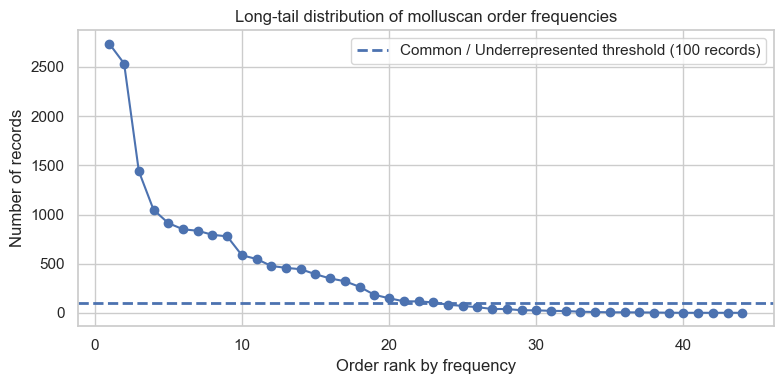

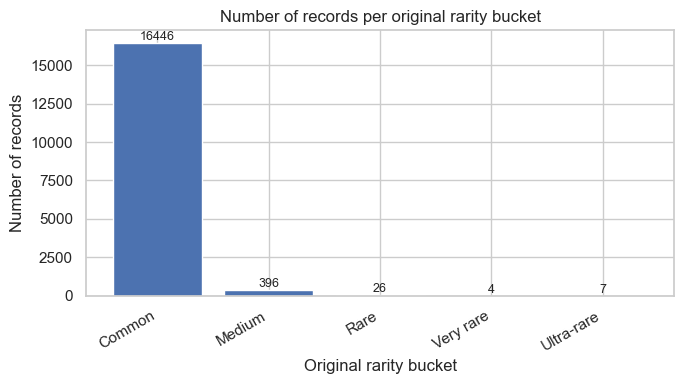

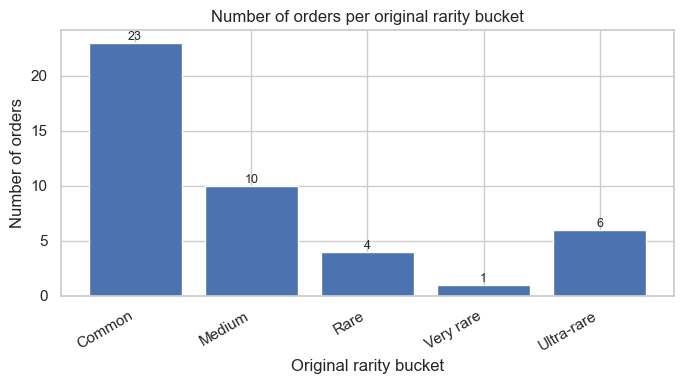


Saved rarity justification outputs to:
outputs_eda/logs/rarity_bucket_justification


In [836]:
#rarity bucket (2-bucket and 4-bucket) justification plots for later rarity bucket analysis
#motivating the selected 100-record common/underrepresented threshold

print_header("RARITY BUCKET JUSTIFICATION")

rarity_out_dir = logs / "rarity_bucket_justification"
rarity_out_dir.mkdir(parents=True, exist_ok=True)

#using full labelled modelling dataframe before splitting
order_counts_df = (
    df_model[["label", "order_count_global", "order_rarity_global"]]
    .drop_duplicates()
    .sort_values("order_count_global", ascending=False)
    .reset_index(drop=True)
)

#4 bucket summary
four_bucket_order = ["common", "medium", "rare", "very_rare", "ultra_rare"] #ultra rare excluded from supervised experiment

four_bucket_summary = (
    order_counts_df
    .groupby("order_rarity_global")
    .agg(
        n_orders=("label", "nunique"),
        n_records=("order_count_global", "sum"),
        min_records_per_order=("order_count_global", "min"),
        median_records_per_order=("order_count_global", "median"),
        max_records_per_order=("order_count_global", "max"),
    )
    .reindex(four_bucket_order)
    .dropna(how="all")
    .reset_index()
)

four_bucket_summary["n_records"] = four_bucket_summary["n_records"].astype(int)
four_bucket_summary["n_orders"] = four_bucket_summary["n_orders"].astype(int)

display(four_bucket_summary)

four_bucket_summary.to_csv(
    rarity_out_dir / "rarity_summary_4bucket.csv",
    index=False,
)

#2 bucket summary 

def assign_two_bucket(rarity):
    if rarity == "common":
        return "Common"
    elif rarity in {"medium", "rare", "very_rare"}:
        return "Underrepresented"
    elif rarity == "ultra_rare":
        return "Ultra-rare tail"
    else:
        return pd.NA

order_counts_df["rarity_2bucket"] = (
    order_counts_df["order_rarity_global"]
    .apply(assign_two_bucket)
)

two_bucket_order = ["Common", "Underrepresented", "Ultra-rare tail"]

two_bucket_summary = (
    order_counts_df
    .groupby("rarity_2bucket")
    .agg(
        n_orders=("label", "nunique"),
        n_records=("order_count_global", "sum"),
        min_records_per_order=("order_count_global", "min"),
        median_records_per_order=("order_count_global", "median"),
        max_records_per_order=("order_count_global", "max"),
    )
    .reindex(two_bucket_order)
    .dropna(how="all")
    .reset_index()
)

two_bucket_summary["n_records"] = two_bucket_summary["n_records"].astype(int)
two_bucket_summary["n_orders"] = two_bucket_summary["n_orders"].astype(int)

display(two_bucket_summary)

two_bucket_summary.to_csv(
    rarity_out_dir / "rarity_summary_2bucket.csv",
    index=False,
)

#long-tail distribution plot
sorted_counts = (
    order_counts_df["order_count_global"]
    .sort_values(ascending=False)
    .values
)

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(sorted_counts) + 1),
    sorted_counts,
    marker="o",
)

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=2,
    label="Common / Underrepresented threshold (100 records)",
)

plt.title("Long-tail distribution of molluscan order frequencies")
plt.xlabel("Order rank by frequency")
plt.ylabel("Number of records")
plt.legend()
plt.tight_layout()

plt.savefig(
    rarity_out_dir / "order_long_tail_distribution_100_threshold.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

#plotting records per rarity bucket

plot_df = four_bucket_summary.copy()
plot_df["label"] = plot_df["order_rarity_global"].replace({
    "common": "Common",
    "medium": "Medium",
    "rare": "Rare",
    "very_rare": "Very rare",
    "ultra_rare": "Ultra-rare",
})

plt.figure(figsize=(7, 4))
plt.bar(plot_df["label"], plot_df["n_records"])

for i, row in plot_df.iterrows():
    plt.text(
        i,
        row["n_records"],
        str(row["n_records"]),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.title("Number of records per original rarity bucket")
plt.xlabel("Original rarity bucket")
plt.ylabel("Number of records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    rarity_out_dir / "records_per_original_rarity_bucket.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#plotting orders per rarity bucket

plt.figure(figsize=(7, 4))
plt.bar(plot_df["label"], plot_df["n_orders"])

for i, row in plot_df.iterrows():
    plt.text(
        i,
        row["n_orders"],
        str(row["n_orders"]),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.title("Number of orders per original rarity bucket")
plt.xlabel("Original rarity bucket")
plt.ylabel("Number of orders")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    rarity_out_dir / "orders_per_original_rarity_bucket.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("\nSaved rarity justification outputs to:")
print(rarity_out_dir)


TEST-SET ORDER FREQUENCY CHECK
Most common test-set order: Neogastropoda (n=410)
Orders with ≥100 test specimens: 9/38


,order,n_test_specimens
0,Neogastropoda,410
1,Littorinimorpha,380
2,Cardiida,216
3,Venerida,157
4,Sphaeriida,137
5,Carditida,128
6,Galeommatida,125
7,Stylommatophora,119
8,Cephalaspidea,117
9,Myida,88


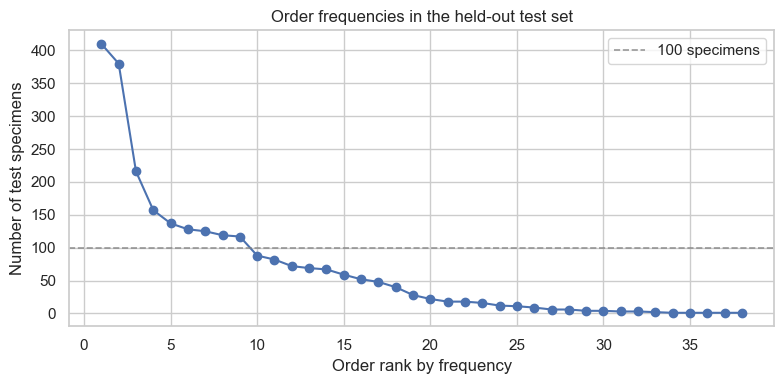


TEST-SET RARITY DISTRIBUTION


,order_rarity_global,n_records,n_orders
0,common,2468.0,23.0
1,medium,60.0,10.0
2,rare,4.0,4.0
3,very_rare,1.0,1.0


In [837]:
#test set order frequency check
#inspecting long-tail distribution of held-out test set

print_header("TEST-SET ORDER FREQUENCY CHECK")

test_order_counts = (
    df_order_model[df_order_model["split"] == "test"]
    .groupby("label")
    .size()
    .sort_values(ascending=False)
)

#most common order
most_common_order = test_order_counts.index[0]
most_common_count = int(test_order_counts.iloc[0])

print(
    f"Most common test-set order: "
    f"{most_common_order} (n={most_common_count})"
)

#orders with at least 100 test specimens
n_orders_ge_100 = (test_order_counts >= 100).sum()

print(
    f"Orders with ≥100 test specimens: "
    f"{n_orders_ge_100}/{len(test_order_counts)}"
)

#top orders table
top_orders = (
    test_order_counts
    .reset_index(name="n_test_specimens")
    .rename(columns={"label": "order"})
)

display(top_orders.head(10))

top_orders.to_csv(
    rarity_out_dir / "test_set_order_frequency_top_orders.csv",
    index=False,
)

#plotting test-set order frequency distribution
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(test_order_counts) + 1),
    test_order_counts.values,
    marker="o",
)

#threshold for well-represented orders
plt.axhline(
    y=100,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="100 specimens",
)

plt.title("Order frequencies in the held-out test set")
plt.xlabel("Order rank by frequency")
plt.ylabel("Number of test specimens")

plt.legend()

plt.tight_layout()

plt.savefig(
    rarity_out_dir / "test_set_order_frequency_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


#test set rarity distribution
#checking how rarity buckets are represented in test set

print_header("TEST-SET RARITY DISTRIBUTION")

test_rarity = (
    df_order_model[df_order_model["split"] == "test"]
    .groupby("order_rarity_global")
    .agg(
        n_records=("gbifID", "count"),
        n_orders=("label", "nunique"),
    )
    .reindex(["common", "medium", "rare", "very_rare", "ultra_rare"])
    .dropna(how="all")
    .reset_index()
)

display(test_rarity)

test_rarity.to_csv(
    rarity_out_dir / "test_set_rarity_distribution.csv",
    index=False,
)

In [838]:
#double checking the test set rarity
print_header("TEST-SET RARITY DISTRIBUTION")

test_rarity = (
    df_order_model[df_order_model["split"] == "test"]
    .groupby("order_rarity_global")
    .agg(
        n_records=("gbifID", "count"),
        n_orders=("label", "nunique"),
    )
    .reindex(["common", "medium", "rare", "very_rare", "ultra_rare"])
    .dropna(how="all")
    .reset_index()
)

display(test_rarity)

test_rarity.to_csv(
    rarity_out_dir / "test_set_rarity_distribution.csv",
    index=False,
)


TEST-SET RARITY DISTRIBUTION


,order_rarity_global,n_records,n_orders
0,common,2468.0,23.0
1,medium,60.0,10.0
2,rare,4.0,4.0
3,very_rare,1.0,1.0


In [839]:
#threshold sensitivity check
#just a sanity check

print_header("THRESHOLD SENSITIVITY CHECK")

threshold_results = []

for threshold in [25, 50, 100, 200, 500]:
    common_mask = order_counts_df["order_count_global"] >= threshold

    threshold_results.append({
        "threshold": threshold,
        "common_orders": int(common_mask.sum()),
        "underrepresented_orders": int((~common_mask).sum()),
        "common_records": int(order_counts_df.loc[common_mask, "order_count_global"].sum()),
        "underrepresented_records": int(order_counts_df.loc[~common_mask, "order_count_global"].sum()),
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

threshold_df.to_csv(
    rarity_out_dir / "threshold_sensitivity_summary.csv",
    index=False,
)


THRESHOLD SENSITIVITY CHECK


,threshold,common_orders,underrepresented_orders,common_records,underrepresented_records
0,25,30,14,16790,89
1,50,26,18,16658,221
2,100,23,21,16446,433
3,200,18,26,15771,1108
4,500,11,33,13062,3817


In [840]:
#saving final order datasets

print_header("SAVING FINAL ORDER DATASETS")

model_dataset_path.mkdir(parents=True, exist_ok=True)

#full dataset, including train/val/test and ultra-rare tail
df_order_model.to_csv(
    model_dataset_path / "order_model_dataset.csv",
    index=False,
)

#individual split files
for split_name in ["train", "val", "test", "ultra_rare_tail"]:
    split_df = df_order_model[df_order_model["split"] == split_name].copy()

    split_df.to_csv(
        model_dataset_path / f"order_{split_name}.csv",
        index=False,
    )

#split notes
split_notes_df.to_csv(
    model_dataset_path / "order_split_notes.csv",
    index=False,
)

#phi core subset
if "phi_core_eval_df" in globals():
    phi_core_eval_df.to_csv(
        model_dataset_path / "phi_core_eval_subset.csv",
        index=False,
    )

saved_files = [
    "order_model_dataset.csv",
    "order_train.csv",
    "order_val.csv",
    "order_test.csv",
    "order_ultra_rare_tail.csv",
    "order_split_notes.csv",
]

if "phi_core_eval_df" in globals():
    saved_files.append("phi_core_eval_subset.csv")

print("\nSaved files:")
for f in saved_files:
    print("-", f)


SAVING FINAL ORDER DATASETS

Saved files:
- order_model_dataset.csv
- order_train.csv
- order_val.csv
- order_test.csv
- order_ultra_rare_tail.csv
- order_split_notes.csv
- phi_core_eval_subset.csv


In [841]:
#saving final dataset config

print_header("SAVING FINAL DATASET CONFIGURATION")

phi_core_exists = "phi_core_eval_df" in globals()

dataset_config = {
    "target": target_col,
    "random_state": random_state,

    "split_strategy": "rare_aware_closed_set_with_ultra_rare_tail",

    "rarity_thresholds": {
        "ultra_rare_tail": "<3",
        "very_rare": very_rare_threshold,
        "rare": rare_threshold,
        "medium": medium_threshold,
    },

    "files": {
        "full": "order_model_dataset.csv",
        "train": "order_train.csv",
        "val": "order_val.csv",
        "test": "order_test.csv",
        "ultra_rare_tail": "order_ultra_rare_tail.csv",
        "split_notes": "order_split_notes.csv",
        "phi_core_eval_subset": (
            "phi_core_eval_subset.csv" if phi_core_exists else None
        ),
    },

    "columns": {
        "id": "gbifID",
        "split": "split",
        "label": "label",
        "label_id": "label_id",
        "test_label_id": "test_label_id",
        "image": "image",
        "order_count": "order_count_global",
        "order_rarity": "order_rarity_global",
    },

    "metadata_conditions": {
        "full_record_realistic": "target removed; lower taxonomy retained",
        "lower_taxonomy_realistic": "target/direct identifiers removed; lower taxonomy retained",
        "strict_conservative": "target + lower taxonomy + identifiers removed",
    },

    "metadata_columns": {
        "full_record_realistic": final_metadata_sets["full_record_realistic"],
        "lower_taxonomy_realistic": final_metadata_sets["lower_taxonomy_realistic"],
        "strict_conservative": final_metadata_sets["strict_conservative"],
    },

    "direct_target_columns_removed": [
        target_col,
        "orderKey",
    ],

    "label_string_checks": {
        "full_record_realistic": int(len(full_record_label_mentions)),
        "lower_taxonomy_realistic": int(len(lower_taxonomy_label_mentions)),
        "strict_conservative": int(len(strict_label_mentions)),
    },

    "experiments": {
        "supervised": [
            "majority_baseline",
            "bioclip2_image_only",
            "modernbert_metadata_only",
            "bioclip2_modernbert_fusion",
        ],
        "phi_exploratory": phi_core_exists,
    },

    "counts": {
        "rows_total": int(len(df_order_model)),
        "rows_train": int((df_order_model["split"] == "train").sum()),
        "rows_val": int((df_order_model["split"] == "val").sum()),
        "rows_test": int((df_order_model["split"] == "test").sum()),
        "rows_ultra_rare_tail": int(
            (df_order_model["split"] == "ultra_rare_tail").sum()
        ),
        "rows_phi_core": (
            int(len(phi_core_eval_df)) if phi_core_exists else None
        ),

        "orders_total": int(df_order_model["label"].nunique()),
        "orders_supervised": int(
            df_order_model[df_order_model["is_supervised_order"]]["label"].nunique()
        ),
        "orders_ultra_rare_tail": int(
            df_order_model[df_order_model["is_ultra_rare_tail_order"]]["label"].nunique()
        ),
    },
}

with open(model_dataset_path / "dataset_config.json", "w") as f:
    json.dump(dataset_config, f, indent=2)

print("Saved dataset_config.json")


SAVING FINAL DATASET CONFIGURATION
Saved dataset_config.json


In [842]:
#sample input preview

print_header("SAMPLE INPUT PREVIEW")

preview_df = df_order_model[
    df_order_model["split"].isin(["train", "val", "test"])
].copy()

sample_row = preview_df.sample(1, random_state=random_state).iloc[0]

print(f"\ngbifID: {sample_row['gbifID']}")
print(f"split: {sample_row['split']}")
print(f"label/order: {sample_row['label']}")
print(f"image: {sample_row['image']}")
print(f"order rarity: {sample_row['order_rarity_global']}")
print(f"order count: {sample_row['order_count_global']}")

print("\nFULL RECORD REALISTIC METADATA:")
print(sample_row["metadata_full_record_realistic"])

print("\nLOWER TAXONOMY REALISTIC METADATA:")
print(sample_row["metadata_lower_taxonomy_realistic"])

print("\nSTRICT CONSERVATIVE METADATA:")
print(sample_row["metadata_strict_conservative"])


SAMPLE INPUT PREVIEW

gbifID: 2442947132
split: val
label/order: Neogastropoda
image: https://medialib.naturalis.nl/file/id/RGM.108045_4%20Gemmula%20antwerpiensis_TOTAAL/format/large
order rarity: common
order count: 2735

FULL RECORD REALISTIC METADATA:
basisOfRecord=FOSSIL_SPECIMEN; occurrenceStatus=PRESENT; preparations=shell; recordedBy=R. Maandag; identifiedBy=H.J. Raad & A.C. Rijken; dateIdentified=2016-01-01T00:00:00; locality=Westerschelde; countryCode=NL; stateProvince=Zeeland; continent=EUROPE; gbifRegion=EUROPE; issue=CONTINENT_DERIVED_FROM_COUNTRY;COLLECTION_MATCH_NONE;TAXON_MATCH_HIGHERRANK; nonTaxonomicIssue=CONTINENT_DERIVED_FROM_COUNTRY;COLLECTION_MATCH_NONE; hasCoordinate=False; hasGeospatialIssues=False; protocol=DWC_ARCHIVE; kingdom=Animalia; phylum=Mollusca; class=Gastropoda; taxonRank=GENUS; nomenclaturalCode=ICZN; taxonomicStatus=ACCEPTED; family=Turridae; genus=Gemmula; scientificName=Gemmula Weinkauff, 1875; acceptedScientificName=Gemmula Weinkauff, 1875; verba

In [843]:
#final dataset summary

print_header("FINAL DATASET SUMMARY")

phi_core_exists = "phi_core_eval_df" in globals()

print(f"\nRows: {len(df_order_model)}")
print(f"Orders total: {df_order_model['label'].nunique()}")
print(
    "Supervised orders:",
    df_order_model.loc[df_order_model["is_supervised_order"], "label"].nunique()
)
print(
    "Ultra-rare tail orders:",
    df_order_model.loc[df_order_model["is_ultra_rare_tail_order"], "label"].nunique()
)

print("\nSplit sizes:")
print(df_order_model["split"].value_counts().sort_index())

print("\nUnique orders per split:")
print(df_order_model.groupby("split")["label"].nunique().sort_index())

print("\nOrders excluded from supervised train/val/test:")
print(
    split_notes_df.loc[
        split_notes_df["is_ultra_rare_tail"],
        ["label", "n_total", "split_rule"]
    ].sort_values(["n_total", "label"])
)

print("\nRarity summary by rows:")
print(df_order_model["order_rarity_global"].value_counts())

print("\nRarity summary by orders:")
print(
    df_order_model[["label", "order_count_global", "order_rarity_global"]]
    .drop_duplicates()
    ["order_rarity_global"]
    .value_counts()
)

print("\nMedian metadata lengths (characters):")
for col in [
    "metadata_full_record_realistic",
    "metadata_lower_taxonomy_realistic",
    "metadata_strict_conservative",
]:
    print(f"{col}: {df_order_model[col].str.len().median()}")

if phi_core_exists:
    print("\nPhi core subset:")
    print(f"Rows: {len(phi_core_eval_df)}")
    print(phi_core_eval_df["phi_subset_type"].value_counts().sort_index())
    print("Orders:", phi_core_eval_df["label"].nunique())

print("\nSaved files:")
for file in sorted(model_dataset_path.glob("*")):
    print(" -", file.name)

print("\nPrimary supervised benchmark files:")
print("- order_train.csv")
print("- order_val.csv")
print("- order_test.csv")

print("\nAdditional analysis files:")
print("- order_ultra_rare_tail.csv")
if phi_core_exists:
    print("- phi_core_eval_subset.csv")

print("\nUse identical train/val/test splits for:")
print("- Majority-class baseline")
print("- BioCLIP2 image-only")
print("- ModernBERT metadata-only under each metadata condition")
print("- BioCLIP2 + ModernBERT fusion")

print("\nMetadata conditions:")
print("- metadata_full_record_realistic")
print("- metadata_lower_taxonomy_realistic")
print("- metadata_strict_conservative")

if phi_core_exists:
    print(
        "\nPhi-4 multimodal analysis uses a fixed order-balanced core subset: "
        "up to 20 held-out test records per supervised order plus all ultra-rare tail records."
    )

print("\nAll final dataset checks passed.")


FINAL DATASET SUMMARY

Rows: 16879
Orders total: 44
Supervised orders: 38
Ultra-rare tail orders: 6

Split sizes:
split
test                2533
train              11806
ultra_rare_tail        7
val                 2533
Name: count, dtype: int64

Unique orders per split:
split
test               38
train              38
ultra_rare_tail     6
val                38
Name: label, dtype: int64

Orders excluded from supervised train/val/test:
           label  n_total                                split_rule
16   Hippuritida        1  ultra_rare_tail_excluded_from_supervised
28  Nudibranchia        1  ultra_rare_tail_excluded_from_supervised
29      Octopoda        1  ultra_rare_tail_excluded_from_supervised
39    Trigoniida        1  ultra_rare_tail_excluded_from_supervised
41   Umbraculida        1  ultra_rare_tail_excluded_from_supervised
37     Spirulida        2  ultra_rare_tail_excluded_from_supervised

Rarity summary by rows:
order_rarity_global
common        16446
medium          3

In [844]:
#final sanity check for saved file

print_header("FINAL SAVED-FILE SANITY CHECK")

path = Path("outputs_eda/datasets/final_model_dataset")

expected_split_files = {
    "train": "order_train.csv",
    "val": "order_val.csv",
    "test": "order_test.csv",
    "ultra_rare_tail": "order_ultra_rare_tail.csv",
}

#individual split files

split_row_total = 0

for split_name, filename in expected_split_files.items():
    df = pd.read_csv(path / filename)

    split_row_total += len(df)

    print(f"\n{split_name}: {df.shape}")
    print(df["split"].value_counts())

    assert (df["split"] == split_name).all(), (
        f"Invalid split labels in {filename}."
    )

    assert df["gbifID"].is_unique, (
        f"Duplicate gbifID values found in {filename}."
    )

    assert df["label"].notna().all(), (
        f"Missing labels found in {filename}."
    )

    assert df["image"].notna().all(), (
        f"Missing image values found in {filename}."
    )

    print("Unique orders:", df["label"].nunique())


#full master dataset

df_full = pd.read_csv(path / "order_model_dataset.csv")

print(f"\nfull model dataset: {df_full.shape}")
print(df_full["split"].value_counts().sort_index())

assert df_full["gbifID"].is_unique, (
    "Duplicate gbifID values found in full model dataset."
)

assert set(df_full["split"]) == {
    "train",
    "val",
    "test",
    "ultra_rare_tail",
}, (
    "Unexpected split labels found in full model dataset."
)

assert split_row_total == len(df_full), (
    "Split file row counts do not sum to the full dataset."
)

print("Unique orders:", df_full["label"].nunique())


#supervised label space check

train_labels = set(df_full.loc[df_full["split"] == "train", "label"])
val_labels = set(df_full.loc[df_full["split"] == "val", "label"])
test_labels = set(df_full.loc[df_full["split"] == "test", "label"])
ultra_rare_labels = set(
    df_full.loc[df_full["split"] == "ultra_rare_tail", "label"]
)

assert train_labels == val_labels == test_labels, (
    "Train/val/test label spaces do not match."
)

assert ultra_rare_labels.isdisjoint(train_labels), (
    "Ultra-rare labels overlap with supervised label space."
)

print("Supervised orders:", len(train_labels))
print("Ultra-rare tail orders:", len(ultra_rare_labels))


#optional phi subset

phi_path = path / "phi_core_eval_subset.csv"

if phi_path.exists():
    phi_df = pd.read_csv(phi_path)

    print(f"\nphi core subset: {phi_df.shape}")
    print(phi_df["phi_subset_type"].value_counts())

    assert phi_df["gbifID"].is_unique, (
        "Duplicate gbifID values found in Phi core subset."
    )

    assert set(phi_df["split"]).issubset({"test", "ultra_rare_tail"}), (
        "Phi core subset should only contain test and ultra_rare_tail records."
    )

    assert set(phi_df["gbifID"]).issubset(set(df_full["gbifID"])), (
        "Phi core subset contains records not found in full model dataset."
    )

    train_ids = set(df_full.loc[df_full["split"] == "train", "gbifID"])
    val_ids = set(df_full.loc[df_full["split"] == "val", "gbifID"])

    assert train_ids.isdisjoint(set(phi_df["gbifID"])), (
        "Training records leaked into Phi core subset."
    )

    assert val_ids.isdisjoint(set(phi_df["gbifID"])), (
        "Validation records leaked into Phi core subset."
    )

    print("Phi core orders:", phi_df["label"].nunique())


print("\nSaved dataset files verified successfully.")


FINAL SAVED-FILE SANITY CHECK

train: (11806, 15)
split
train    11806
Name: count, dtype: int64
Unique orders: 38

val: (2533, 15)
split
val    2533
Name: count, dtype: int64
Unique orders: 38

test: (2533, 15)
split
test    2533
Name: count, dtype: int64
Unique orders: 38

ultra_rare_tail: (7, 15)
split
ultra_rare_tail    7
Name: count, dtype: int64
Unique orders: 6

full model dataset: (16879, 15)
split
test                2533
train              11806
ultra_rare_tail        7
val                 2533
Name: count, dtype: int64
Unique orders: 44
Supervised orders: 38
Ultra-rare tail orders: 6

phi core subset: (524, 18)
phi_subset_type
core_closed_set    517
ultra_rare_tail      7
Name: count, dtype: int64
Phi core orders: 44

Saved dataset files verified successfully.


Note that a stratified splitting cannot place a one-sample class into train/val/test (need min 2). The value error obtained otherwise is "ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2."

This project uses the fully complete, expert-annotated metadata as ground-truth. Testing will be performed on data with the correct metadata removed, however in order to have this ground truth comparison, the correct metadata must still exist (it will simply be deleted in order to correctly conduct the model experiments). For this, further filtering of the data is necessary to ensure the candidate fields are present and will be completed in the next steps and notebook.

In [845]:
from IPython.display import display, HTML, Image
import pandas as pd
import html

def show_specimen(row):
    #showing image
    if pd.notna(row.get("primary_image", pd.NA)):
        display(Image(url=row["primary_image"], width=400))

    #selected fields
    fields = [
        "gbifID", "family", "genus", "scientificName",
        "locality", "countryCode", "stateProvince",
        "eventDate", "year", "month",
        "formation", "member", "bed",
        "occurrenceRemarks", "fieldNotes"
    ]

    rows_html = ""
    for f in fields:
        if f in row.index and pd.notna(row[f]):
            rows_html += f"<tr><td><b>{html.escape(f)}</b></td><td>{html.escape(str(row[f]))}</td></tr>"

    display(HTML(f"""
    <h3>Specimen: {row['gbifID']}</h3>
    <table style="border-collapse:collapse;">
        {rows_html}
    </table>
    """))

row = df_mm.sample(1, random_state=42).iloc[0]
show_specimen(row)

gbifID,2443021285
family,Pyramidellidae
genus,Spiralina
scientificName,"Chrysallida spiralis (Montagu, 1803)"
locality,Noordzee


In [846]:
#inspecting 2 random specimens and corresponding images

from IPython.display import display, Image
import pandas as pd

print_header("DETAILED SPECIMEN INSPECTION (2 EXAMPLES)")

samples = df_mm.sample(2, random_state=42)

for i, (_, row) in enumerate(samples.iterrows(), 1):
    print(f"\n{'='*60}")
    print(f"SPECIMEN {i}")
    print(f"{'='*60}")
    
    print("gbifID:", row["gbifID"])
    print("Family:", row.get("family", "N/A"))
    
    #showing image
    if pd.notna(row.get("primary_image", pd.NA)):
        display(Image(url=row["primary_image"], width=350))
    else:
        print("No image available")
    
    #showing all metadata (non-missing only)
    metadata_df = pd.DataFrame({
        "Field": row.index,
        "Value": row.values
    })
    
    metadata_df = metadata_df[metadata_df["Value"].notna()].reset_index(drop=True)
    
    display(metadata_df)


DETAILED SPECIMEN INSPECTION (2 EXAMPLES)

SPECIMEN 1
gbifID: 2443021285
Family: Pyramidellidae


,Field,Value
0,gbifID,2443021285
1,license,CC0_1_0
2,modified,2017-06-29T00:00:00Z
3,publisher,Naturalis Biodiversity Center
4,rightsHolder,Naturalis Biodiversity Center
5,institutionID,https://ror.org/0566bfb96
6,collectionCode,Cainozoic Mollusca
7,basisOfRecord,FOSSIL_SPECIMEN
8,occurrenceID,https://data.biodiversitydata.nl/naturalis/spe...
9,catalogNumber,RGM.928692



SPECIMEN 2
gbifID: 2443024609
Family: Thyasiridae


,Field,Value
0,gbifID,2443024609
1,license,CC0_1_0
2,modified,2017-06-29T00:00:00Z
3,publisher,Naturalis Biodiversity Center
4,rightsHolder,Naturalis Biodiversity Center
5,institutionID,https://ror.org/0566bfb96
6,collectionCode,Cainozoic Mollusca
7,basisOfRecord,FOSSIL_SPECIMEN
8,occurrenceID,https://data.biodiversitydata.nl/naturalis/spe...
9,catalogNumber,RGM.930384


In [847]:
#inspecting top 3 most complete specimens
print_header("TOP 3 MOST COMPLETE SPECIMENS")

top_samples = df_mm.sort_values("row_completeness_pct", ascending=False).head(3)

for i, (_, row) in enumerate(top_samples.iterrows(), 1):
    print(f"\n--- Specimen {i} ---")
    print("gbifID:", row["gbifID"])
    print("Completeness:", row["row_completeness_pct"])
    
    if pd.notna(row.get("primary_image", pd.NA)):
        display(Image(url=row["primary_image"], width=300))


TOP 3 MOST COMPLETE SPECIMENS

--- Specimen 1 ---
gbifID: 5291594336
Completeness: 91.56626506024097



--- Specimen 2 ---
gbifID: 2442959758
Completeness: 91.56626506024097



--- Specimen 3 ---
gbifID: 2442988437
Completeness: 91.56626506024097


In [848]:
print_header("MOST COMPLETE SPECIMEN")

#sorting by completeness
best_row = df_mm.sort_values("row_completeness_pct", ascending=False).iloc[0]

print("gbifID:", best_row["gbifID"])
print("Completeness (%):", best_row["row_completeness_pct"])

#showing image
from IPython.display import Image, display
import pandas as pd

if pd.notna(best_row.get("primary_image", pd.NA)):
    display(Image(url=best_row["primary_image"], width=400))
else:
    print("No image available")

#showing all non-missing metadata
metadata_df = pd.DataFrame({
    "Field": best_row.index,
    "Value": best_row.values
})

metadata_df = metadata_df[metadata_df["Value"].notna()].reset_index(drop=True)

display(metadata_df)


MOST COMPLETE SPECIMEN
gbifID: 5291594336
Completeness (%): 91.56626506024097


,Field,Value
0,gbifID,5291594336
1,license,CC0_1_0
2,modified,2025-11-07T00:00:00Z
3,publisher,Naturalis Biodiversity Center
4,rightsHolder,Naturalis Biodiversity Center
5,institutionID,https://ror.org/0566bfb96
6,collectionCode,Cainozoic Mollusca
7,basisOfRecord,PRESERVED_SPECIMEN
8,occurrenceID,https://data.biodiversitydata.nl/naturalis/spe...
9,catalogNumber,RGM.1383611


In [849]:
from IPython.display import Image, display
import pandas as pd

print_header("LEAST COMPLETE SPECIMEN")

#sorting ascending → least complete first
worst_row = df_mm.sort_values("row_completeness_pct", ascending=True).iloc[0]

print("gbifID:", worst_row["gbifID"])
print("Completeness (%):", worst_row["row_completeness_pct"])

#showing image
if pd.notna(worst_row.get("primary_image", pd.NA)):
    display(Image(url=worst_row["primary_image"], width=400))
else:
    print("No image available")

#showing all non-missing metadata
metadata_df = pd.DataFrame({
    "Field": worst_row.index,
    "Value": worst_row.values
})

metadata_df = metadata_df[metadata_df["Value"].notna()].reset_index(drop=True)

display(metadata_df)


LEAST COMPLETE SPECIMEN
gbifID: 5201096337
Completeness (%): 55.42168674698795


,Field,Value
0,gbifID,5201096337
1,license,CC0_1_0
2,modified,2017-06-29T00:00:00Z
3,publisher,Naturalis Biodiversity Center
4,rightsHolder,Naturalis Biodiversity Center
5,institutionID,https://ror.org/0566bfb96
6,collectionCode,Cainozoic Mollusca
7,basisOfRecord,FOSSIL_SPECIMEN
8,occurrenceID,https://data.biodiversitydata.nl/naturalis/spe...
9,catalogNumber,RGM.933827


In [850]:
print_header("LEAST COMPLETE SPECIMENS")

worst_samples = df_mm.sort_values("row_completeness_pct", ascending=True).head(3)

for i, (_, row) in enumerate(worst_samples.iterrows(), 1):
    print(f"\n--- Specimen {i} ---")
    print("gbifID:", row["gbifID"])
    print("Completeness:", row["row_completeness_pct"])
    
    if pd.notna(row.get("primary_image", pd.NA)):
        display(Image(url=row["primary_image"], width=300))
    
    #showing only a few key fields to keep output readable
    print("Locality:", row.get("locality", "N/A"))
    print("EventDate:", row.get("eventDate", "N/A"))
    print("Family:", row.get("family", "N/A"))


LEAST COMPLETE SPECIMENS

--- Specimen 1 ---
gbifID: 5201096337
Completeness: 55.42168674698795


Locality: <NA>
EventDate: <NA>
Family: <NA>

--- Specimen 2 ---
gbifID: 5201096570
Completeness: 55.42168674698795


Locality: <NA>
EventDate: <NA>
Family: <NA>

--- Specimen 3 ---
gbifID: 5201096923
Completeness: 55.42168674698795


Locality: <NA>
EventDate: <NA>
Family: <NA>
